# Molecular Dynamics Analysis of ROS1 Mutations

This notebook presents a structural analysis of ROS1 kinase mutations using molecular dynamics simulations.  
The goal is to characterize conformational differences between mutants by combining structural alignment, principal component analysis (PCA), and clustering techniques.

Key analyses include:

- Global kinase PCA
- Orientation PCA of kinase lobes
- Loop-specific PCA (A-loop and Tyr-loop)
- Density-based clustering of conformational states
- Occupancy analysis across mutants

In [1]:

# importing necessary libraries
import os
import pandas as pd
import numpy as np
import MDAnalysis as mda
import molly
from MDAnalysis.analysis.dssp import DSSP
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from MDAnalysis.lib.distances import calc_dihedrals

from scripts.clustering import run_hdbscan, run_dbscan
from scripts.occupancy import occupancy_from_traj_labels
from scripts.plotting import (
    plot_occupancy_heatmap,
    plot_cluster_population,
    plot_pca_clusters
)

import timer
tim = timer.Timer()

eps = 1e-6
os.makedirs("figures", exist_ok=True)



/homes/lkgyammerah/.venvs/ros1_analysis_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# HELPER FUNCTIONS FOR CLUSTERING + OCCUPANCY + HEATMAPS
# ============================================================

def mutant_names_from_F(F):
    return np.array([p.split("/")[0] for p in F], dtype=object)

def occ_table_from_owner(F, x_owner, labels):
    """
    For variable-length PCA sections where x_owner maps each frame to trajectory index.
    """
    traj_mutant = mutant_names_from_F(F)
    frame_mutant = traj_mutant[np.asarray(x_owner).astype(int)]

    df = pd.DataFrame({
        "mutant": frame_mutant,
        "state": np.asarray(labels).astype(int)
    })

    counts = df.groupby(["mutant", "state"]).size().unstack(fill_value=0).sort_index()
    fracs = counts.div(counts.sum(axis=1), axis=0)
    return counts, fracs

def run_cluster_panel_varlen(scores_flat, x_owner, F, prefix, title_prefix,
                             n_pcs=5, min_cluster_size=150, eps=0.8, min_samples=60):
    """
    For variable-length PCA sections:
    - scores_flat shape: (n_frames_total, n_components)
    - x_owner shape: (n_frames_total,) trajectory index per frame
    """
    Z = np.asarray(scores_flat)[:, :n_pcs]

    labels_hdb = run_hdbscan(Z, n_pcs=n_pcs, min_cluster_size=min_cluster_size)
    labels_db  = run_dbscan(Z, n_pcs=n_pcs, eps=eps, min_samples=min_samples)

    counts_hdb, frac_hdb = occ_table_from_owner(F, x_owner, labels_hdb)
    counts_db,  frac_db  = occ_table_from_owner(F, x_owner, labels_db)

    print(f"{title_prefix} HDBSCAN clusters:", len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0))
    print(f"{title_prefix} HDBSCAN noise fraction:", float(np.mean(labels_hdb == -1)))
    print(f"{title_prefix} DBSCAN clusters:", len(set(labels_db)) - (1 if -1 in labels_db else 0))
    print(f"{title_prefix} DBSCAN noise fraction:", float(np.mean(labels_db == -1)))

    print(f"{title_prefix} occupancy (HDBSCAN primary):")
    display(frac_hdb)

    print(f"{title_prefix} occupancy (DBSCAN baseline):")
    display(frac_db)

    plot_occupancy_heatmap(
        frac_hdb,
        title=f"State Occupancy per Mutant ({title_prefix} Clusters)",
        outpath=f"figures/{prefix}_occupancy_heatmap.png"
    )

    plot_cluster_population(
        labels_hdb,
        title=f"Cluster Population ({title_prefix} Representation)",
        outpath=f"figures/{prefix}_cluster_population.png"
    )

    plot_pca_clusters(
        np.asarray(scores_flat)[:, 0],
        np.asarray(scores_flat)[:, 1],
        labels_hdb,
        title=f"{title_prefix} PCA — HDBSCAN Clusters",
        outpath=f"figures/{prefix}_pca_clusters.png"
    )

    return {
        "labels_hdb": labels_hdb,
        "labels_db": labels_db,
        "counts_hdb": counts_hdb,
        "frac_hdb": frac_hdb,
        "counts_db": counts_db,
        "frac_db": frac_db,
    }

def run_cluster_panel_equal(scores_3d, F, prefix, title_prefix,
                            n_pcs=5, min_cluster_size=150, eps=0.8, min_samples=60):
    """
    For equal-length PCA sections:
    - scores_3d shape: (nmut, nframes_each, n_components)
    """
    scores_3d = np.asarray(scores_3d)
    nmut, nframes_each, ncomp = scores_3d.shape

    Z = scores_3d[:, :, :n_pcs].reshape(-1, n_pcs)

    labels_hdb = run_hdbscan(Z, n_pcs=n_pcs, min_cluster_size=min_cluster_size)
    labels_db  = run_dbscan(Z, n_pcs=n_pcs, eps=eps, min_samples=min_samples)

    counts_hdb, frac_hdb = occupancy_from_traj_labels(F, nframes_each, labels_hdb)
    counts_db,  frac_db  = occupancy_from_traj_labels(F, nframes_each, labels_db)

    print(f"{title_prefix} HDBSCAN clusters:", len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0))
    print(f"{title_prefix} HDBSCAN noise fraction:", float(np.mean(labels_hdb == -1)))
    print(f"{title_prefix} DBSCAN clusters:", len(set(labels_db)) - (1 if -1 in labels_db else 0))
    print(f"{title_prefix} DBSCAN noise fraction:", float(np.mean(labels_db == -1)))

    print(f"{title_prefix} occupancy (HDBSCAN primary):")
    display(frac_hdb)

    print(f"{title_prefix} occupancy (DBSCAN baseline):")
    display(frac_db)

    plot_occupancy_heatmap(
        frac_hdb,
        title=f"State Occupancy per Mutant ({title_prefix} Clusters)",
        outpath=f"figures/{prefix}_occupancy_heatmap.png"
    )

    plot_cluster_population(
        labels_hdb,
        title=f"Cluster Population ({title_prefix} Representation)",
        outpath=f"figures/{prefix}_cluster_population.png"
    )

    flat = scores_3d.reshape(-1, ncomp)
    plot_pca_clusters(
        flat[:, 0],
        flat[:, 1],
        labels_hdb,
        title=f"{title_prefix} PCA — HDBSCAN Clusters",
        outpath=f"figures/{prefix}_pca_clusters.png"
    )

    return {
        "labels_hdb": labels_hdb,
        "labels_db": labels_db,
        "counts_hdb": counts_hdb,
        "frac_hdb": frac_hdb,
        "counts_db": counts_db,
        "frac_db": frac_db,
    }


In [3]:
# ============================================
# 1) ONE authoritative selection 
# ============================================
selection = "protein and name N CA C O CB CG and not element H"

## Trajectory Preparation

All trajectories are loaded and organized into a unified data structure (`Multiverse`).  
Coordinates are aligned to reference structural regions to remove global translation and rotation effects before performing PCA analyses.

In [4]:
# ============================================
# 2) Auto-detect mutants + build simulation list F 
# ============================================

IGNORE = {
    "__pycache__",
    "orientation_cluster_reps",   
    "figures",
    "plots",
    "tmp",
}

mutants = []
for d in sorted(os.listdir(".")):
    if not os.path.isdir(d): 
        continue
    if d in IGNORE:
        continue
    if os.path.exists(f"{d}/Simulation_1/md-prot.pdb"):
        mutants.append(d)

print("Detected mutants:", mutants)
nrep = 3
F = [f"{mut}/Simulation_{run}" for mut in mutants for run in (1, 2, 3)]
print("Total simulations:", len(F))

Detected mutants: ['C2060G', 'D1988N', 'D2033N', 'D2113G', 'D2113N', 'E1935G', 'E1990G', 'E2020K', 'E2131Q', 'F1994L', 'F2004C', 'F2004L', 'F2004V', 'F2075V', 'G1957A', 'G1971E', 'G2032K', 'G2032R', 'G2048A_NC', 'G2101A', 'H1999Q_NC', 'L1947R', 'L1951R', 'L1982F', 'L1982V', 'L2010M', 'L2026M', 'L2053V_NC', 'L2086F', 'L2155S', 'Q2022P', 'Q2022P_S1986F', 'Q2022P_S1986Y', 'R2078K', 'S1986F', 'S1986Y', 'V2089M', 'V2098I', 'WT']
Total simulations: 117


In [5]:
# =========================
# locking trajectory paths so F never gets overwritten
# =========================

# Save the real paths exactly once
if "F_paths" not in globals():
    assert "F" in globals(), "Define F (list of traj folder strings) first."
    assert isinstance(F, list) and isinstance(F[0], str), "F must be list[str] when you save it."
    F_paths = F.copy()

# Always use F_paths as truth
F = F_paths.copy()

print("[OK] F restored:", type(F), "len(F)=", len(F), "example:", F[0])

[OK] F restored: <class 'list'> len(F)= 117 example: C2060G/Simulation_1


In [6]:
# selecting the number of frames based on the minimum across trajectories
stride = 1  

def subsampled_len(d, stride=stride):
    u = mda.Universe(f"{d}/md-prot.pdb", f"{d}/md-prot.xtc")
    return len(np.arange(len(u.trajectory))[::stride])

nframes_sub = min(subsampled_len(d) for d in F)
print("[frame_idx_list] Using nframes_sub =", nframes_sub)

def get_frame_idx(d, stride=stride, nsub=nframes_sub):
    u = mda.Universe(f"{d}/md-prot.pdb", f"{d}/md-prot.xtc")
    idx = np.arange(len(u.trajectory))[::stride]
    return idx[:nsub]

frame_idx_list = [get_frame_idx(d) for d in F]

print("[frame_idx_list] built for", len(frame_idx_list), "trajectories.")
print("[frame_idx_list] example first/last:", frame_idx_list[0][0], frame_idx_list[0][-1])

[frame_idx_list] Using nframes_sub = 696
[frame_idx_list] built for 117 trajectories.
[frame_idx_list] example first/last: 0 695


In [7]:
# ============================================
# 3) Helper: reading XTC for a GIVEN atom index list (per sim)
# ============================================
def xtc2array_varlen_by_indices(d, atom_indices, frame_selection=None):
    """
    Reads ONLY atom_indices (0-based indices into Universe atoms)
    Returns xyz: (T, nsel, 3), pbc: (T, 3, 3)
    """
    m = molly.XTCReader(f"{d}/md-prot.xtc")
    nframes = len(m.read_frames(atom_selection=[], frame_selection=frame_selection))
    m.home()

    out = np.zeros((nframes, len(atom_indices), 3), dtype=np.float32)
    pbc = np.empty((nframes, 3, 3), dtype=np.float32)

    m.read_into_array(out, pbc, atom_selection=[int(i) for i in atom_indices], frame_selection=frame_selection)

    # keep your pbc convention
    pbc = np.array(pbc).transpose((0, 2, 1))  # (T,3,3)
    return out, pbc

In [8]:
# ============================================
# 3b) COMMON ATOMS intersection 
#     Building keys by (resid, atomname) within the selection
# ============================================
def selection_keys_and_indices(d, selection):
    """
    Returns:
      keys: set of (resid, name) for atoms in selection
      key_to_index: dict mapping key -> atom_index (0-based)
    """
    u = mda.Universe(f"{d}/md-prot.pdb")
    ag = u.select_atoms(selection)

    # key: (resid, atomname)
    # Use resid from the topology (1..291). Later we apply +1933 only for plotting.
    keys = []
    key_to_index = {}
    for a in ag:
        k = (int(a.resid), str(a.name))
        keys.append(k)
        key_to_index[k] = int(a.ix)  # 0-based atom index in Universe
    return set(keys), key_to_index

with tim("Computing COMMON selection atoms across all simulations"):
    all_keysets = []
    all_maps = []

    for d in F:
        keys, k2i = selection_keys_and_indices(d, selection)
        all_keysets.append(keys)
        all_maps.append(k2i)

    common_keys = set.intersection(*all_keysets)
    print("Selection sizes (min/max):", min(len(s) for s in all_keysets), max(len(s) for s in all_keysets))
    print("COMMON atoms kept:", len(common_keys))

    if len(common_keys) == 0:
        raise ValueError("COMMON atom set is empty — selection too strict or inconsistent topologies.")

    # keep a stable order: by resid then atomname
    common_keys_sorted = sorted(list(common_keys), key=lambda x: (x[0], x[1]))

    # per sim: the atom indices to read from xtc (same order for all sims)
    per_sim_indices = []
    for k2i in all_maps:
        idx = [k2i[k] for k in common_keys_sorted]
        per_sim_indices.append(idx)

# Building authoritative meta from the FIRST sim, using the COMMON indices in the SAME order
u0 = mda.Universe(f"{F[0]}/md-prot.pdb")
meta = u0.atoms[per_sim_indices[0]]
natoms = len(meta)
print("Authoritative natoms (common):", natoms)

Selection sizes (min/max): 1627 1630
COMMON atoms kept: 1626
[TIMER] Computing COMMON selection atoms across all simulations: 5.147 s
Authoritative natoms (common): 1626


In [9]:
# ============================================
# 3c) Read all trajectories (variable length, COMMON atoms only)
# ============================================
with tim("Reading all trajectories (true variable length, common atoms only)"):
    traj_xyz = []
    traj_pbc = []
    for d, idx in zip(F, per_sim_indices):
        fi = frame_idx_list[F.index(d)].tolist() 
        xyz, pbc = xtc2array_varlen_by_indices(d, idx, frame_selection=fi)
        traj_xyz.append(xyz)
        traj_pbc.append(pbc)

traj_len = [x.shape[0] for x in traj_xyz]
print("Frames min/max:", min(traj_len), max(traj_len))


[TIMER] Reading all trajectories (true variable length, common atoms only): 18.518 s
Frames min/max: 696 696


In [10]:
# ============================================
# 4) Masks (computed on COMMON meta)
# ============================================
CA  = (meta.names == "CA")
BB  = np.isin(meta.names, ["N", "CA", "C", "O"])
resids_atom = meta.resids + 1933

# BODY: same as your style (but now based on meta.resids)
BODY = np.isin(meta.resids, np.arange(6, 278))

mode = "BB"
if mode == "CA":
    sele = CA
    fit  = CA & BODY
elif mode == "BB":
    sele = BB
    fit  = BB & BODY
else:
    raise ValueError("mode must be 'CA' or 'BB'")

print("mode:", mode, "sele atoms:", int(sele.sum()), "fit atoms:", int(fit.sum()))


mode: BB sele atoms: 1167 fit atoms: 1088


In [11]:
# ============================================
# 5) DSSP background (WT reference)
# ============================================
r = mda.Universe('WT/Simulation_1/md-prot.pdb', 'WT/Simulation_1/md-prot.pdb').select_atoms('resid 1-291')
with tim("Secondary structure (DSSP)"):
    secondary_structure = ''.join(DSSP(r).run().results.dssp[0]) + '-'
print(secondary_structure)

resids_ca = resids_atom[CA]


[TIMER] Secondary structure (DSSP): 0.114 s
--------HHHEEE-EE-E----EEEEEEEEE--------EEEEEEEEE-----HHHHHHHHHHHHHHH------E--E-EEE------EEEEE-----EHHHHHH----EE--EE---HHHH-HHHHHHHHHHHHHH---EE---------EE----------EEE------EE------EE-------------HHHHH--EE-HHHHHHHHHHHHHHHH-----------HHHHHHH--------------HHHHHHHHHH----------HHHHHHHHHHHH------


/homes/lkgyammerah/.venvs/ros1_analysis_env/lib/python3.13/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


In [12]:
# ============================================
# 6) Plot reference axes cube (E) 
# ============================================
E = np.array((
    0,0,0, 1,0,0,
    0,0,0, 0,1,0,
    0,0,0, 0,0,1,
    1,0,0, 1,1,0,
    1,0,0, 1,0,1,
    0,1,0, 1,1,0,
    0,1,0, 0,1,1,
    0,0,1, 1,0,1,
    0,0,1, 0,1,1,
    1,1,0, 1,1,1,
    1,0,1, 1,1,1,
    0,1,1, 1,1,1,
)).reshape((12, 2, 3)) @ traj_pbc[0][0]
print("E shape:", E.shape)

E shape: (12, 2, 3)


Reference simulation: WT/Simulation_1


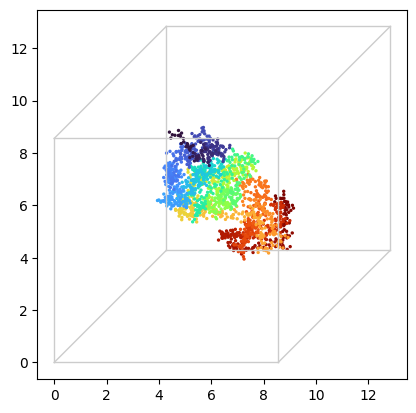

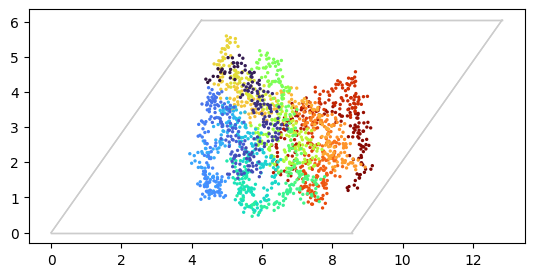

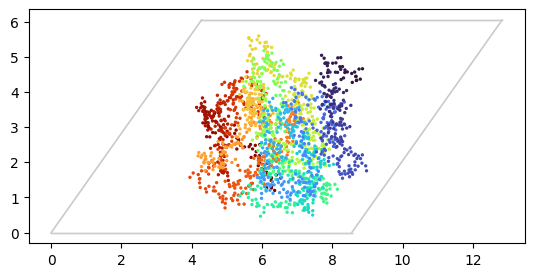

In [13]:
# ============================================
# 7) Reference choice 
# ============================================
ref_sim_index = -3
print("Reference simulation:", F[ref_sim_index])

ref = traj_xyz[ref_sim_index][0].copy()  # (natoms,3) on COMMON atoms

for k in ([0,1], [0,2], [1,2]):
    plt.scatter(*ref[:, k].T, c=-np.arange(len(ref)), cmap='turbo', s=2)
    for e in E:
        plt.plot(*e[:, k].T, c='#ccc', linewidth=1)
    plt.gca().set_aspect('equal')
    plt.show()

In [14]:
# ============================================
# 8) Reference views + alignment (FIXED)
# ============================================

ref_centered = ref - ref[fit].mean(axis=0, keepdims=True)
ref_fit = ref_centered[fit]
ref_fit = ref_fit - ref_fit.mean(axis=0, keepdims=True)  # (nfit,3)

def align_traj_to_ref(xyz, fit_mask, ref_fit_centered):
    """
    xyz: (T, natoms, 3) on COMMON atoms
    """
    xyz = xyz.copy().astype(np.float64)

    xyz -= xyz[:, fit_mask].mean(axis=1, keepdims=True)
    Xfit = xyz[:, fit_mask]  # (T, nfit, 3)

    M = np.einsum('ij,tjk->tik', (ref_fit_centered.T / (3 * ref_fit_centered.shape[0])), Xfit)  # (T,3,3)
    U, S, Vt = np.linalg.svd(M)
    R = U @ Vt  # (T,3,3)

    xyz = xyz @ np.transpose(R, (0, 2, 1))
    return xyz.astype(np.float32)

with tim("Aligning ALL trajectories to ONE reference (variable length)"):
    traj_aligned = []
    for xyz in traj_xyz:
        traj_aligned.append(align_traj_to_ref(xyz, fit, ref_fit))


[TIMER] Aligning ALL trajectories to ONE reference (variable length): 12.625 s


[TIMER] RMSD per trajectory (vs own first frame): 4.280 s


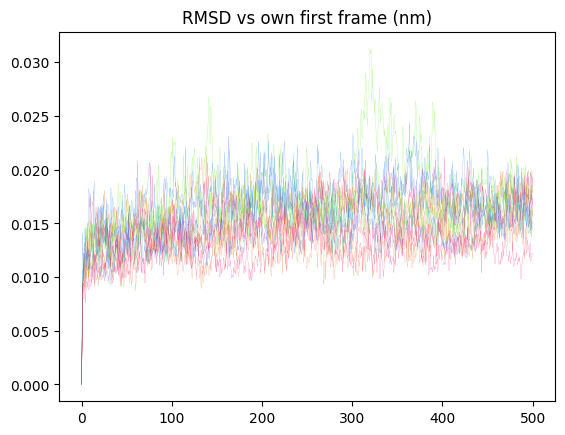

In [15]:
# ============================================
# 9) RMSD vs own first frame (per trajectory)
# ============================================
colors = ('#ee5500', '#55ee00', '#0066ff', '#ff0066')

with tim("RMSD per trajectory (vs own first frame)"):
    rmsd_list = []
    for xyz in traj_aligned:
        x0 = xyz[0, sele]
        dif = xyz[:, sele] - x0[None, :, :]
        r = np.sqrt((dif * dif).sum(axis=(1,2)) / sele.sum()) / 10.0
        rmsd_list.append(r)

for r, c in zip(rmsd_list, np.repeat(colors, 3)):
    t = np.linspace(0, 500, num=len(r))
    plt.plot(t, r, c=c, linewidth=0.1)
plt.title("RMSD vs own first frame (nm)")
plt.show()

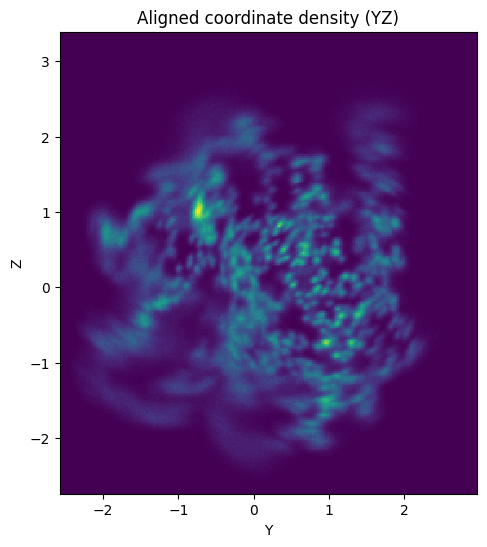

In [16]:
# ============================================
# 10) Plot of all structures aligned (YZ density)
# ============================================
stride_density = 10
YZ_all = []
for xyz in traj_aligned:
    A = xyz[::stride_density, sele, 1:].reshape((-1, 2))
    mask = ~((np.abs(A[:,0]) < 1e-6) & (np.abs(A[:,1]) < 1e-6))
    YZ_all.append(A[mask])
YZ_all = np.vstack(YZ_all)

plt.figure(figsize=(7,6))
plt.hist2d(YZ_all[:,0], YZ_all[:,1], bins=256)
plt.gca().set_aspect('equal')
plt.title("Aligned coordinate density (YZ)")
plt.xlabel("Y")
plt.ylabel("Z")
plt.show()

In [17]:
# ============================================
# 11) RMSF (per traj + overall)
# ============================================
with tim("RMSF per trajectory (variable length)"):
    rmsf_list = []
    for xyz in traj_aligned:
        mean_i = xyz.mean(axis=0, keepdims=True)
        rmsf_i = np.sqrt(((xyz - mean_i)**2).sum(axis=(0,2)) / xyz.shape[0])  # (natoms,)
        rmsf_list.append(rmsf_i)
    rmsf = np.vstack(rmsf_list)
    overall = rmsf.mean(axis=0)

# ============================================
# 11.5) Domain masks
# ============================================
NTL = (resids_atom >= 1934) & (resids_atom <= 2030)
CTL = (resids_atom >= 2031) & (resids_atom <= 2225)
CHX = (resids_atom >= 1960) & (resids_atom <= 1975)
PLP = (resids_atom >= 1980) & (resids_atom <= 1990)

[TIMER] RMSF per trajectory (variable length): 2.762 s


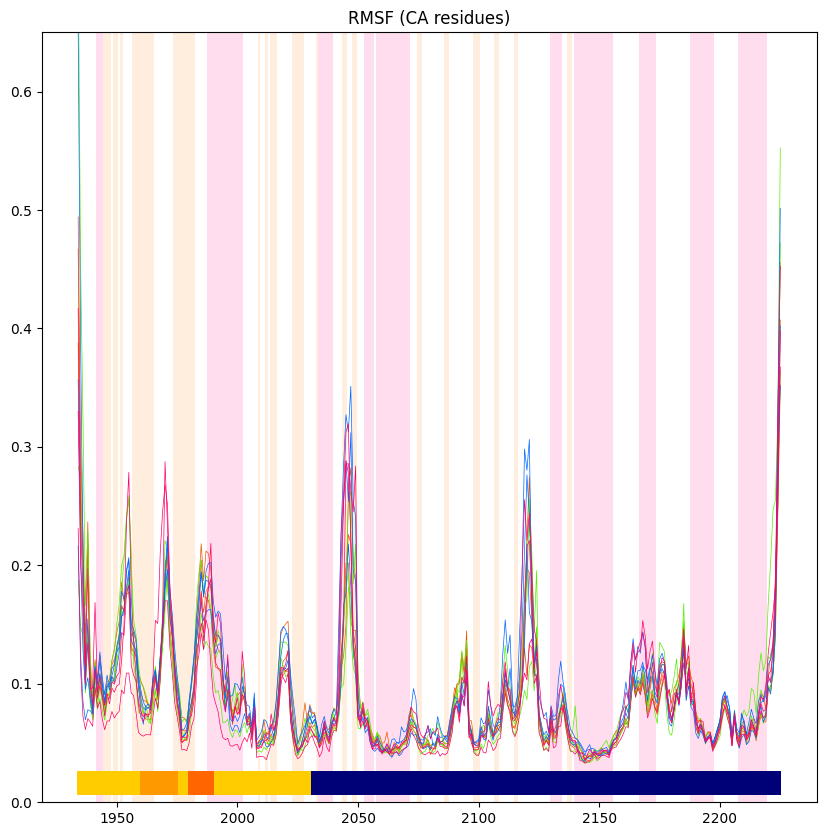

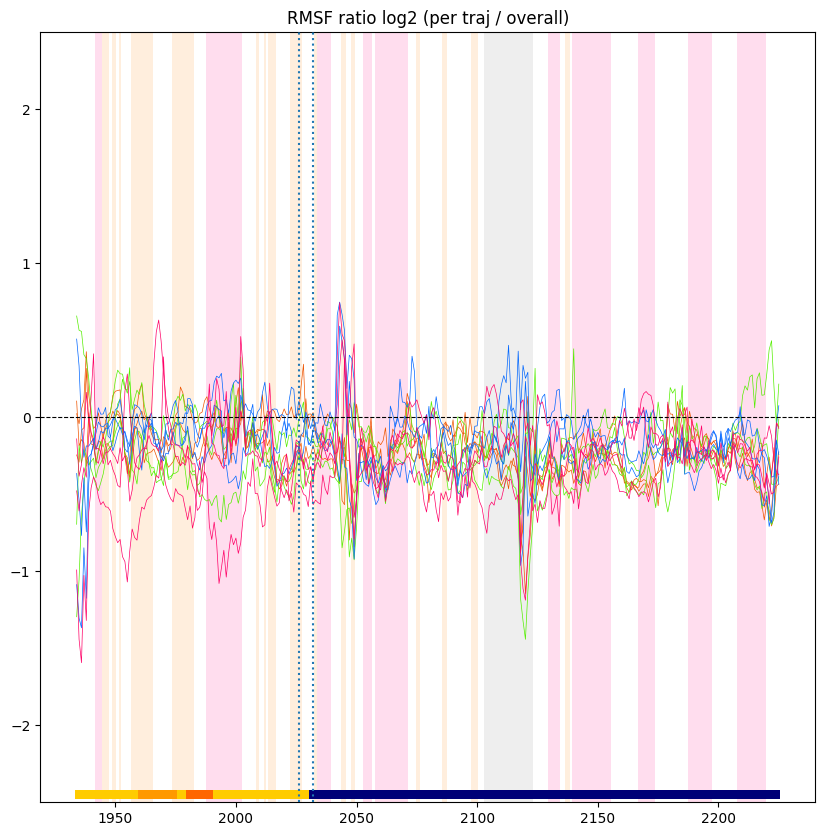

In [18]:
# ============================================
# 12) RMSF plot (CA) + domain band
# ============================================
fig, ax = plt.subplots(figsize=(10, 10))

for s, c in zip(rmsf, np.repeat(colors, 3)):
    ax.plot(resids_atom[CA], s[CA], c=c, linewidth=0.5)

for x, ss in zip(resids_ca, secondary_structure):
    if ss == 'H':
        fc = '#ffddee'
    elif ss == 'E':
        fc = '#ffeedd'
    else:
        fc = 'white'
    ax.add_patch(patches.Rectangle((x - 0.5, 0), 1, 1, facecolor=fc, zorder=0))

ax.set_ylim((0, 0.65))

ymin, ymax = ax.get_ylim()
bar_h = 0.03 * (ymax - ymin)
bar_y = ymin + 0.01 * (ymax - ymin)

for dom_mask, col in ((NTL, '#ffcc00'), (CTL, '#000077'), (CHX, '#ff9900'), (PLP, '#ff6600')):
    dom_ca = np.where(dom_mask & CA)[0]
    if len(dom_ca) == 0:
        continue
    x0 = resids_atom[dom_ca[0]]
    x1 = resids_atom[dom_ca[-1]]
    ax.add_patch(
    patches.Rectangle(
        (x0 - 0.5, bar_y),
        (x1 - x0) + 1,
        bar_h,
        facecolor=col,
        zorder=10
    )
)

plt.title("RMSF (CA residues)")
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))

ratio = rmsf / (overall + 1e-12)   # keep simple broadcasting

ymin, ymax = -2.5, 2.5
ax.set_ylim((ymin, ymax))

for x, ss in zip(resids_ca, secondary_structure):
    fc = '#fde' if ss == 'H' else ('#fed' if ss == 'E' else 'white')
    ax.add_patch(patches.Rectangle((x - 0.5, ymin), 1, ymax - ymin, facecolor=fc, zorder=0))

ax.add_patch(patches.Rectangle((2103, ymin), 20, ymax - ymin, facecolor='#eee', zorder=1))

bar_h = 0.06
bar_y = ymin + 0.02
for dom_mask, col in (NTL, '#ffcc00'), (CTL, '#000077'), (CHX, '#ff9900'), (PLP, '#ff6600'):
    dom_ca = np.where(dom_mask & CA)[0]
    if len(dom_ca) == 0:
        continue
    x0 = resids_atom[dom_ca[0]]
    x1 = resids_atom[dom_ca[-1]]
    ax.add_patch(patches.Rectangle((x0 - 0.5, bar_y), (x1 - x0) + 1, bar_h, facecolor=col, zorder=2))

for s, c in zip(ratio, np.repeat(colors, 3)):
    ax.plot(resids_atom[CA], np.log2(s[CA] + 1e-12), c=c, linewidth=0.5, zorder=5)

ax.axvline(2026, linestyle=':', zorder=6)
ax.axvline(2032, linestyle=':', zorder=6)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=6)

plt.title("RMSF ratio log2 (per traj / overall)")
plt.show()




## Global Kinase PCA (ACT-IN)

Principal component analysis was performed on backbone atoms of the kinase domain including the activation loop.  

This analysis captures global conformational motions of the kinase domain and allows comparison of mutant conformational sampling in a reduced dimensional space.

[TIMER] Vectorizing aligned conformations deviations from mean (PCA, variable length): 7.317 s
X shape: (16380, 3501)
[TIMER] Diagonalization (PCA): 9.198 s


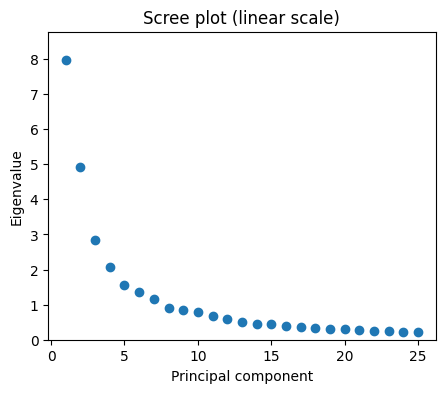

[TIMER] Projections (scores) on first 10 components, scaled to RMSD: 0.263 s


In [19]:
# ============================================
# PCA (Whole kinase incl activation loop) – variable length correct
# ============================================
with tim("Vectorizing aligned conformations deviations from mean (PCA, variable length)"):
    all_frames = []
    for xyz in traj_aligned:
        all_frames.append(xyz[:, sele].reshape(xyz.shape[0], -1))
    all_frames = np.vstack(all_frames)
    mean = all_frames.mean(axis=0)   # (d,)
    d = mean.size

    P_list = []
    X_list = []
    P_owner = []
    X_owner = []

    for ti, xyz in enumerate(traj_aligned):
        dev = xyz[:, sele].reshape(xyz.shape[0], -1) - mean
        split_idx = int(0.8 * dev.shape[0])

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

print("X shape:", X.shape)

with tim("Diagonalization (PCA)"):
    C = X.T @ (X / len(X))
    evals, loadings = np.linalg.eigh(C)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    loadings = loadings[:, idx]

plt.figure(figsize=(5, 4))
plt.scatter(np.arange(1, 26), evals[:25])
plt.ylim((0, 1.1 * evals[:25].max()))
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (linear scale)")
plt.show()

ncomponents = 10
scale = np.sqrt(mean.size)

with tim(f"Projections (scores) on first {ncomponents} components, scaled to RMSD"):
    pscores_flat = (P @ loadings[:, :ncomponents]) / scale
    scores_flat  = (X @ loadings[:, :ncomponents]) / scale


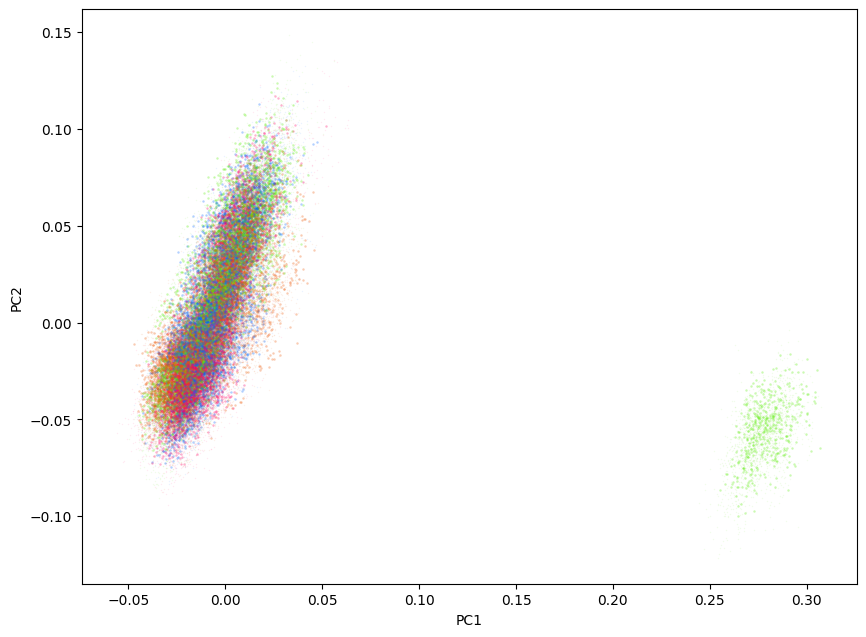

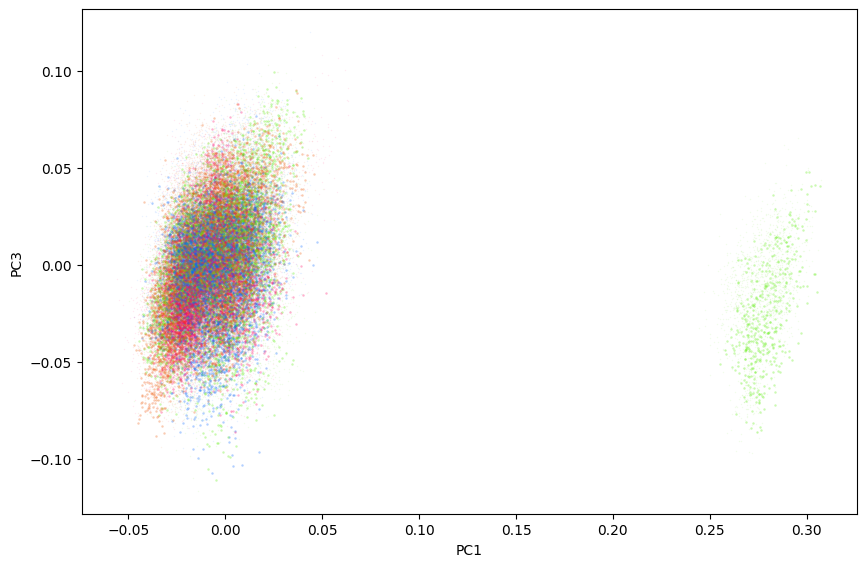

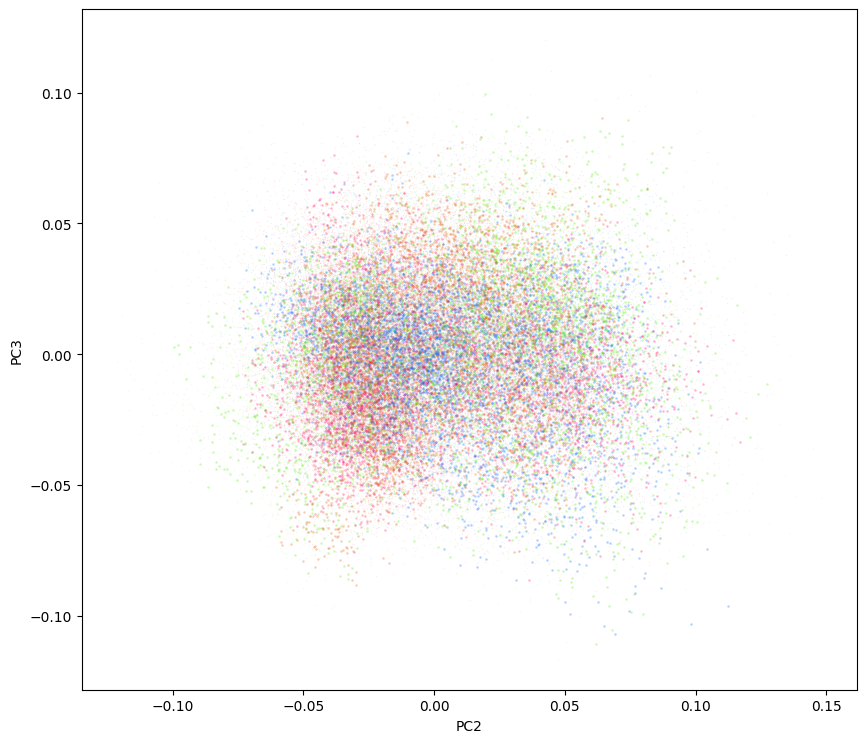

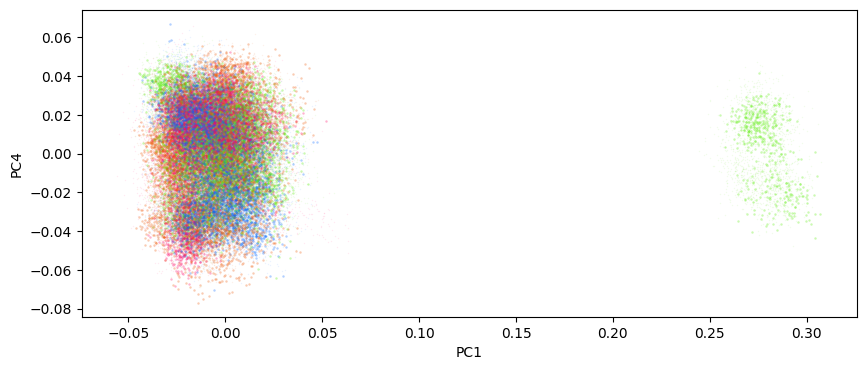

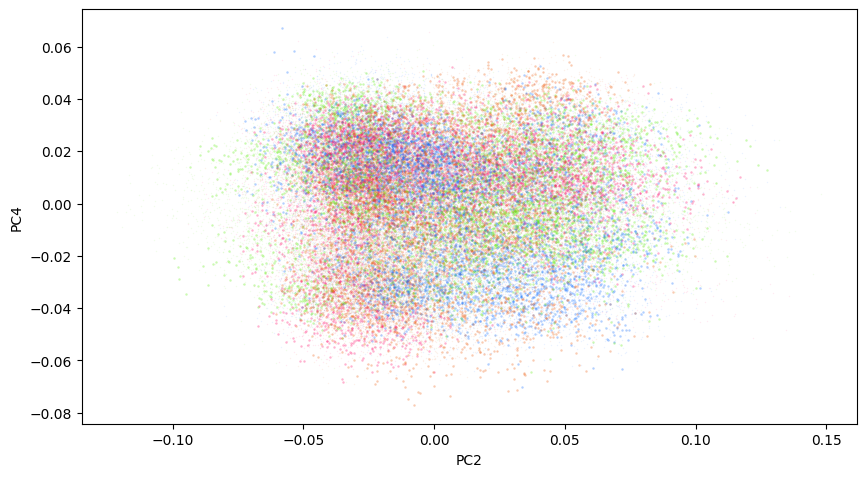

In [20]:
# ============================================
# Colored per mutant scatter (same style)
# ============================================
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(len(F) / len(traj_colors))))[:len(F)]

stride = 1
pairs = [(0,1), (0,2), (1,2), (0,3), (1,3)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # early (P): faint
    for ti in range(len(F)):
        mask = (P_owner == ti)
        Zi = pscores_flat[mask]
        ax.scatter(Zi[::stride, a], Zi[::stride, b],
                   s=1, c=[traj_colors[ti]], alpha=0.08, linewidths=0)

    # production (X): stronger
    for ti in range(len(F)):
        mask = (X_owner == ti)
        Zi = scores_flat[mask]
        ax.scatter(Zi[::stride, a], Zi[::stride, b],
                   s=3, c=[traj_colors[ti]], alpha=0.30, linewidths=0)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.show()

## Conformational State Clustering

Density-based clustering was applied to PCA coordinates to identify recurrent conformational states sampled during simulations.

Cluster occupancy was then computed for each mutant to quantify differences in conformational preferences.

ACT-IN HDBSCAN clusters: 2
ACT-IN HDBSCAN noise fraction: 0.0
ACT-IN DBSCAN clusters: 3
ACT-IN DBSCAN noise fraction: 0.010134310134310135
ACT-IN occupancy (HDBSCAN primary):


state,0,1
mutant,,
C2060G,0.0,1.0
D1988N,0.0,1.0
D2033N,0.0,1.0
D2113G,0.0,1.0
D2113N,0.0,1.0
E1935G,0.0,1.0
E1990G,0.0,1.0
E2020K,0.0,1.0
E2131Q,0.0,1.0


ACT-IN occupancy (DBSCAN baseline):


state,-1,0,1,2
mutant,,,,
C2060G,0.004762,0.995238,0.000000,0.00000
D1988N,0.000000,1.000000,0.000000,0.00000
D2033N,0.014286,0.985714,0.000000,0.00000
D2113G,0.000000,1.000000,0.000000,0.00000
D2113N,0.000000,1.000000,0.000000,0.00000
E1935G,0.000000,1.000000,0.000000,0.00000
E1990G,0.004762,0.995238,0.000000,0.00000
E2020K,0.000000,1.000000,0.000000,0.00000
E2131Q,0.038095,0.961905,0.000000,0.00000


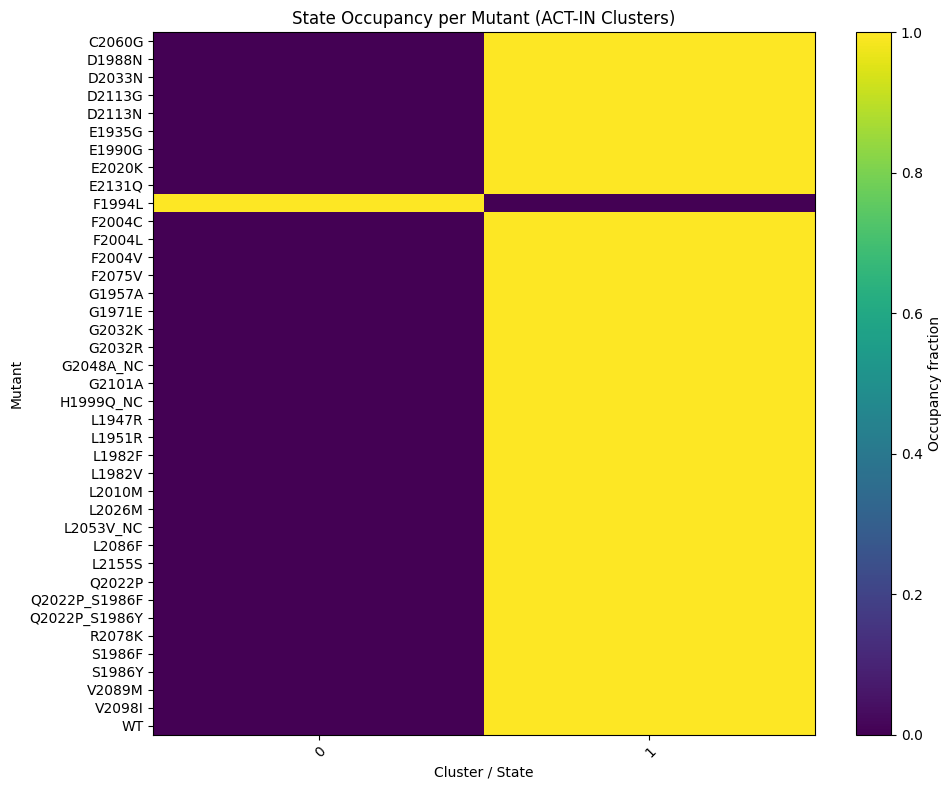

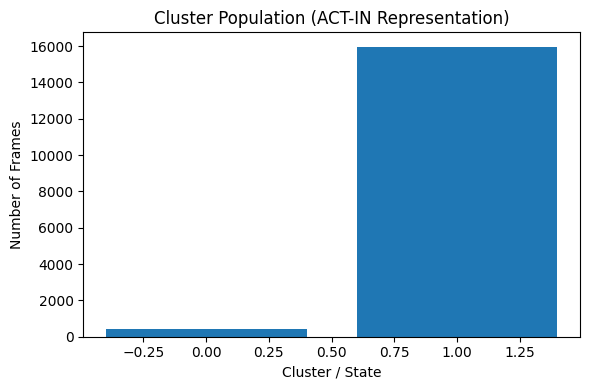

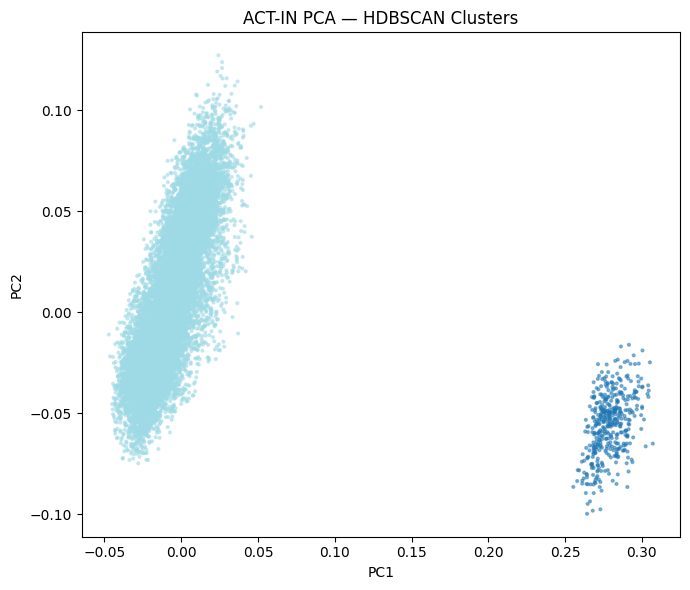

In [21]:
# ============================================================
# ACT-IN clustering + occupancy + heatmap
# ============================================================

ACT_IN_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_flat,
    x_owner=X_owner,
    F=F,
    prefix="actin",
    title_prefix="ACT-IN",
    n_pcs=5,
    min_cluster_size=200,
    eps=0.9,
    min_samples=60,
)


### Saved ACT-IN Results

Key outputs from the ACT-IN PCA analysis were stored in a dictionary for later reuse in clustering, visualization, and downstream interpretation.

In [22]:
PCA_ACT_IN = {
    "mean": mean.copy(),
    "loadings": loadings.copy(),
    "pscores": pscores_flat.copy(),
    "scores": scores_flat.copy(),
    "P_owner": P_owner.copy(),
    "X_owner": X_owner.copy(),
    "F": np.array(F, dtype=object),
    "sele": sele.copy(),
    "cluster_results": ACT_IN_CLUSTER,
}

## Global Kinase PCA (ACT-OUT)

To focus on the rigid core of the kinase domain, PCA was repeated excluding the activation loop.

Removing the activation loop reduces noise caused by its high flexibility and highlights global domain motions of the kinase core.

ACT-OUT sele atoms: 984 fit atoms: 984
[TIMER] ACT-OUT: aligning all trajectories on fit: 13.131 s


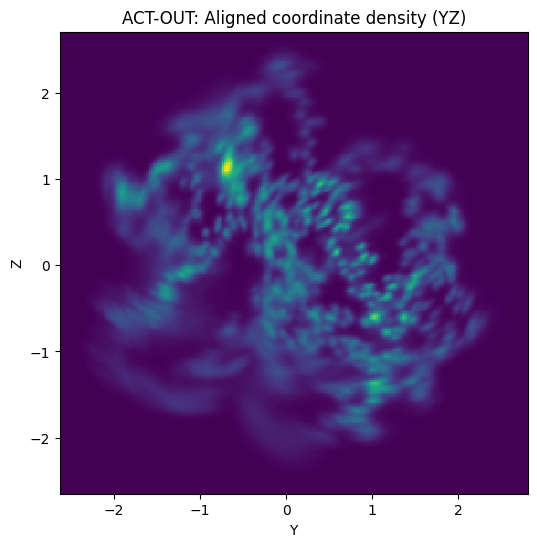

[TIMER] ACT-OUT: vectorizing deviations + building P/X: 5.709 s
ACT-OUT X shape: (16380, 2952)
[TIMER] ACT-OUT: PCA diagonalization: 5.595 s


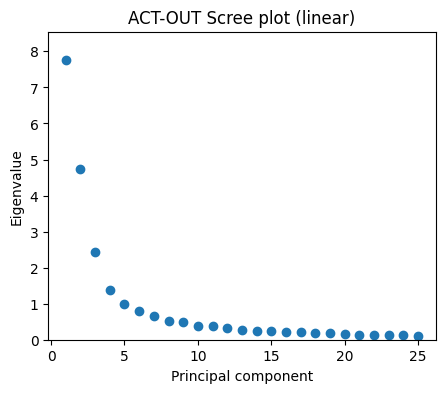

ACT-OUT cumulative variance (first 25):
[0.28 0.46 0.55 0.6  0.63 0.66 0.69 0.7  0.72 0.74 0.75 0.76 0.77 0.78
 0.79 0.8  0.8  0.81 0.82 0.82 0.83 0.83 0.84 0.84 0.85]
[TIMER] ACT-OUT: projections on first 10 PCs: 0.156 s


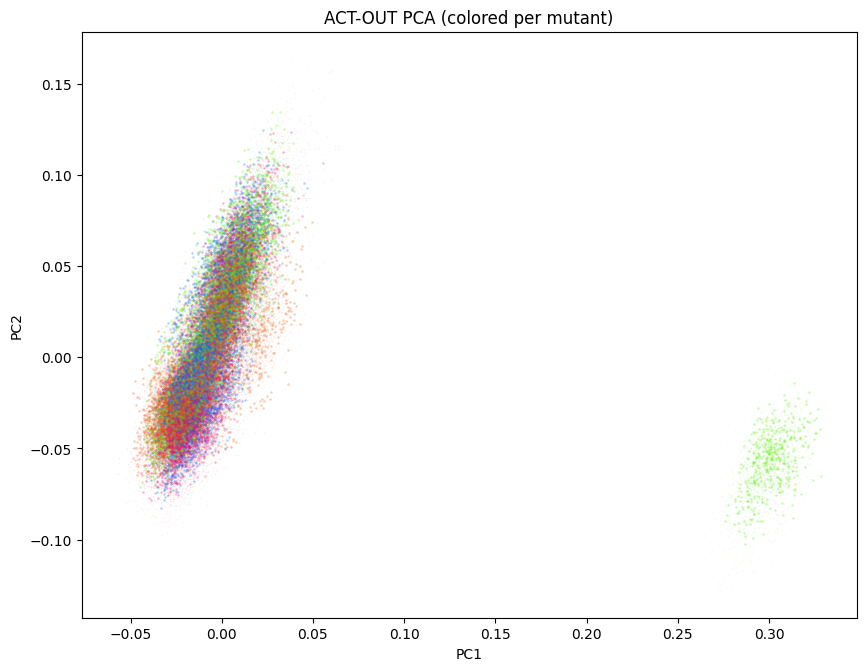

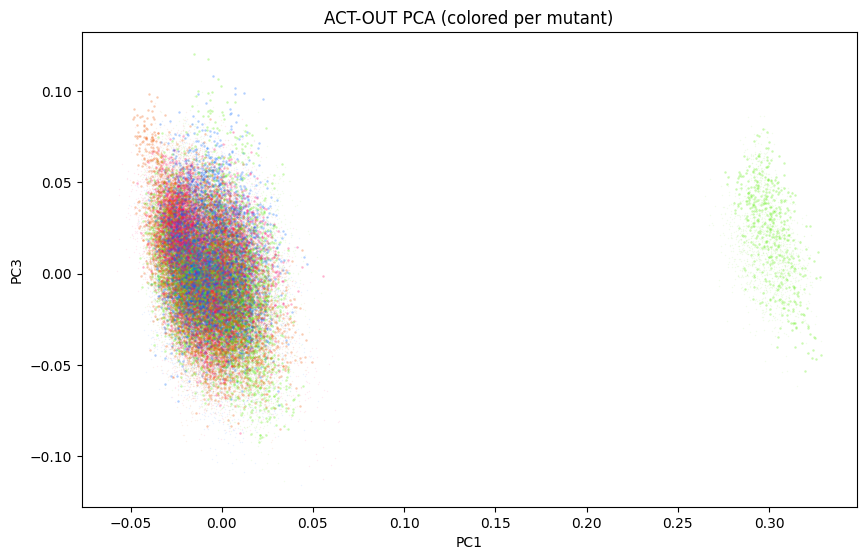

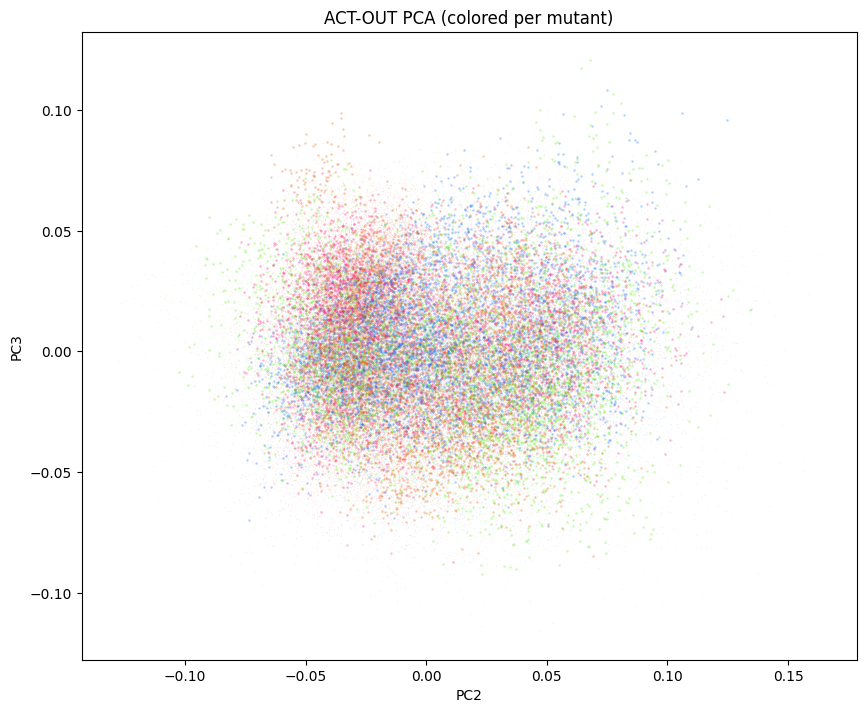

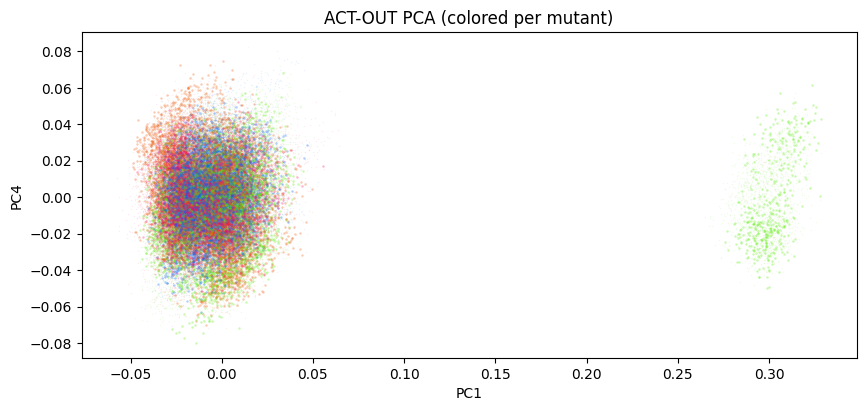

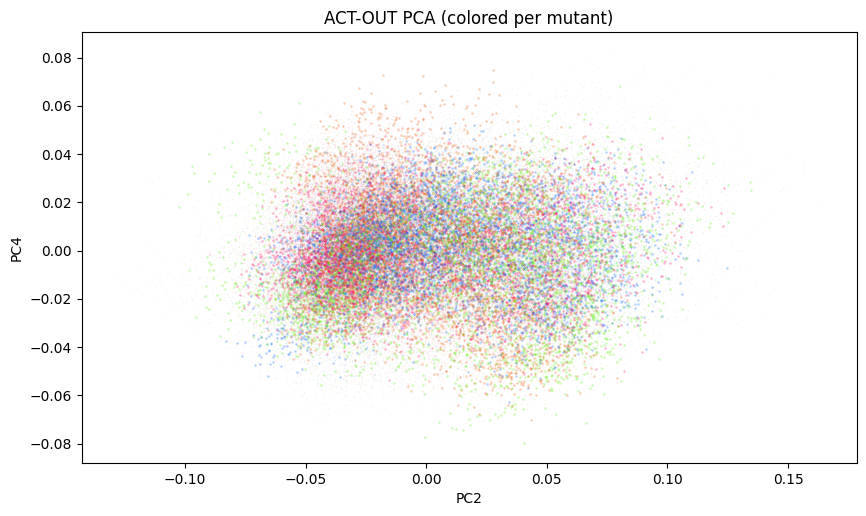

In [23]:
# ============================================================
# PCA on the whole kinase (ACT excluded)  
# ============================================================

# ---- 1) Defining ACT loop in meta.resids space (NOT +1933) ----
# ROS1 ACT range used: 2045-2070
# meta.resids are 1..291, and your plot uses resids_atom = meta.resids + 1933
act_lo = 2045 - 1933   # 112
act_hi = 2070 - 1933   # 137
ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)   # atom-level mask

# ---- 2) selections (BB/BODY already atom-level) ----
sele_actout = BB & BODY & (~ACT)
fit_actout  = sele_actout  

print("ACT-OUT sele atoms:", int(sele_actout.sum()), "fit atoms:", int(fit_actout.sum()))

# ---- 3) Re-align trajectories for this PCA selection ----
ref_actout_centered = ref_centered.copy()
ref_fit_actout = ref_actout_centered[fit_actout]
ref_fit_actout = ref_fit_actout - ref_fit_actout.mean(axis=0, keepdims=True)

def align_traj_to_ref_by_fit(xyz, fit_mask, ref_fit_centered):
    """
    xyz: (T, natoms, 3) on COMMON atoms
    returns aligned xyz: (T, natoms, 3)
    """
    xyz = xyz.copy().astype(np.float64)

    # centering each frame on fit COM
    xyz -= xyz[:, fit_mask].mean(axis=1, keepdims=True)
    Xfit = xyz[:, fit_mask]  # (T, nfit, 3)

    # rotation per frame
    M = np.einsum('ij,tjk->tik',
                  (ref_fit_centered.T / (3 * ref_fit_centered.shape[0])),
                  Xfit)  # (T,3,3)
    U, S, Vt = np.linalg.svd(M)
    R = U @ Vt  # (T,3,3)

    xyz = xyz @ np.transpose(R, (0, 2, 1))
    return xyz.astype(np.float32)

with tim("ACT-OUT: aligning all trajectories on fit"):
    traj_actout = [align_traj_to_ref_by_fit(xyz, fit_actout, ref_fit_actout) for xyz in traj_aligned]

# ---- 4) Aligned coordinate density  ----
plt.figure(figsize=(7,6))
A = []
for xyz in traj_actout:
    a = xyz[:, sele_actout, 1:].reshape((-1, 2))  # YZ
    mask = ~((np.abs(a[:,0]) < 1e-6) & (np.abs(a[:,1]) < 1e-6))
    A.append(a[mask])
A = np.vstack(A)
plt.hist2d(A[:,0], A[:,1], bins=256)
plt.gca().set_aspect('equal')
plt.title("ACT-OUT: Aligned coordinate density (YZ)")
plt.xlabel("Y"); plt.ylabel("Z")
plt.show()

# ---- 5) Vectorizing deviations and split per trajectory (variable length) ----
with tim("ACT-OUT: vectorizing deviations + building P/X"):
    # building global mean on selected atoms over ALL frames from ALL trajectories
    all_frames = []
    for xyz in traj_actout:
        all_frames.append(xyz[:, sele_actout].reshape(xyz.shape[0], -1))
    all_frames = np.vstack(all_frames)
    mean_actout = all_frames.mean(axis=0)   # (d,)
    d = mean_actout.size

    P_list, X_list = [], []
    P_owner, X_owner_actout = [], []

    for ti, xyz in enumerate(traj_actout):
        dev = xyz[:, sele_actout].reshape(xyz.shape[0], -1) - mean_actout
        split_idx = int(0.8 * dev.shape[0])  # defining the split to use

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner_actout.append(np.full(X_i.shape[0], ti, dtype=int))

    P_actout = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X_actout = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner_actout = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner_actout = np.concatenate(X_owner_actout) if len(X_owner_actout) else np.zeros((0,), dtype=int)

print("ACT-OUT X shape:", X_actout.shape)

# ---- 6) PCA diagonalization ----
with tim("ACT-OUT: PCA diagonalization"):
    C = X_actout.T @ (X_actout / len(X_actout))
    evals_actout, loadings_actout = np.linalg.eigh(C)
    idx = np.argsort(evals_actout)[::-1]
    evals_actout = evals_actout[idx]
    loadings_actout = loadings_actout[:, idx]

# ---- 7) Scree ----
plt.figure(figsize=(5,4))
plt.scatter(np.arange(1, 26), evals_actout[:25])
plt.ylim((0, 1.1 * evals_actout[:25].max()))
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("ACT-OUT Scree plot (linear)")
plt.show()

print("ACT-OUT cumulative variance (first 25):")
print(np.round(np.cumsum(evals_actout[:25]) / evals_actout.sum(), 2))

# ---- 8) PCA projections ----
ncomponents = 10
scale = np.sqrt(mean_actout.size)

with tim(f"ACT-OUT: projections on first {ncomponents} PCs"):
    pscores_flat_actout = (P_actout @ loadings_actout[:, :ncomponents]) / scale
    scores_flat_actout  = (X_actout @ loadings_actout[:, :ncomponents]) / scale

# ---- 9) colored per mutant scatter EXACTLY  ----
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(len(F) / len(traj_colors))))[:len(F)]

stride = 1
pairs = [(0,1), (0,2), (1,2), (0,3), (1,3)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # early (P): faint
    for ti in range(len(F)):
        m = (P_owner_actout == ti)
        Zi = pscores_flat_actout[m]
        ax.scatter(Zi[::stride, a], Zi[::stride, b],
                   s=1, c=[traj_colors[ti]], alpha=0.08, linewidths=0)

    # production (X): stronger
    for ti in range(len(F)):
        m = (X_owner_actout == ti)
        Zi = scores_flat_actout[m]
        ax.scatter(Zi[::stride, a], Zi[::stride, b],
                   s=3, c=[traj_colors[ti]], alpha=0.30, linewidths=0)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.title("ACT-OUT PCA (colored per mutant)")
    plt.show()


ACT-OUT HDBSCAN clusters: 2
ACT-OUT HDBSCAN noise fraction: 0.0
ACT-OUT DBSCAN clusters: 2
ACT-OUT DBSCAN noise fraction: 0.019597069597069597
ACT-OUT occupancy (HDBSCAN primary):


state,0,1
mutant,,
C2060G,0.0,1.0
D1988N,0.0,1.0
D2033N,0.0,1.0
D2113G,0.0,1.0
D2113N,0.0,1.0
E1935G,0.0,1.0
E1990G,0.0,1.0
E2020K,0.0,1.0
E2131Q,0.0,1.0


ACT-OUT occupancy (DBSCAN baseline):


state,-1,0,1
mutant,,,
C2060G,0.007143,0.992857,0.000000
D1988N,0.002381,0.997619,0.000000
D2033N,0.002381,0.997619,0.000000
D2113G,0.000000,1.000000,0.000000
D2113N,0.000000,1.000000,0.000000
E1935G,0.000000,1.000000,0.000000
E1990G,0.007143,0.992857,0.000000
E2020K,0.004762,0.995238,0.000000
E2131Q,0.023810,0.976190,0.000000


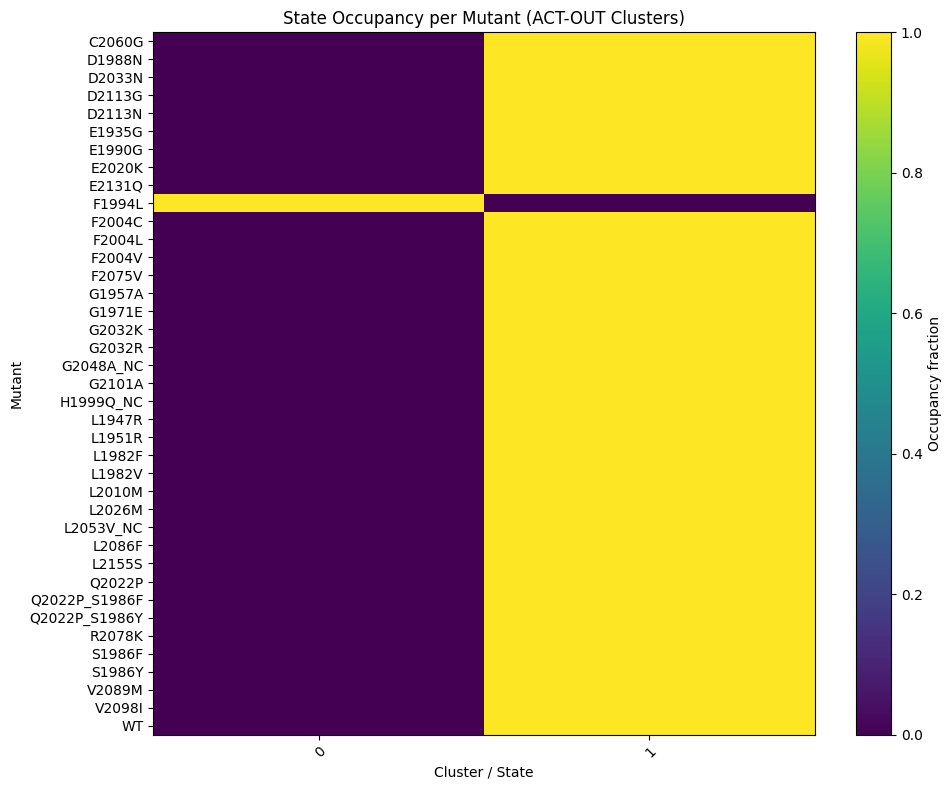

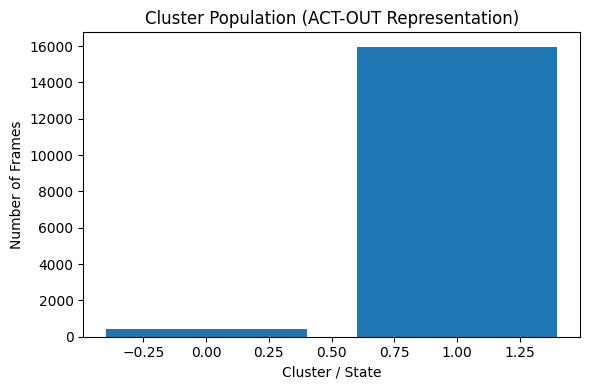

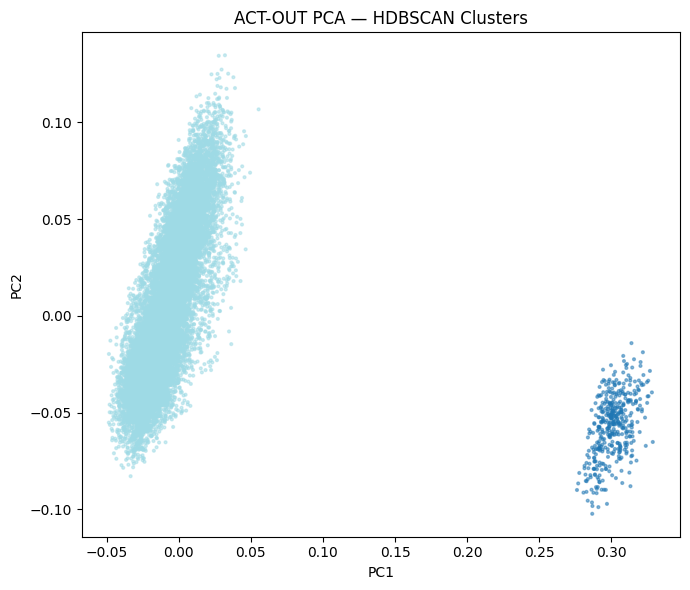

In [24]:
# ============================================================
# ACT-OUT clustering + occupancy + heatmap
# ============================================================

ACT_OUT_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_flat_actout,
    x_owner=X_owner_actout,
    F=F,
    prefix="actout",
    title_prefix="ACT-OUT",
    n_pcs=5,
    min_cluster_size=200,
    eps=0.9,
    min_samples=60,
)


## N-terminal Lobe PCA (NTL)

Principal component analysis was performed on the N-terminal lobe (NTL) of the kinase domain to isolate conformational variability specific to this regulatory region.

By aligning and analyzing the NTL separately, this section captures mutation-dependent changes in local lobe dynamics that may be masked in whole-kinase PCA.

NTL sele atoms: 507 fit atoms: 507
[TIMER] NTL: aligning all trajectories on fit: 7.862 s


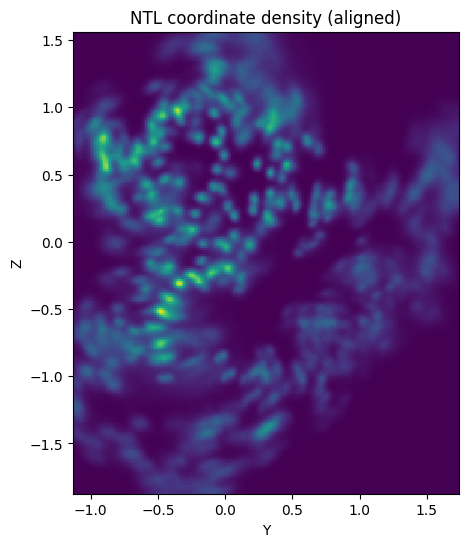

[TIMER] NTL: plotting aligned coordinate density: 6.984 s
[TIMER] NTL: vectorizing deviations + building P/X: 2.665 s
NTL X shape: (16380, 1521)
[TIMER] NTL: diagonalization: 1.142 s


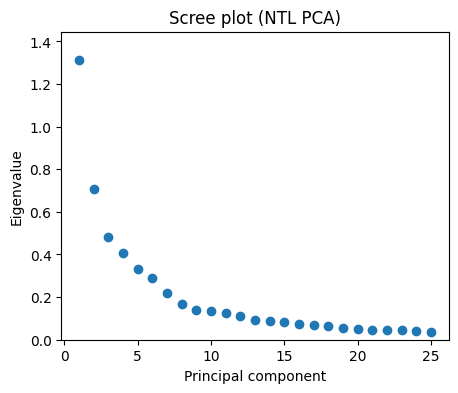

Cumulative variance (top 25):
[0.2  0.3  0.38 0.44 0.49 0.53 0.56 0.59 0.61 0.63 0.65 0.66 0.68 0.69
 0.7  0.72 0.73 0.74 0.74 0.75 0.76 0.77 0.77 0.78 0.78]
[TIMER] NTL: projections on first 10 PCs (scaled to RMSD-like): 0.102 s


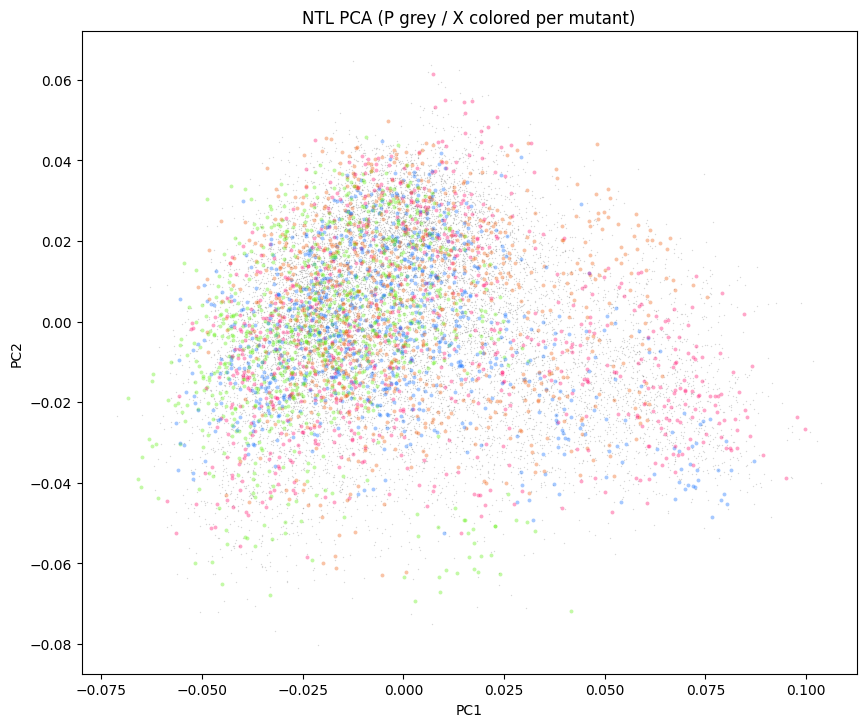

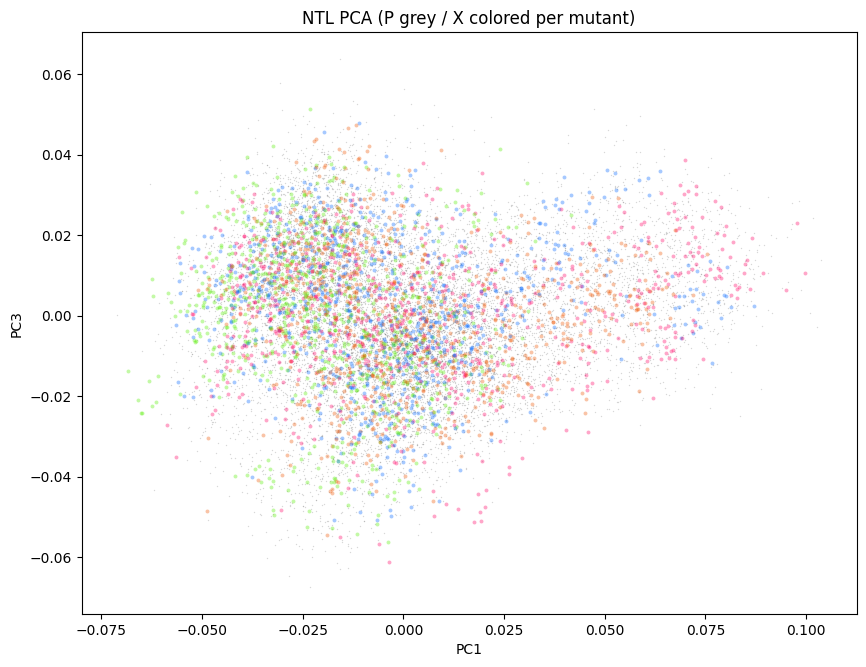

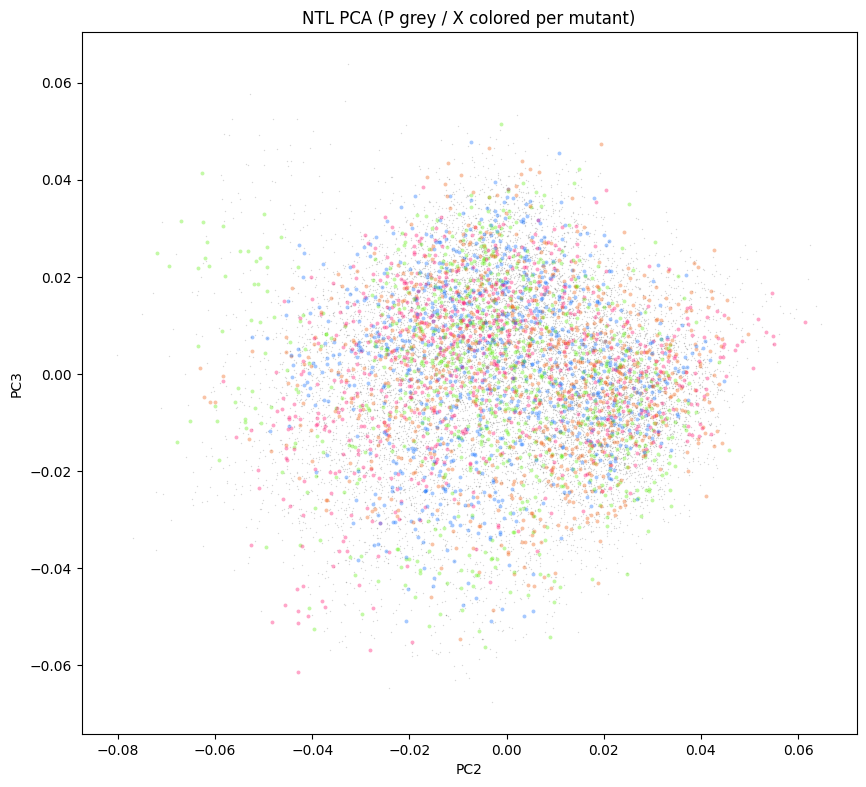

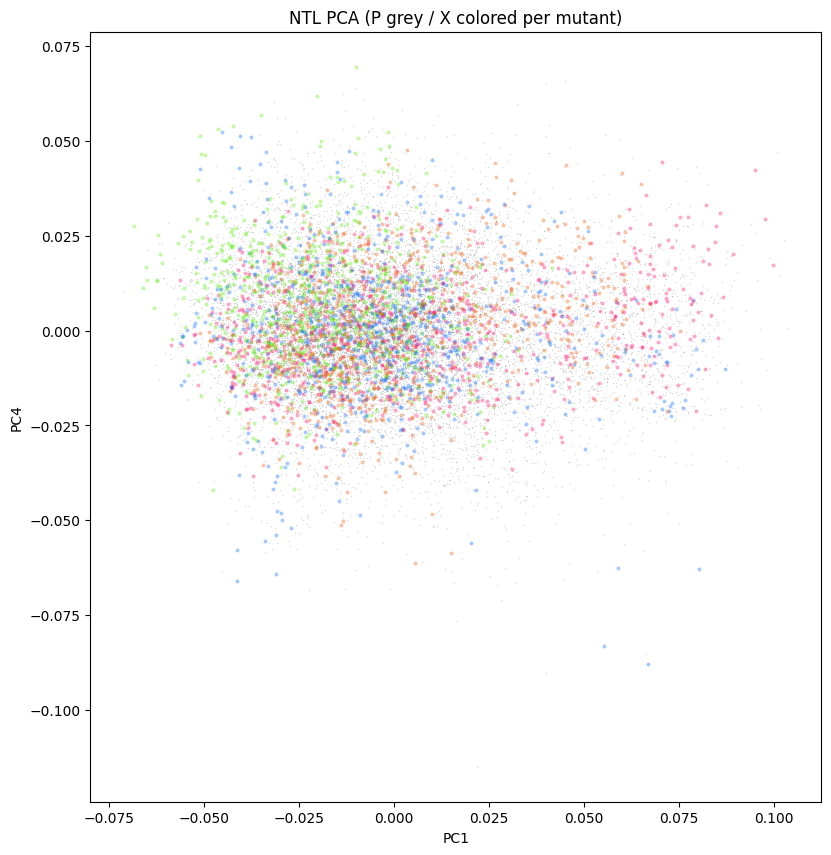

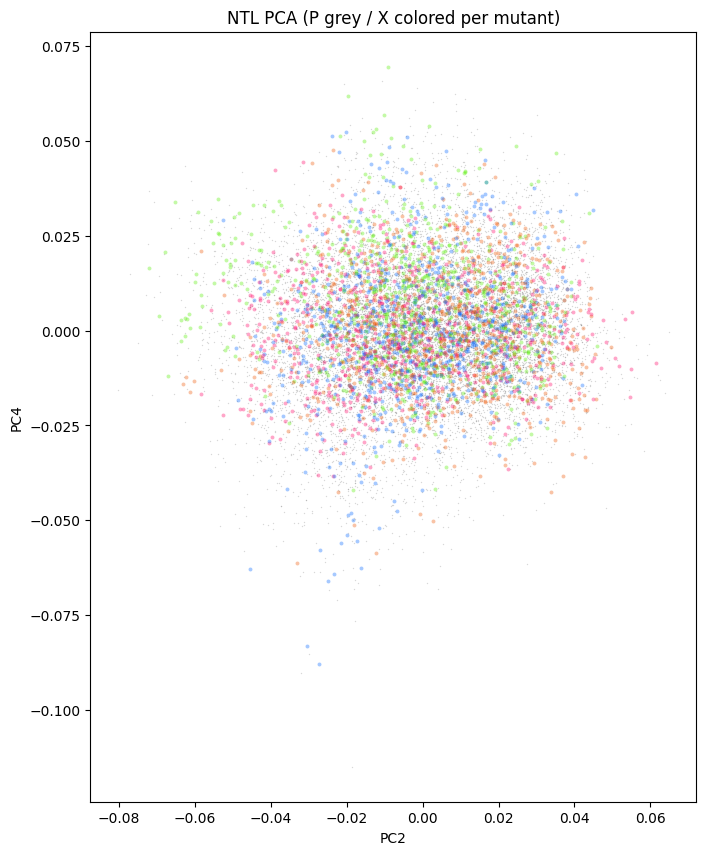

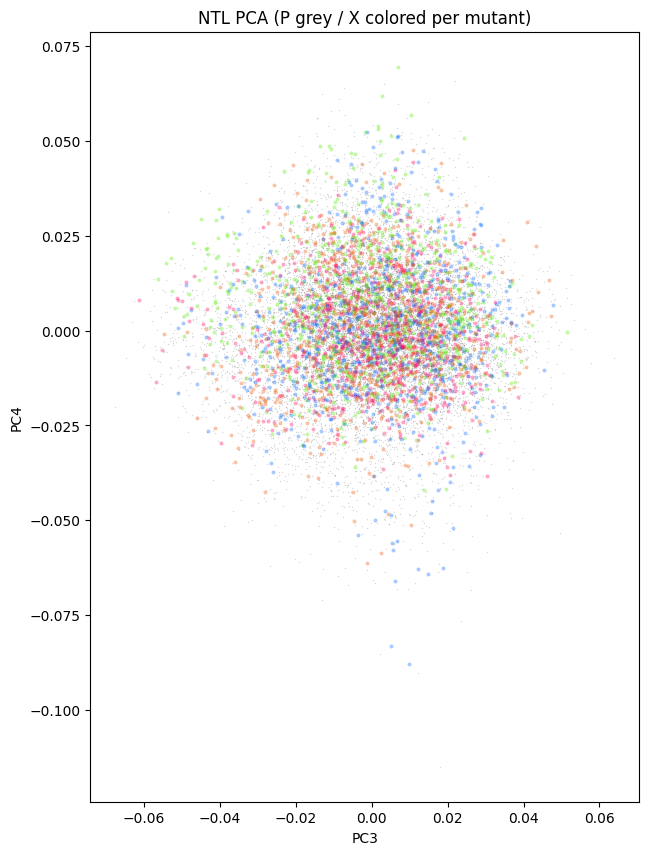

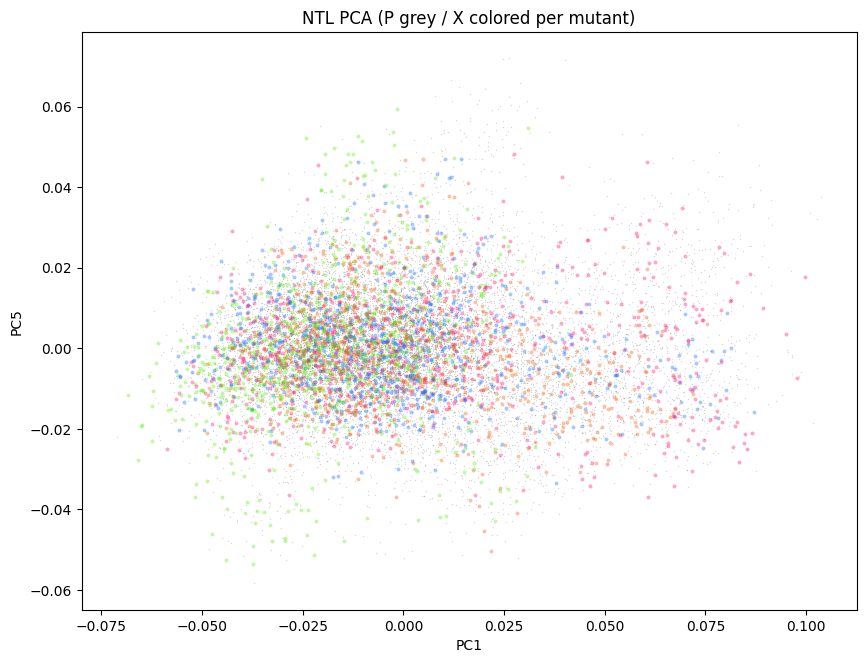

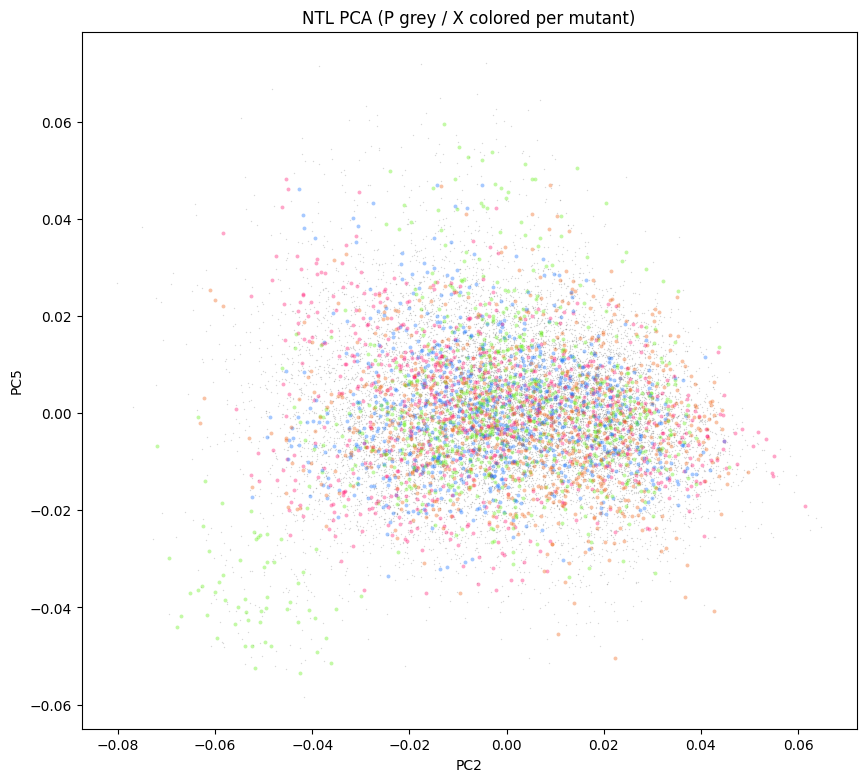

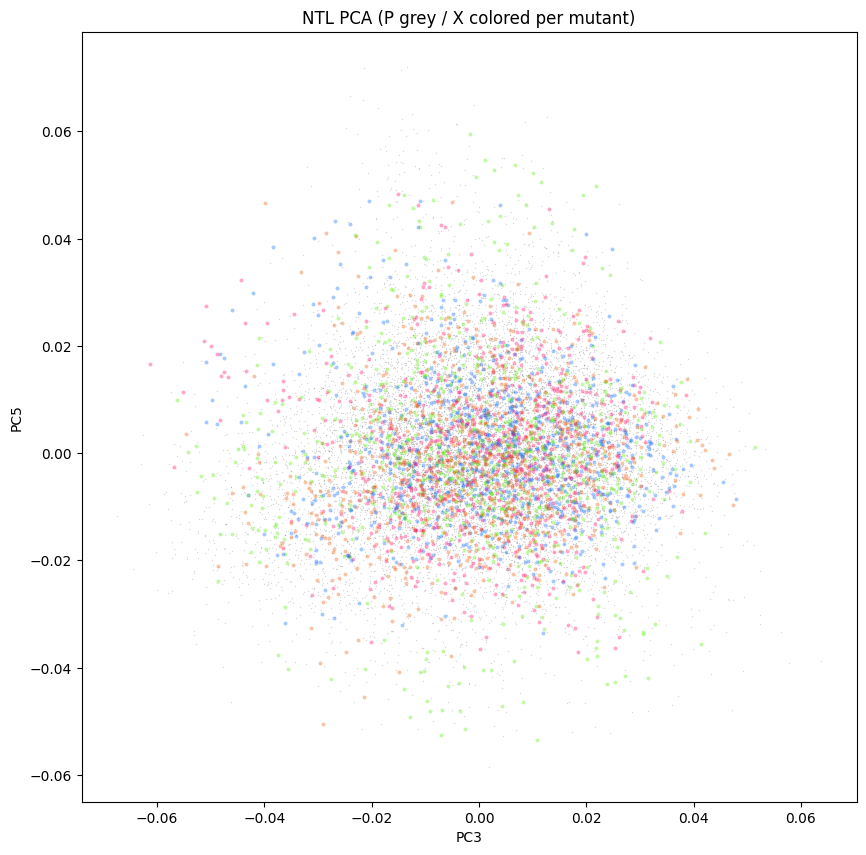

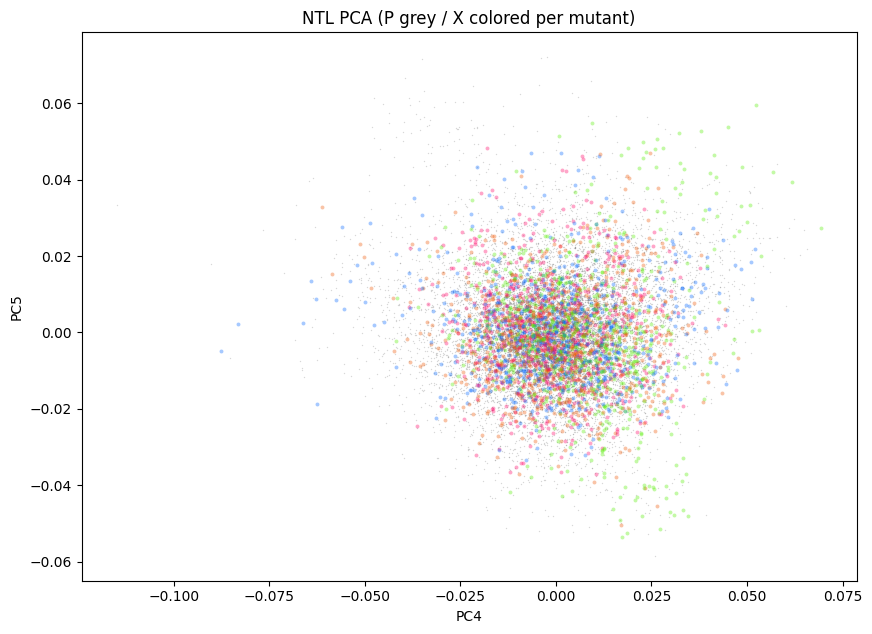

In [25]:
# ============================================================
# NTL PCA  
# ============================================================


eps = 1e-6

# -----------------------------
# 0) Selection masks (atom-level)
# -----------------------------

sele_ntl = BODY & NTL & (~ACT)
fit_ntl  = sele_ntl

print("NTL sele atoms:", int(sele_ntl.sum()), "fit atoms:", int(fit_ntl.sum()))

# -----------------------------
# 1) Align each trajectory on NTL fit
# -----------------------------
ref_fit_ntl = ref_centered[fit_ntl]
ref_fit_ntl = ref_fit_ntl - ref_fit_ntl.mean(axis=0, keepdims=True)

def align_traj_to_ref_by_fit(xyz, fit_mask, ref_fit_centered):
    """
    xyz: (T, natoms, 3) for ONE trajectory on COMMON atoms
    returns aligned xyz: (T, natoms, 3)
    """
    xyz = xyz.copy().astype(np.float64)

    # center each frame on fit COM
    xyz -= xyz[:, fit_mask].mean(axis=1, keepdims=True)
    Xfit = xyz[:, fit_mask]  # (T, nfit, 3)

    # rotation per frame
    M = np.einsum(
        "ij,tjk->tik",
        (ref_fit_centered.T / (3 * ref_fit_centered.shape[0])),
        Xfit
    )  # (T,3,3)

    U, S, Vt = np.linalg.svd(M)
    R = U @ Vt  # (T,3,3)

    xyz = xyz @ np.transpose(R, (0, 2, 1))
    return xyz.astype(np.float32)

with tim("NTL: aligning all trajectories on fit"):
    traj_ntl = [align_traj_to_ref_by_fit(xyz, fit_ntl, ref_fit_ntl) for xyz in traj_aligned]

# -----------------------------
# 2) Plot aligned coordinate density (YZ) with auto-zoom
# -----------------------------
with tim("NTL: plotting aligned coordinate density"):
    A = []
    for xyz in traj_ntl:
        a = xyz[:, sele_ntl, 1:].reshape((-1, 2)).astype(np.float32)  # YZ
        mask = ~((np.abs(a[:,0]) < eps) & (np.abs(a[:,1]) < eps))
        A.append(a[mask])
    A = np.vstack(A)

    y0, y1 = np.percentile(A[:, 0], [1, 99])
    z0, z1 = np.percentile(A[:, 1], [1, 99])

    plt.figure(figsize=(7, 6))
    plt.hist2d(A[:, 0], A[:, 1], bins=256, range=[[y0, y1], [z0, z1]])
    plt.gca().set_aspect("equal")
    plt.title("NTL coordinate density (aligned)")
    plt.xlabel("Y"); plt.ylabel("Z")
    plt.show()

# -----------------------------
# 3) Vectorize deviations + split per trajectory (variable length)
# -----------------------------
with tim("NTL: vectorizing deviations + building P/X"):
    # global mean over ALL frames (selected atoms only)
    all_frames = []
    for xyz in traj_ntl:
        all_frames.append(xyz[:, sele_ntl].reshape(xyz.shape[0], -1))
    all_frames = np.vstack(all_frames)
    mean_ntl = all_frames.mean(axis=0)   # (d,)
    d = mean_ntl.size

    P_list, X_list = [], []
    P_owner, X_owner = [], []

    for ti, xyz in enumerate(traj_ntl):
        dev = xyz[:, sele_ntl].reshape(xyz.shape[0], -1) - mean_ntl
        split_idx = int(0.8 * dev.shape[0])   # per-trajectory split

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

print("NTL X shape:", X.shape)

# -----------------------------
# 4) PCA diagonalization (eigh on covariance)
# -----------------------------
with tim("NTL: diagonalization"):
    C = X.T @ (X / len(X))
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

plt.figure(figsize=(5, 4))
plt.scatter(np.arange(1, 26), evals[:25])
plt.ylim((0, float(1.1 * evals[:25].max())))
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (NTL PCA)")
plt.show()

print("Cumulative variance (top 25):")
print(np.round(np.cumsum(evals[:25]) / evals.sum(), 2))

# -----------------------------
# 5) Projections (scores) 
# -----------------------------
ncomponents = 10
scale = np.sqrt(mean_ntl.size)

with tim(f"NTL: projections on first {ncomponents} PCs (scaled to RMSD-like)"):
    pscores_flat = (P @ loadings[:, :ncomponents]) / scale
    scores_flat  = (X @ loadings[:, :ncomponents]) / scale

# color per trajectory (same color for 3 replicas)
ntraj = len(F)
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(ntraj / len(traj_colors))))[:ntraj]

stride = 5
pairs = [(0,1), (0,2), (1,2), (0,3), (1,3), (2,3), (0,4), (1,4), (2,4), (3,4)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # early frames (P): grey 
    ax.scatter(pscores_flat[::stride, a], pscores_flat[::stride, b],
               c="#666", s=1, alpha=0.25, linewidths=0)

    # production frames (X): colored per trajectory 
    for ti in range(ntraj):
        m = (X_owner == ti)
        Zi = scores_flat[m]
        ax.scatter(Zi[::stride, a], Zi[::stride, b],
                   s=8, c=[traj_colors[ti]], alpha=0.35, linewidths=0)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.title("NTL PCA (P grey / X colored per mutant)")
    plt.show()


NTL HDBSCAN clusters: 2
NTL HDBSCAN noise fraction: 0.9677655677655678
NTL DBSCAN clusters: 2
NTL DBSCAN noise fraction: 0.2368131868131868
NTL occupancy (HDBSCAN primary):


state,-1,0,1
mutant,,,
C2060G,0.928571,0.045238,0.026190
D1988N,0.957143,0.019048,0.023810
D2033N,0.921429,0.052381,0.026190
D2113G,0.980952,0.000000,0.019048
D2113N,0.933333,0.000000,0.066667
E1935G,0.940476,0.035714,0.023810
E1990G,0.935714,0.052381,0.011905
E2020K,1.000000,0.000000,0.000000
E2131Q,1.000000,0.000000,0.000000


NTL occupancy (DBSCAN baseline):


state,-1,0,1
mutant,,,
C2060G,0.021429,0.978571,0.000000
D1988N,0.142857,0.857143,0.000000
D2033N,0.047619,0.952381,0.000000
D2113G,0.302381,0.697619,0.000000
D2113N,0.190476,0.809524,0.000000
E1935G,0.069048,0.930952,0.000000
E1990G,0.185714,0.669048,0.145238
E2020K,0.561905,0.438095,0.000000
E2131Q,0.319048,0.680952,0.000000


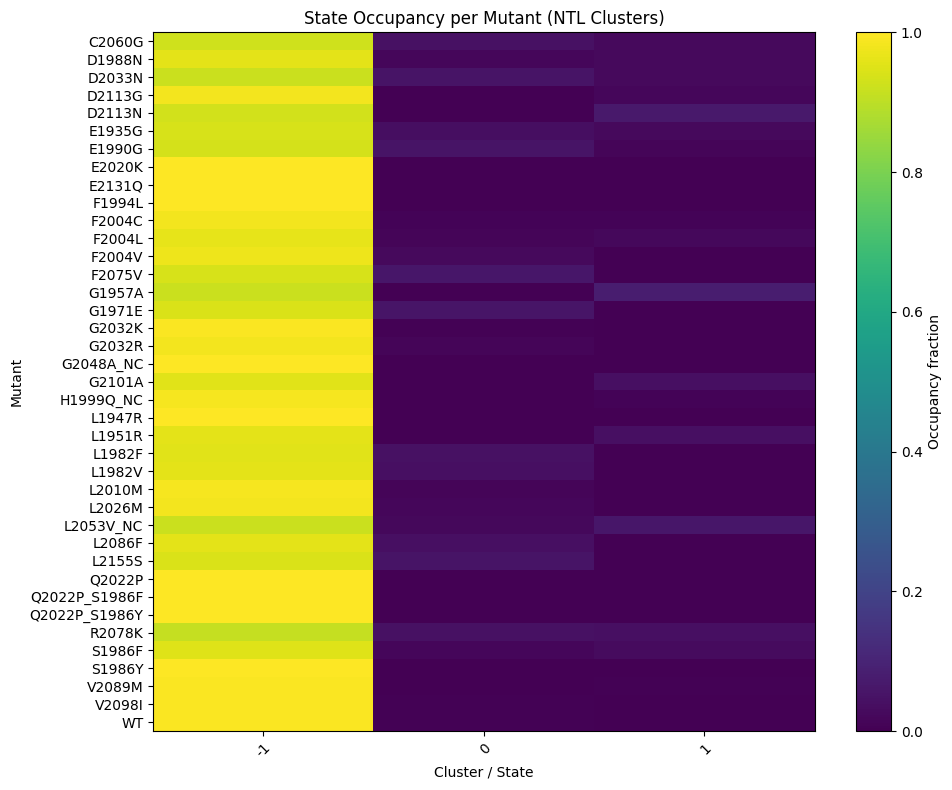

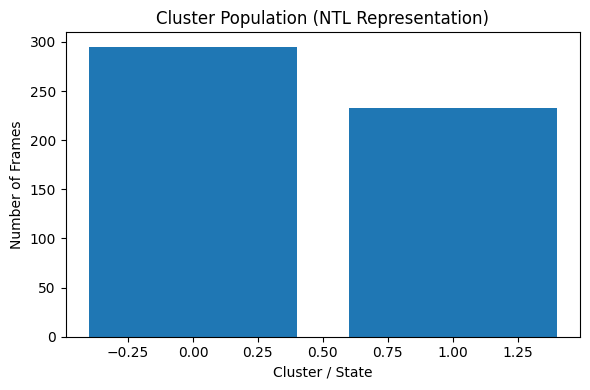

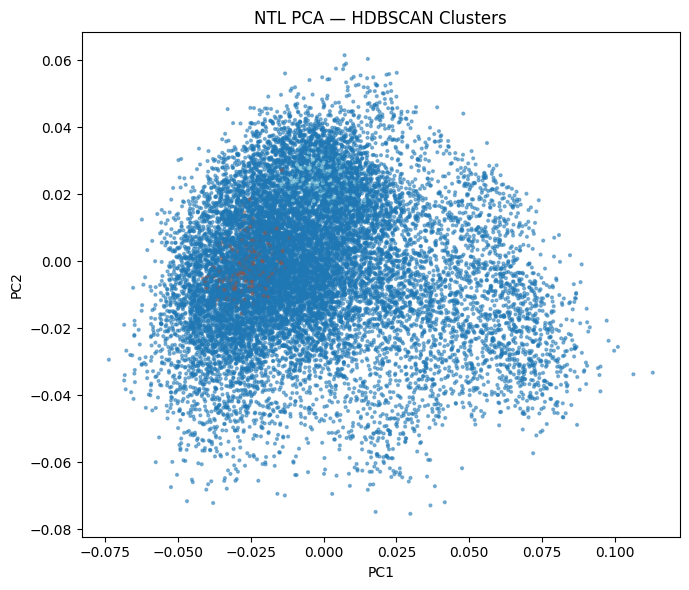

In [26]:
# ============================================================
# NTL clustering + occupancy + heatmap
# ============================================================

NTL_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_flat,
    x_owner=X_owner,
    F=F,
    prefix="ntl",
    title_prefix="NTL",
    n_pcs=5,
    min_cluster_size=150,
    eps=0.8,
    min_samples=60,
)


## C-terminal Lobe PCA (CTL)

Principal component analysis was performed on the C-terminal lobe (CTL) of the kinase domain, excluding the activation loop.

This analysis focuses on structural variability within the more rigid catalytic lobe and allows comparison of mutant-dependent conformational shifts in the kinase core.

CTL sele atoms: 862 fit atoms: 862
[TIMER] CTL: aligning all trajectories on fit: 10.420 s


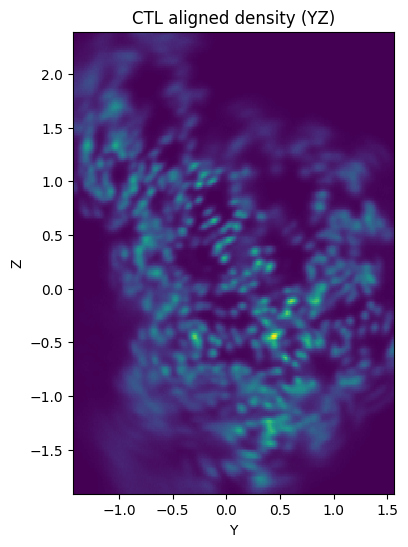

[TIMER] CTL: plotting aligned coordinate density (YZ): 11.770 s
[TIMER] CTL: vectorizing deviations + building P/X: 4.841 s
CTL X shape: (16380, 2586)
[TIMER] CTL: diagonalization: 3.459 s


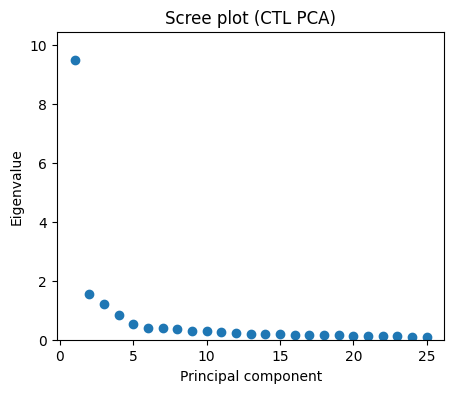

Cumulative variance (top 25):
[0.45 0.52 0.57 0.61 0.64 0.66 0.68 0.69 0.71 0.72 0.73 0.74 0.75 0.76
 0.77 0.78 0.79 0.79 0.8  0.81 0.81 0.82 0.82 0.83 0.83]
[TIMER] CTL: projections on first 10 PCs (scaled RMSD-like): 0.190 s


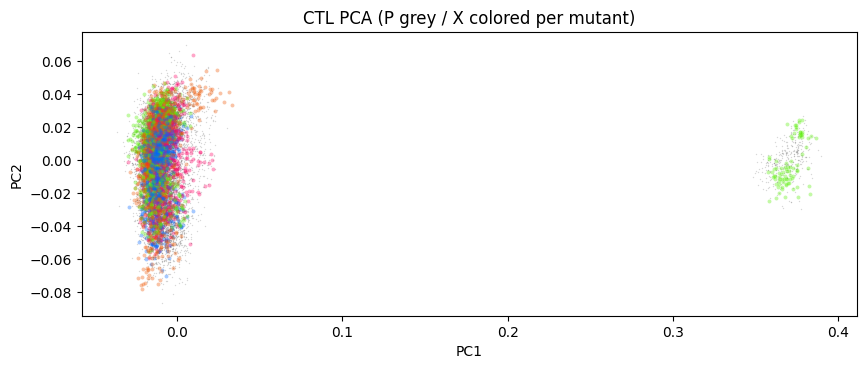

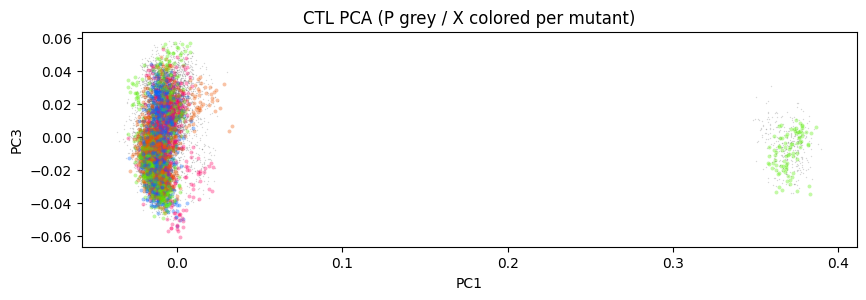

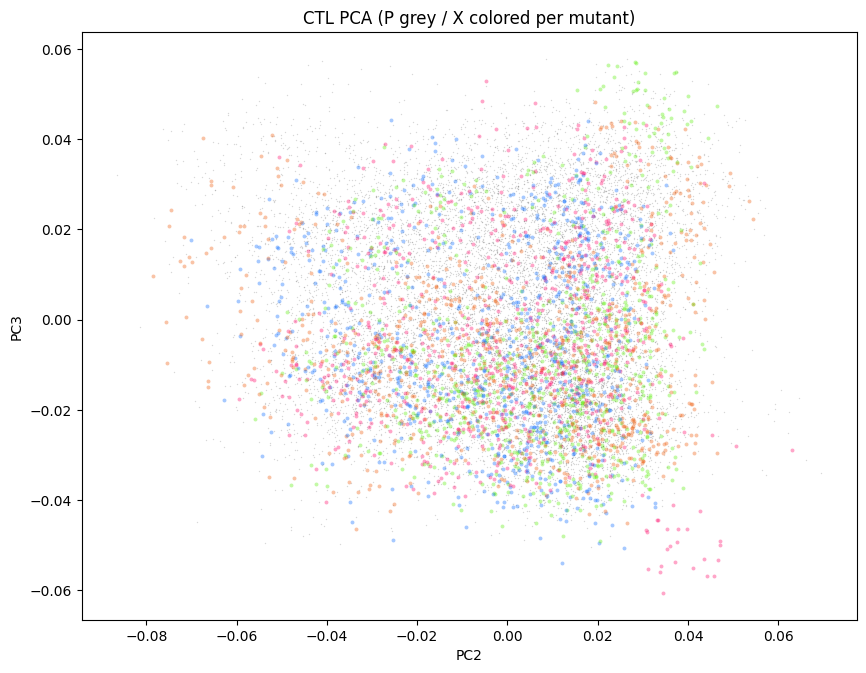

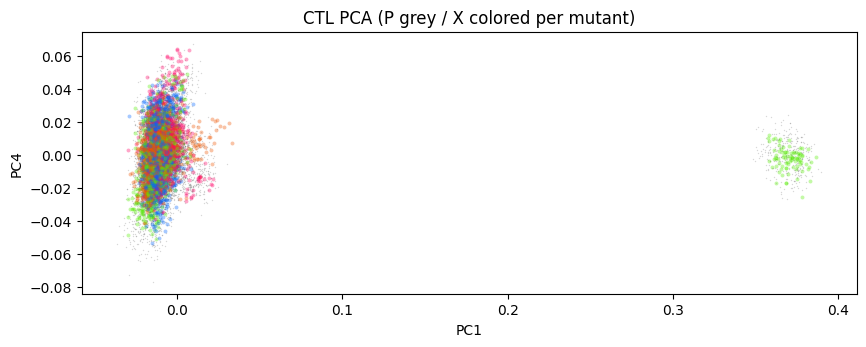

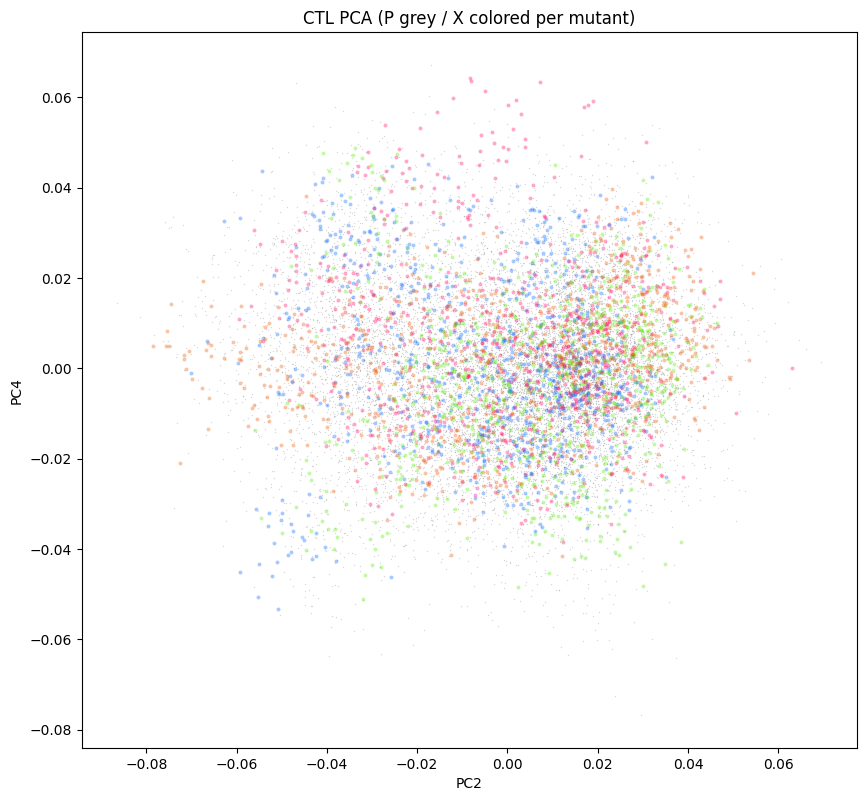

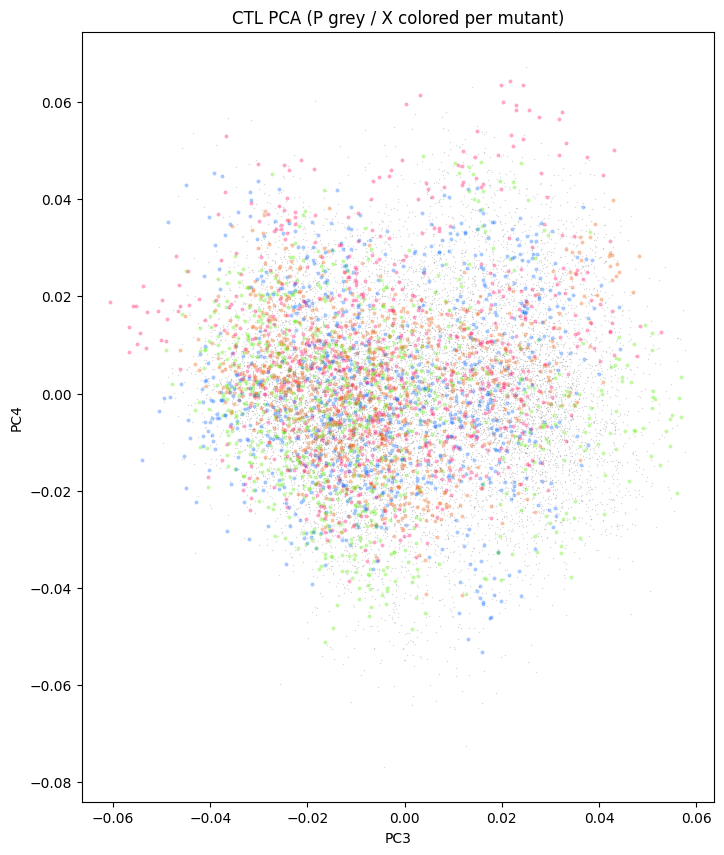

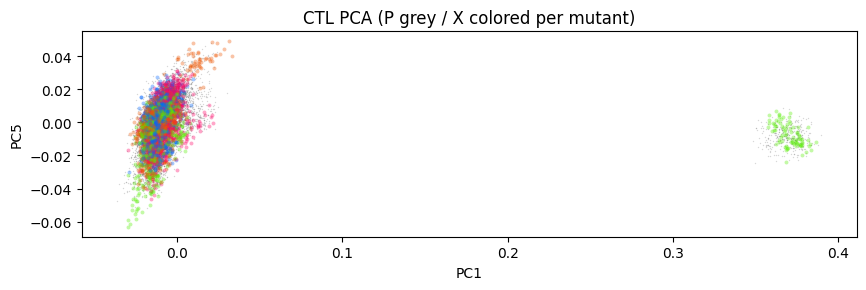

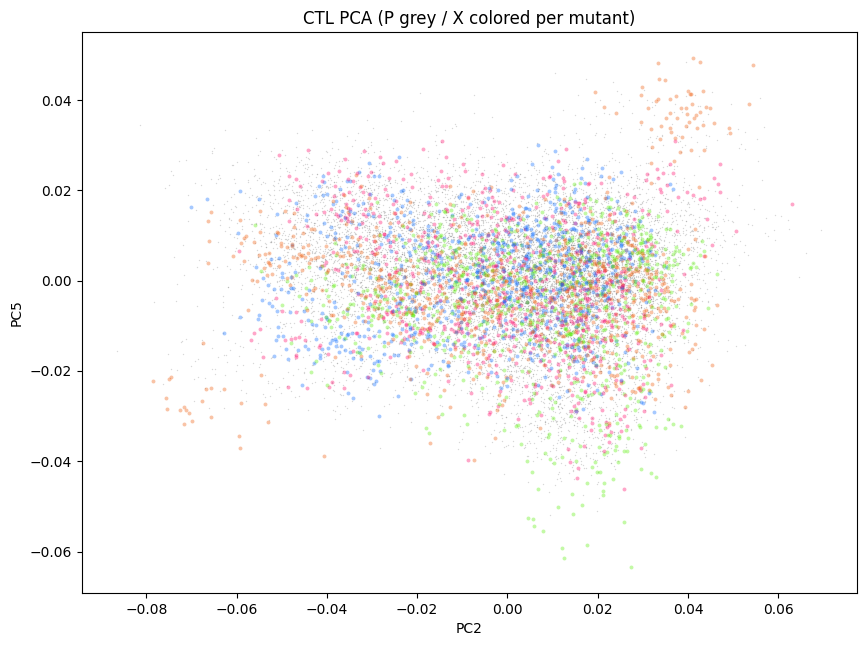

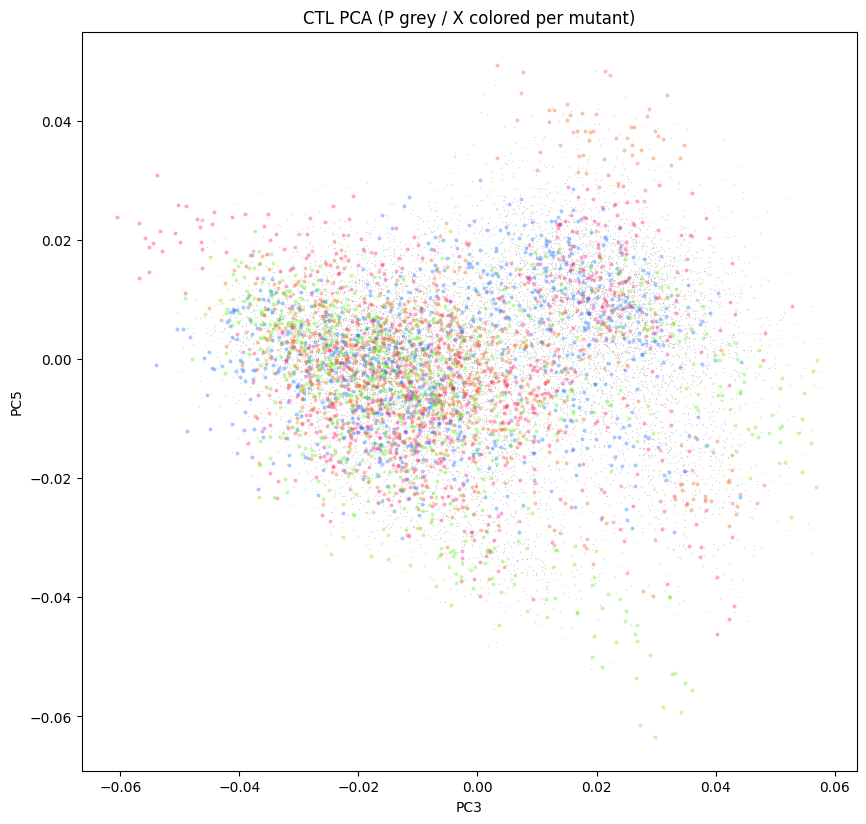

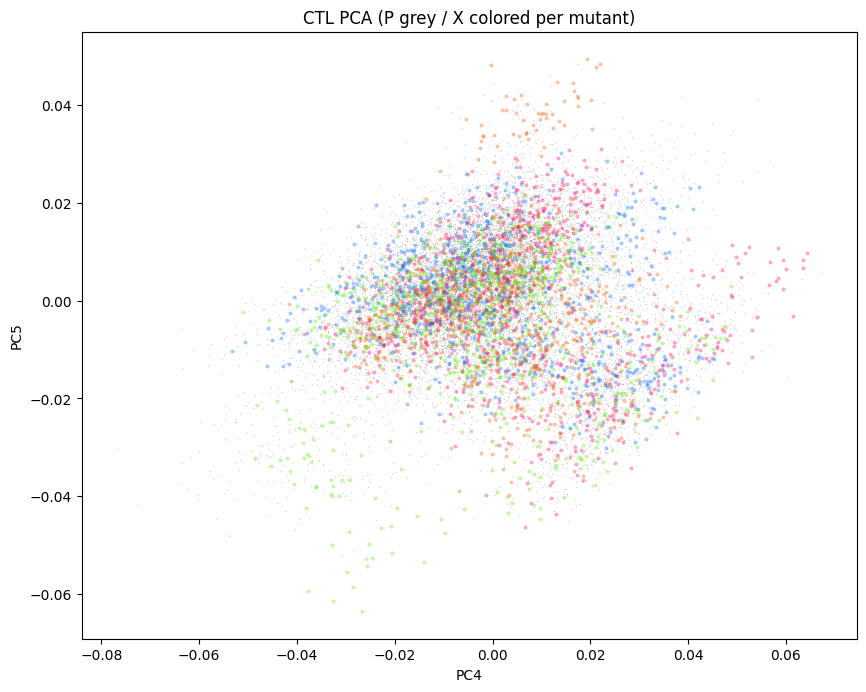

In [27]:
# ============================================================
# PCA on CTL ONLY (C-terminal lobe), ACT excluded
# ============================================================

eps = 1e-6

# -----------------------------
# 0) Ensure ACT exists (atom-level mask on meta)
# -----------------------------
if "ACT" not in globals():
    act_lo = 2045 - 1933
    act_hi = 2070 - 1933
    ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)

# -----------------------------
# 0b) Define CTL residues in meta.resids space (1..291)
# -----------------------------
ctl_lo = 2031 - 1933
ctl_hi = 2225 - 1933
CTL_res = (meta.resids >= ctl_lo) & (meta.resids <= ctl_hi)   # atom-level

# -----------------------------
# 0c) Selection
# -----------------------------
sele_ctl = BODY & CTL_res & (~ACT)
fit_ctl  = sele_ctl

print("CTL sele atoms:", int(sele_ctl.sum()), "fit atoms:", int(fit_ctl.sum()))

# -----------------------------
# 1) Align each trajectory on CTL fit (local)
# -----------------------------
ref_fit_ctl = ref_centered[fit_ctl]
ref_fit_ctl = ref_fit_ctl - ref_fit_ctl.mean(axis=0, keepdims=True)

def align_traj_to_ref_by_fit(xyz, fit_mask, ref_fit_centered):
    """
    xyz: (T, natoms, 3) for ONE trajectory on COMMON atoms
    returns aligned xyz: (T, natoms, 3)
    """
    xyz = xyz.copy().astype(np.float64)

    # center each frame on fit COM
    xyz -= xyz[:, fit_mask].mean(axis=1, keepdims=True)
    Xfit = xyz[:, fit_mask]  # (T, nfit, 3)

    # rotation per frame
    M = np.einsum(
        "ij,tjk->tik",
        (ref_fit_centered.T / (3 * ref_fit_centered.shape[0])),
        Xfit
    )  # (T,3,3)

    U, S, Vt = np.linalg.svd(M)
    R = U @ Vt  # (T,3,3)

    xyz = xyz @ np.transpose(R, (0, 2, 1))
    return xyz.astype(np.float32)

with tim("CTL: aligning all trajectories on fit"):
    traj_ctl = [align_traj_to_ref_by_fit(xyz, fit_ctl, ref_fit_ctl) for xyz in traj_aligned]

# -----------------------------
# 2) Cloud plot (YZ) with auto-zoom
# -----------------------------
with tim("CTL: plotting aligned coordinate density (YZ)"):
    A = []
    for xyz in traj_ctl:
        a = xyz[:, sele_ctl, 1:].reshape((-1, 2)).astype(np.float32)  # YZ
        m = ~((np.abs(a[:,0]) < eps) & (np.abs(a[:,1]) < eps))
        A.append(a[m])
    A = np.vstack(A)

    y0, y1 = np.percentile(A[:, 0], [1, 99])
    z0, z1 = np.percentile(A[:, 1], [1, 99])

    plt.figure(figsize=(7, 6))
    plt.hist2d(A[:, 0], A[:, 1], bins=256, range=[[y0, y1], [z0, z1]])
    plt.gca().set_aspect("equal")
    plt.title("CTL aligned density (YZ)")
    plt.xlabel("Y"); plt.ylabel("Z")
    plt.show()

# -----------------------------
# 3) Vectorize deviations + split per trajectory (variable length)
# -----------------------------
with tim("CTL: vectorizing deviations + building P/X"):
    # global mean over all frames (selected atoms only)
    all_frames = []
    for xyz in traj_ctl:
        all_frames.append(xyz[:, sele_ctl].reshape(xyz.shape[0], -1))
    all_frames = np.vstack(all_frames)
    mean_ctl = all_frames.mean(axis=0)   # (d,)
    d = mean_ctl.size

    P_list, X_list = [], []
    P_owner, X_owner = [], []

    for ti, xyz in enumerate(traj_ctl):
        dev = xyz[:, sele_ctl].reshape(xyz.shape[0], -1) - mean_ctl
        split_idx = int(0.8 * dev.shape[0])   # per-trajectory split (NOT hard 800)

        P_i = dev[:split_idx]
        X_i = dev[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))

    P_ctl = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X_ctl = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner_ctl = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner_ctl = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)

print("CTL X shape:", X_ctl.shape)

# -----------------------------
# 4) PCA diagonalization (feature covariance)
# -----------------------------
with tim("CTL: diagonalization"):
    C = X_ctl.T @ (X_ctl / len(X_ctl))
    evals, loadings_ctl = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings_ctl = loadings_ctl[:, order]

plt.figure(figsize=(5, 4))
plt.scatter(np.arange(1, 26), evals[:25])
plt.ylim((0, float(1.1 * evals[:25].max())))
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (CTL PCA)")
plt.show()

print("Cumulative variance (top 25):")
print(np.round(np.cumsum(evals[:25]) / evals.sum(), 2))

# -----------------------------
# 5) Projections (scores) 
# -----------------------------
ncomponents = 10
scale = np.sqrt(mean_ctl.size)

with tim(f"CTL: projections on first {ncomponents} PCs (scaled RMSD-like)"):
    pscores_flat_ctl = (P_ctl @ loadings_ctl[:, :ncomponents]) / scale
    scores_flat_ctl  = (X_ctl @ loadings_ctl[:, :ncomponents]) / scale

# color per trajectory (same color for 3 replicas)
ntraj = len(F)
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(ntraj / len(traj_colors))))[:ntraj]

stride = 5
pairs = [(0,1),(0,2),(1,2),(0,3),(1,3),(2,3),(0,4),(1,4),(2,4),(3,4)]

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10, 10))

    # early (P): grey
    ax.scatter(pscores_flat_ctl[::stride, a], pscores_flat_ctl[::stride, b],
               c="#666", s=1, alpha=0.25, linewidths=0)

    # production (X): colored by trajectory
    for ti in range(ntraj):
        m = (X_owner_ctl == ti)
        Zi = scores_flat_ctl[m]
        ax.scatter(Zi[::stride, a], Zi[::stride, b],
                   s=8, c=[traj_colors[ti]], alpha=0.35, linewidths=0)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.title("CTL PCA (P grey / X colored per mutant)")
    plt.show()


CTL HDBSCAN clusters: 2
CTL HDBSCAN noise fraction: 0.0
CTL DBSCAN clusters: 3
CTL DBSCAN noise fraction: 0.013431013431013432
CTL occupancy (HDBSCAN primary):


state,0,1
mutant,,
C2060G,0.0,1.0
D1988N,0.0,1.0
D2033N,0.0,1.0
D2113G,0.0,1.0
D2113N,0.0,1.0
E1935G,0.0,1.0
E1990G,0.0,1.0
E2020K,0.0,1.0
E2131Q,0.0,1.0


CTL occupancy (DBSCAN baseline):


state,-1,0,1,2
mutant,,,,
C2060G,0.000000,1.000000,0.000000,0.000000
D1988N,0.000000,1.000000,0.000000,0.000000
D2033N,0.000000,1.000000,0.000000,0.000000
D2113G,0.000000,1.000000,0.000000,0.000000
D2113N,0.000000,1.000000,0.000000,0.000000
E1935G,0.000000,1.000000,0.000000,0.000000
E1990G,0.000000,1.000000,0.000000,0.000000
E2020K,0.071429,0.928571,0.000000,0.000000
E2131Q,0.004762,0.995238,0.000000,0.000000


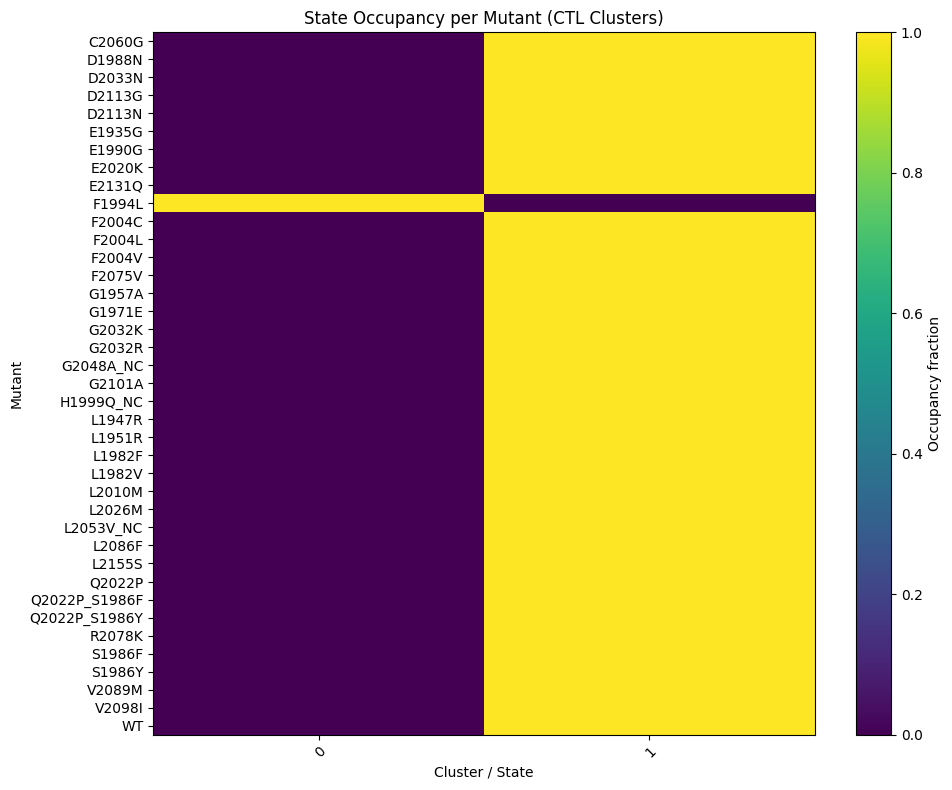

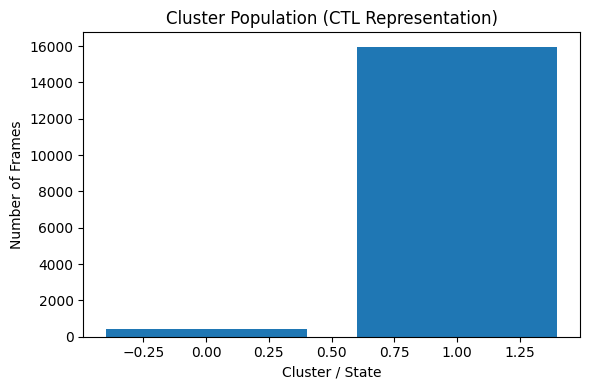

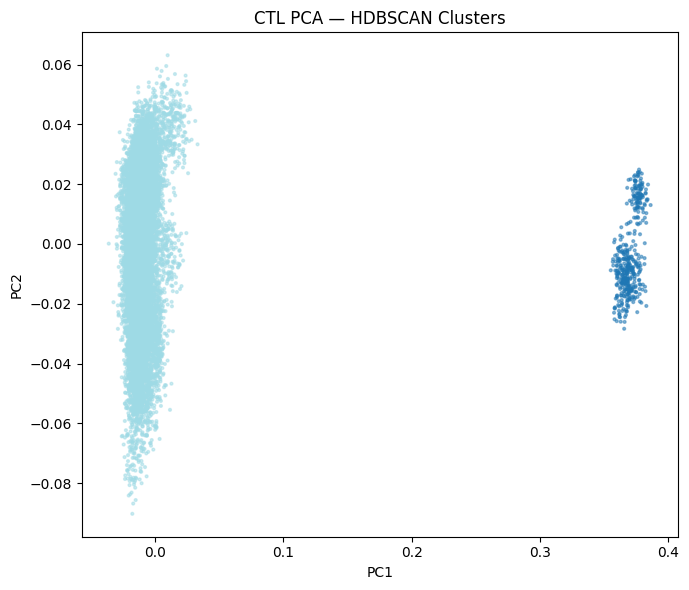

In [28]:
# ============================================================
# CTL clustering + occupancy + heatmap
# ============================================================

CTL_CLUSTER = run_cluster_panel_varlen(
    scores_flat=scores_flat_ctl,
    x_owner=X_owner_ctl,
    F=F,
    prefix="ctl",
    title_prefix="CTL",
    n_pcs=5,
    min_cluster_size=150,
    eps=0.8,
    min_samples=60,
)


## Activation Loop PCA with Active/Inactive Labels

The activation loop is one of the most important regulatory regions of protein kinases and often adopts conformations associated with active or inactive states.

This section analyzes activation loop conformational variability using PCA and compares the resulting structural space with active/inactive state labels to assess whether mutants preferentially sample functionally distinct loop conformations.

ACT atoms: 141
[TIMER] A-loop: aligning all trajectories on ACT fit: 5.077 s


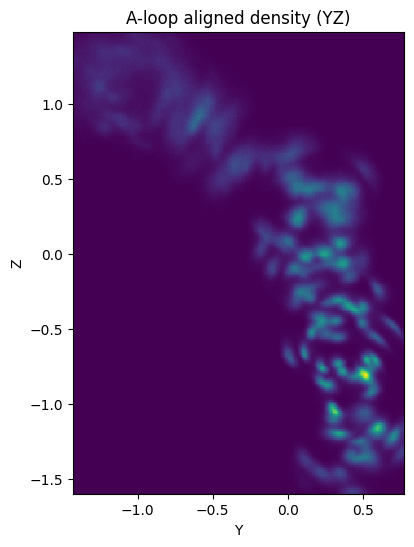

[TIMER] A-loop: cloud plot (YZ): 2.004 s
[TIMER] A-loop: vectorizing deviations + building P/X: 1.203 s
A-loop X shape: (16380, 423)


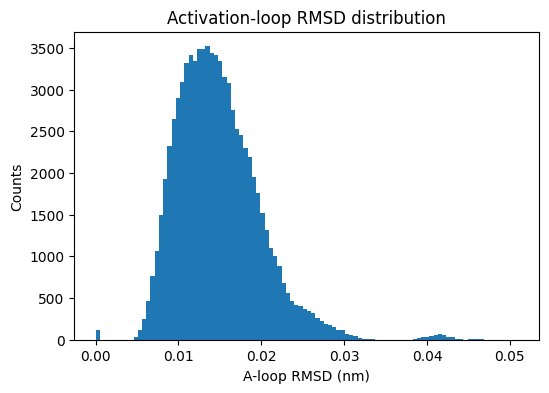

Threshold (nm): 0.25
Fraction inactive-like (overall): 0.0
[TIMER] A-loop: diagonalization: 0.046 s


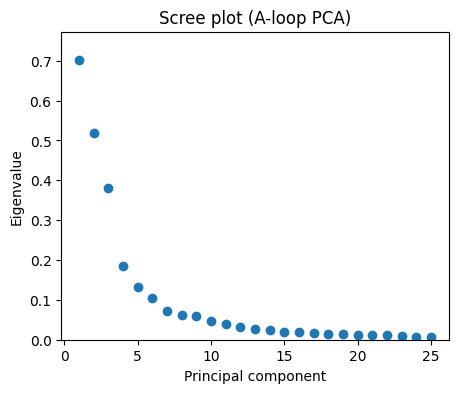

[TIMER] A-loop: projections on first 10 PCs (scaled RMSD-like): 0.014 s


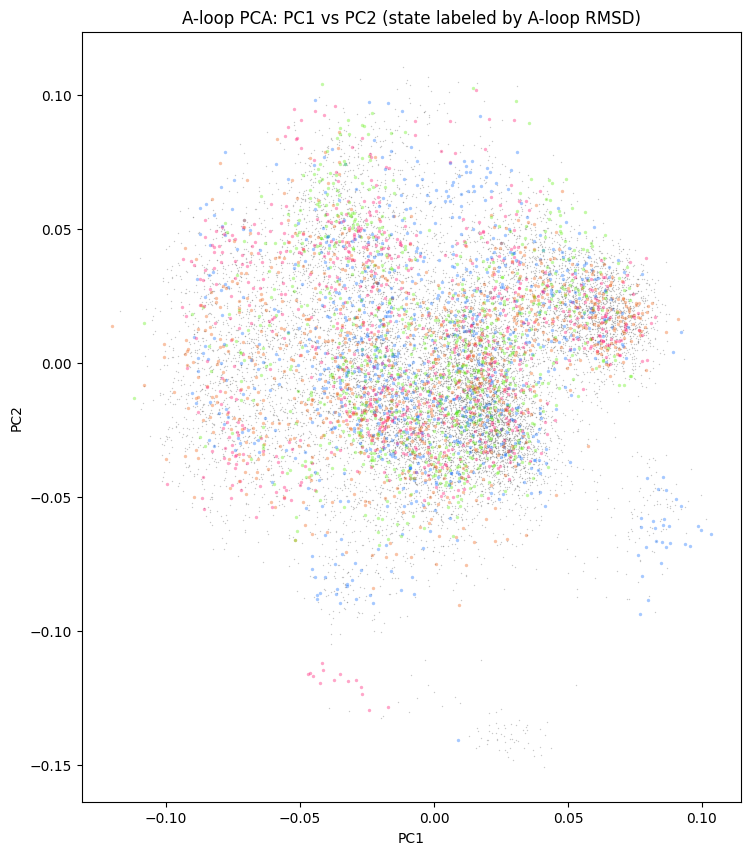

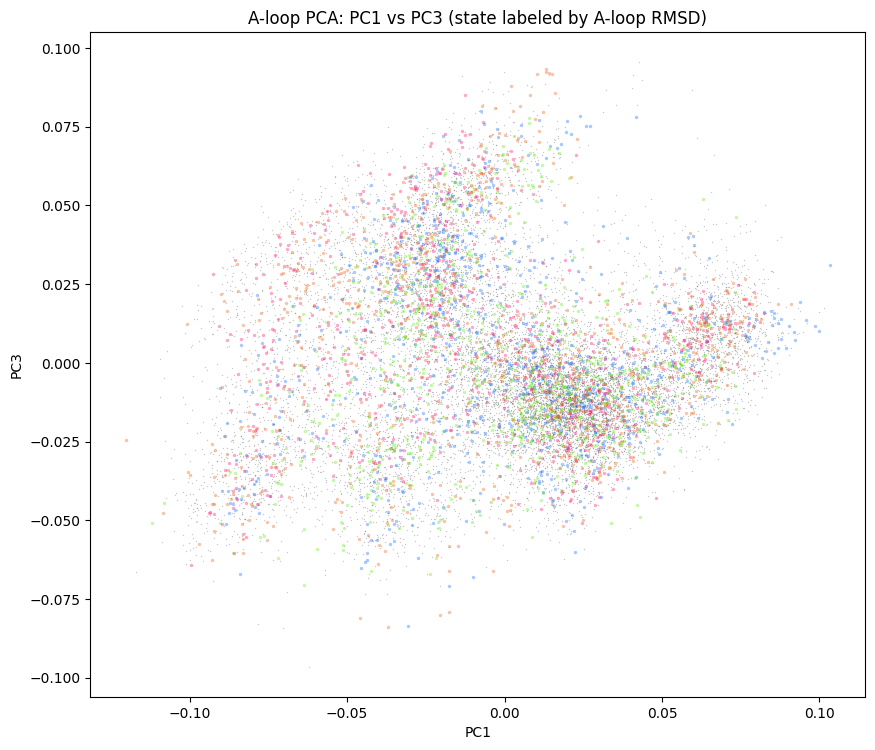

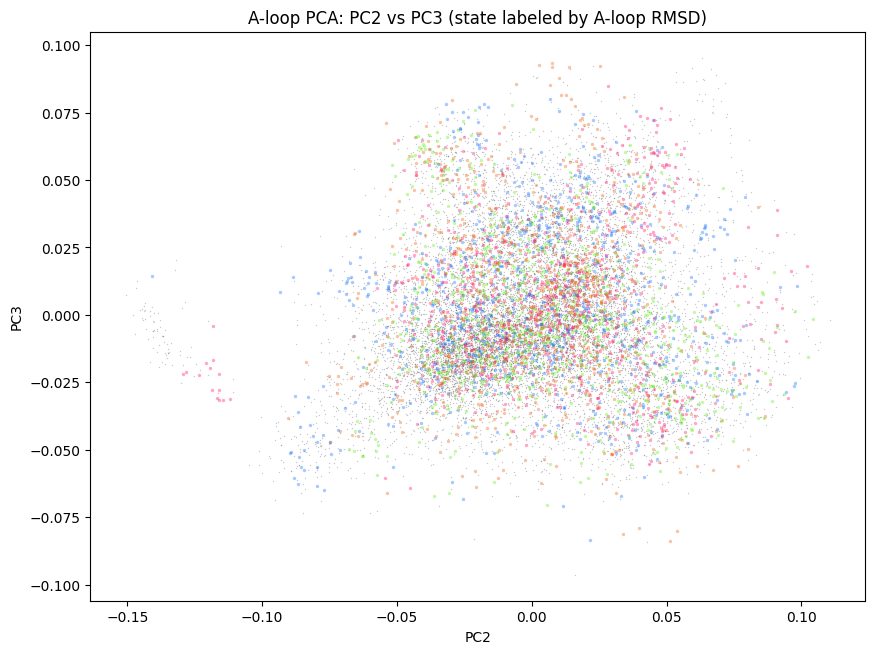

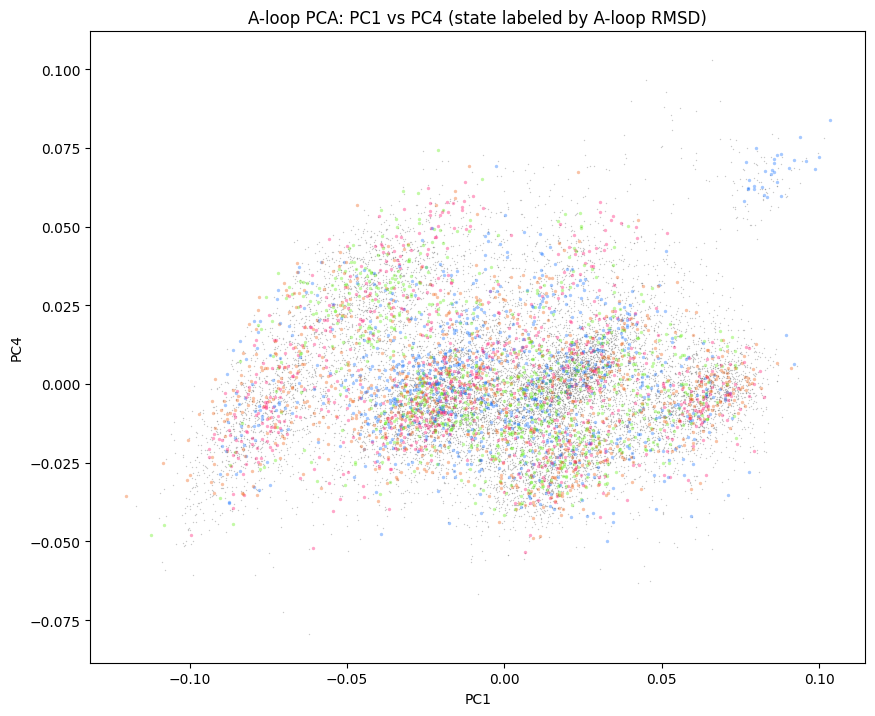

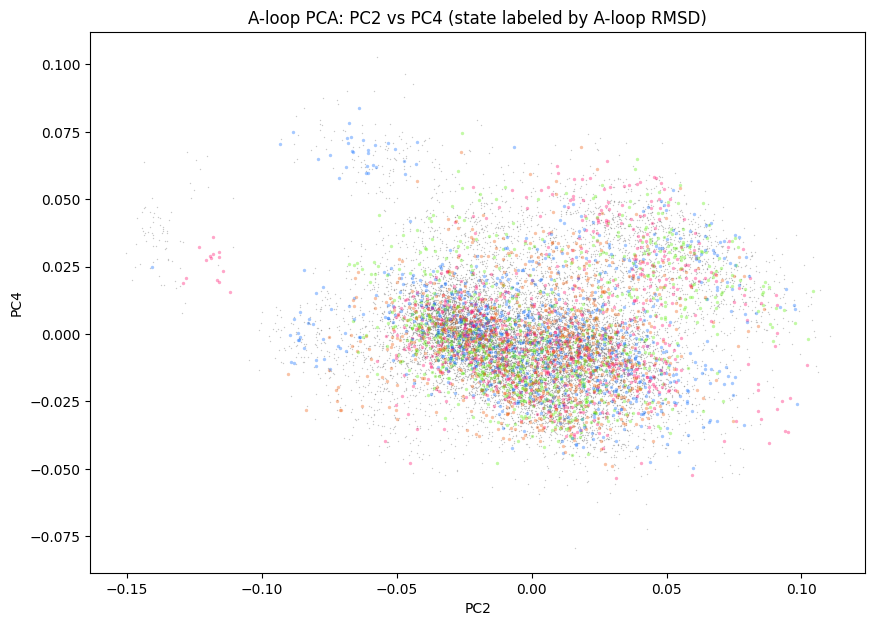

In [29]:
# ============================================================
# PCA on ACTIVATION LOOP ONLY (A-loop), with active/inactive labels
# ============================================================


eps = 1e-6

# -------------------------------
# 0) Define ACT atom mask (atom-level, on meta)
# ROS1 ACT: 2045–2070  => meta.resids = (2045-1933)..(2070-1933)
# -------------------------------
act_lo = 2045 - 1933
act_hi = 2070 - 1933

ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)

# # if you have exists_all (Option A style), apply it safely
# if "exists_all" in globals():
#     ACT = ACT & exists_all

ACT_idx = np.where(ACT)[0].astype(int)
print("ACT atoms:", int(ACT.sum()))

if ACT_idx.size < 10:
    raise ValueError("ACT selection too small — check residue range / numbering / exists_all.")

# For A-loop PCA, using ACT only
sele_act = ACT.copy()
fit_act  = ACT.copy()

# -------------------------------
# 1) Align each trajectory on ACT fit (local)
# traj_aligned is assumed to be list of xyz arrays: (T_i, natoms, 3)
# -------------------------------
ref_fit_act = ref_centered[fit_act]
ref_fit_act = ref_fit_act - ref_fit_act.mean(axis=0, keepdims=True)

def align_traj_to_ref_by_fit(xyz, fit_mask, ref_fit_centered):
    """
    xyz: (T, natoms, 3) for ONE trajectory on COMMON atoms
    returns aligned xyz: (T, natoms, 3)
    """
    xyz = xyz.copy().astype(np.float64)

    # center each frame on fit COM
    xyz -= xyz[:, fit_mask].mean(axis=1, keepdims=True)
    Xfit = xyz[:, fit_mask]  # (T, nfit, 3)

    # rotation per frame 
    M = np.einsum(
        "ij,tjk->tik",
        (ref_fit_centered.T / (3 * ref_fit_centered.shape[0])),
        Xfit
    )  # (T,3,3)

    U, S, Vt = np.linalg.svd(M)
    R = U @ Vt  # (T,3,3)

    xyz = xyz @ np.transpose(R, (0, 2, 1))
    return xyz.astype(np.float32)

with tim("A-loop: aligning all trajectories on ACT fit"):
    traj_act = [align_traj_to_ref_by_fit(xyz, fit_act, ref_fit_act) for xyz in traj_aligned]

# -------------------------------
# 2) Cloud plot (YZ) for ACT selection
# -------------------------------
with tim("A-loop: cloud plot (YZ)"):
    A = []
    for xyz in traj_act:
        a = xyz[:, sele_act, 1:].reshape((-1, 2)).astype(np.float32)  # YZ
        m = ~((np.abs(a[:,0]) < eps) & (np.abs(a[:,1]) < eps))
        A.append(a[m])
    A = np.vstack(A)

    y0, y1 = np.percentile(A[:,0], [1, 99])
    z0, z1 = np.percentile(A[:,1], [1, 99])

    plt.figure(figsize=(7,6))
    plt.hist2d(A[:,0], A[:,1], bins=256, range=[[y0,y1],[z0,z1]])
    plt.gca().set_aspect("equal")
    plt.title("A-loop aligned density (YZ)")
    plt.xlabel("Y"); plt.ylabel("Z")
    plt.show()

# -------------------------------
# 3) Vectorize deviations + split P/X per trajectory (variable length)
# -------------------------------
with tim("A-loop: vectorizing deviations + building P/X"):
    # global mean over ALL frames (ACT atoms only)
    all_frames = []
    for xyz in traj_act:
        all_frames.append(xyz[:, sele_act].reshape(xyz.shape[0], -1))
    all_frames = np.vstack(all_frames)
    mean_act = all_frames.mean(axis=0)  # (d,)
    d = mean_act.size

    P_list, X_list = [], []
    P_owner, X_owner = [], []
    P_state, X_state = [], []  # 0 active-like, 1 inactive-like
    aloop_rmsd_list = []       # store per-traj RMSD arrays for sanity

    thr = 0.25  # nm threshold (you can tune later)

    for ti, xyz in enumerate(traj_act):
        # --- A-loop RMSD per frame vs first frame (nm) ---
        act_xyz = xyz[:, ACT_idx, :]                   # (T, n_act, 3)
        ref0 = act_xyz[0]
        diff = act_xyz - ref0[None, :, :]
        rmsd_nm = np.sqrt((diff**2).sum(axis=(1,2)) / ACT_idx.size) / 10.0
        aloop_rmsd_list.append(rmsd_nm)

        # label state per frame
        state = (rmsd_nm > thr).astype(int)            # 0=active-like, 1=inactive-like

        # --- PCA dev vectors on ACT atoms ---
        dev = xyz[:, sele_act].reshape(xyz.shape[0], -1) - mean_act

        split_idx = int(0.8 * dev.shape[0])            # per-trajectory split
        P_i, X_i = dev[:split_idx], dev[split_idx:]
        sP, sX   = state[:split_idx], state[split_idx:]

        if P_i.shape[0]:
            P_list.append(P_i)
            P_owner.append(np.full(P_i.shape[0], ti, dtype=int))
            P_state.append(sP)
        if X_i.shape[0]:
            X_list.append(X_i)
            X_owner.append(np.full(X_i.shape[0], ti, dtype=int))
            X_state.append(sX)

    P = np.vstack(P_list) if len(P_list) else np.zeros((0, d))
    X = np.vstack(X_list) if len(X_list) else np.zeros((0, d))
    P_owner = np.concatenate(P_owner) if len(P_owner) else np.zeros((0,), dtype=int)
    X_owner = np.concatenate(X_owner) if len(X_owner) else np.zeros((0,), dtype=int)
    P_state = np.concatenate(P_state) if len(P_state) else np.zeros((0,), dtype=int)
    X_state = np.concatenate(X_state) if len(X_state) else np.zeros((0,), dtype=int)

print("A-loop X shape:", X.shape)

# quick sanity histogram of A-loop RMSD
plt.figure(figsize=(6,4))
plt.hist(np.concatenate(aloop_rmsd_list), bins=100)
plt.xlabel("A-loop RMSD (nm)")
plt.ylabel("Counts")
plt.title("Activation-loop RMSD distribution")
plt.show()

print("Threshold (nm):", thr)
print("Fraction inactive-like (overall):", float(np.mean(np.concatenate([(r>thr).astype(int) for r in aloop_rmsd_list]))))

# -------------------------------
# 4) PCA diagonalization (feature covariance)
# -------------------------------
with tim("A-loop: diagonalization"):
    C = X.T @ (X / len(X))
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

plt.figure(figsize=(5,4))
plt.scatter(np.arange(1,26), evals[:25])
plt.ylim((0, float(1.1 * evals[:25].max())))
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (A-loop PCA)")
plt.show()

# -------------------------------
# 5) Projections (scores) + your colored plotting style split by state
# -------------------------------
ncomponents = 10
scale = np.sqrt(mean_act.size)

with tim(f"A-loop: projections on first {ncomponents} PCs (scaled RMSD-like)"):
    pscores_flat = (P @ loadings[:, :ncomponents]) / scale
    scores_flat  = (X @ loadings[:, :ncomponents]) / scale

# per-trajectory colors (same for 3 replicas)
ntraj = len(F)
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(ntraj / len(traj_colors))))[:ntraj]

stride = 5
pairs = [(0,1),(0,2),(1,2),(0,3),(1,3)]  # like your block

for a, b in pairs:
    fig, ax = plt.subplots(figsize=(10,10))

    # ---- Early P (grey), split by state
    m0 = (P_state == 0)
    m1 = (P_state == 1)
    ax.scatter(pscores_flat[m0][::stride, a], pscores_flat[m0][::stride, b],
               c="#666", s=1, alpha=0.35, linewidths=0)
    ax.scatter(pscores_flat[m1][::stride, a], pscores_flat[m1][::stride, b],
               c="#ccc", s=1, alpha=0.35, linewidths=0)

    # ---- Production X (colored per trajectory), split by state
    for ti in range(ntraj):
        mt = (X_owner == ti)
        if not np.any(mt):
            continue
        Zi = scores_flat[mt]
        Si = X_state[mt]

        z0 = Zi[Si == 0]
        z1 = Zi[Si == 1]

        if z0.shape[0]:
            ax.scatter(z0[::stride, a], z0[::stride, b],
                       s=6, c=[traj_colors[ti]], alpha=0.35, linewidths=0)
        if z1.shape[0]:
            ax.scatter(z1[::stride, a], z1[::stride, b],
                       s=6, c=[traj_colors[ti]], alpha=0.35, linewidths=0)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"PC{a+1}")
    ax.set_ylabel(f"PC{b+1}")
    plt.title(f"A-loop PCA: PC{a+1} vs PC{b+1} (state labeled by A-loop RMSD)")
    plt.show()


## DFG χ1 Labeling

The DFG motif is a key structural determinant of kinase activation state. In particular, the side-chain orientation of the phenylalanine residue provides a useful geometric marker of conformational state.

This section assigns DFG χ1-based labels in order to relate simulation frames to known kinase structural states and to compare how different mutants populate these conformations.

[TIMER] DFG χ1 (REAL) per-trajectory computation: 114.867 s


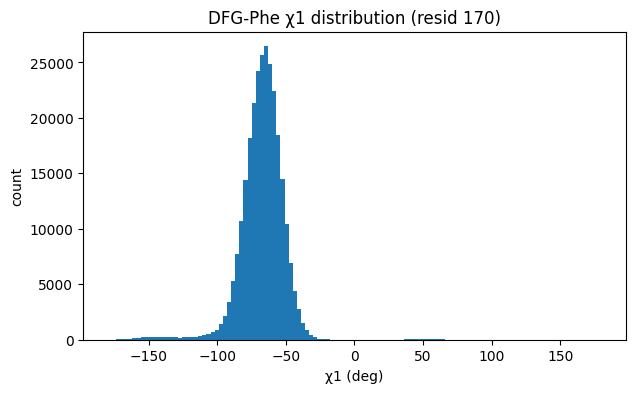

DFG χ1 threshold (deg): -66.2317886352539
Overall fraction state=1: 0.4999981906150823
[DFG BRIDGE] DFG_state shape: (117, 696) | mean state=1: 0.5230007859318204
dfg_flat_P shape: (65052,) matches pscores_flat_actout: 65052
dfg_flat_X shape: (16380,) matches scores_flat_actout : 16380


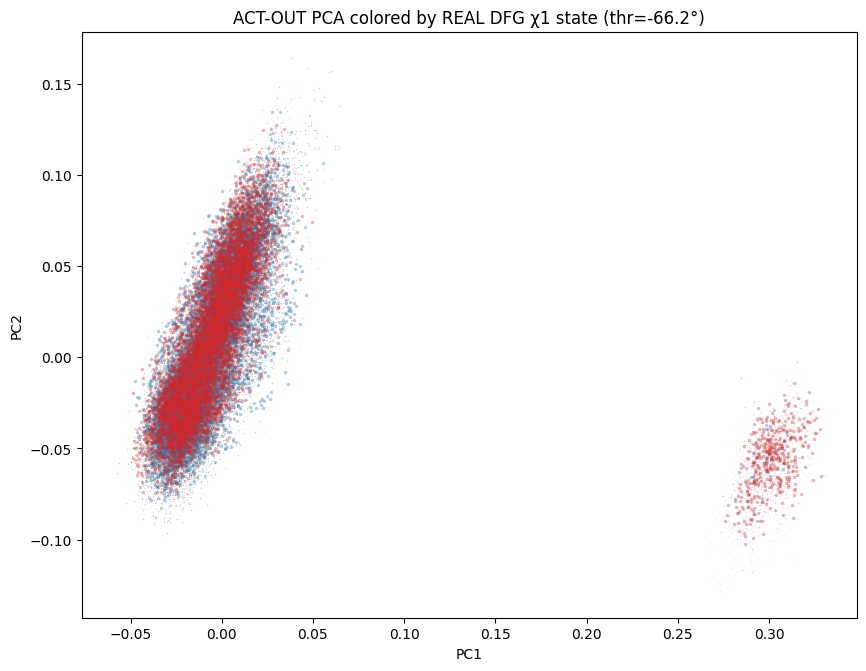

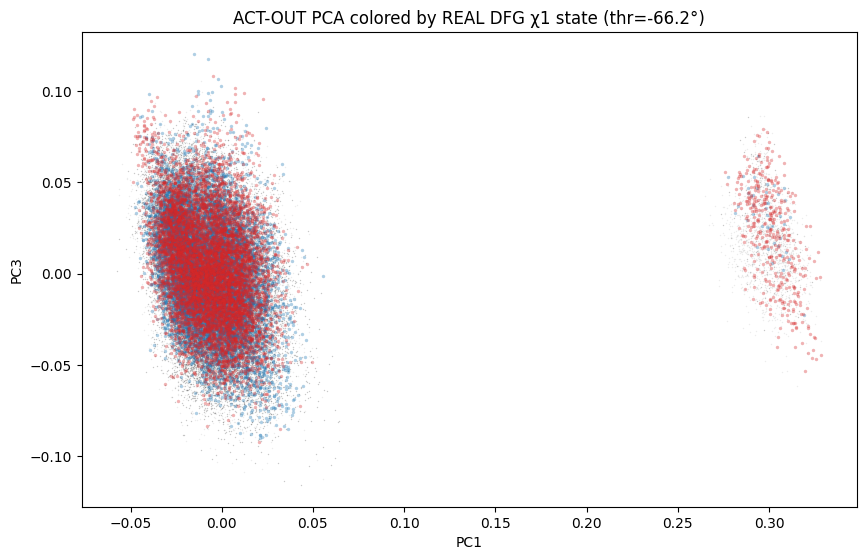

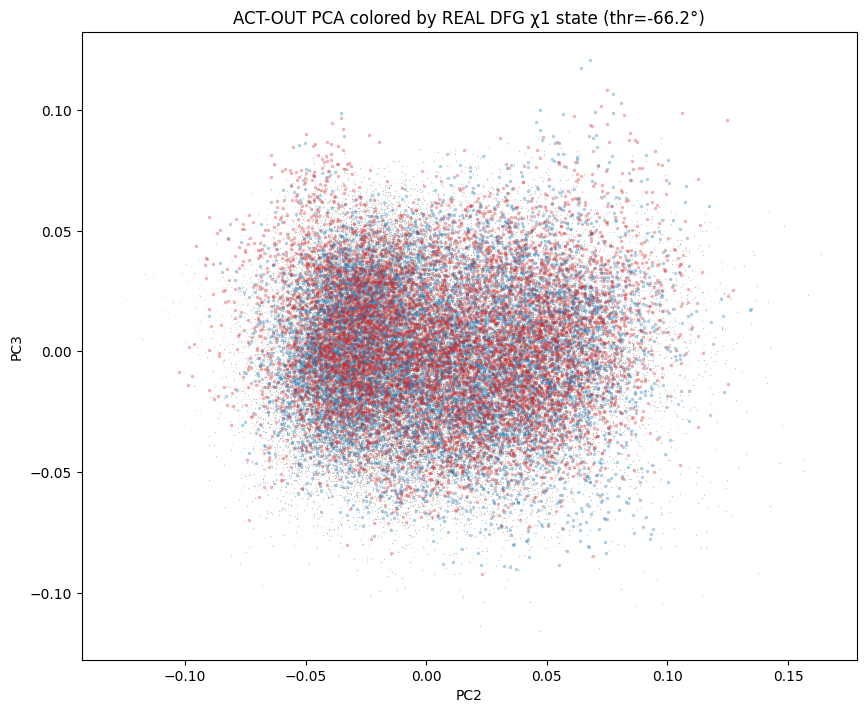

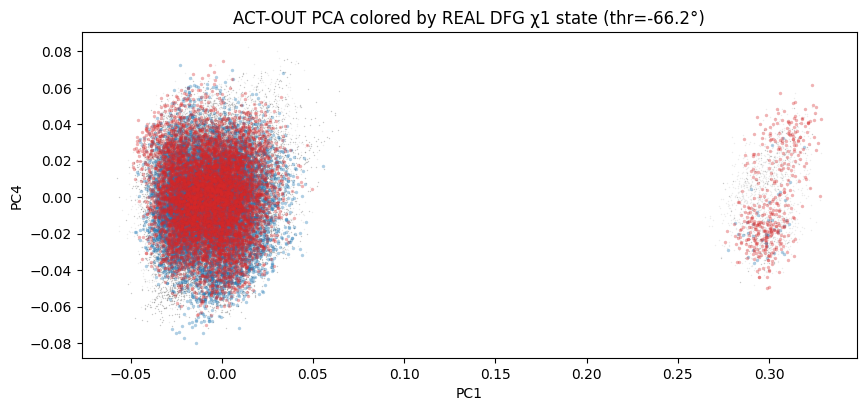

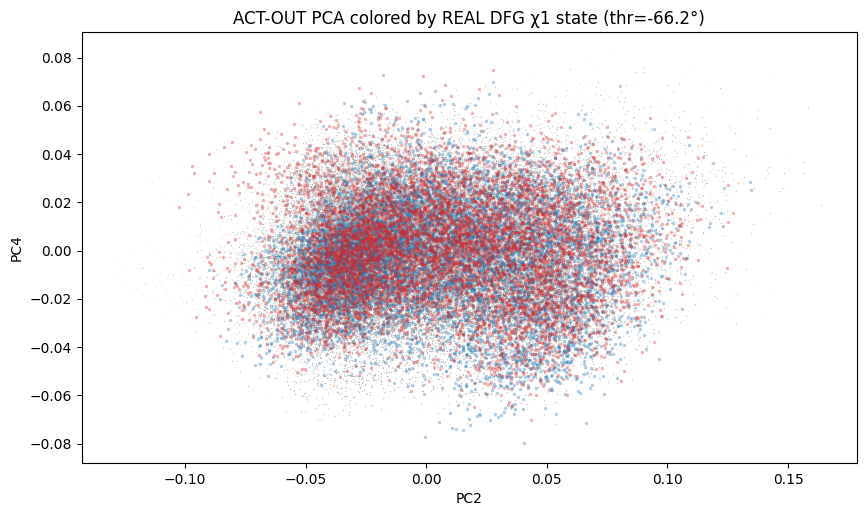

In [30]:
# ============================================================
# DFG χ1 labeling (N-CA-CB-CG dihedral)
# ============================================================

# --------- SETTINGS ----------
DFG_F = 170   # DFG Phe residue ID in meta.resids numbering (NOT +1933)
use_median_threshold = True  # simple first pass
manual_thr_deg = None        # set e.g. 0.0 if you want manual; otherwise keep None

# --------- HELPERS ----------
def get_atom_indices_for_resid(u, resid, names=("N", "CA", "CB", "CG")):
    idxs = []
    for nm in names:
        ag = u.select_atoms(f"protein and resid {resid} and name {nm}")
        if len(ag) != 1:
            raise ValueError(
                f"[DFG χ1] Could not uniquely select resid {resid} atom {nm}. "
                f"Found {len(ag)} atoms. Check numbering/topology."
            )
        idxs.append(int(ag.indices[0]))
    return idxs

def compute_chi1_deg_for_traj(pdb, xtc, resid):
    u = mda.Universe(pdb, xtc)
    iN, iCA, iCB, iCG = get_atom_indices_for_resid(u, resid)

    n_local = u.trajectory.n_frames
    coords_N  = np.empty((n_local, 3), dtype=np.float32)
    coords_CA = np.empty((n_local, 3), dtype=np.float32)
    coords_CB = np.empty((n_local, 3), dtype=np.float32)
    coords_CG = np.empty((n_local, 3), dtype=np.float32)

    for fi, ts in enumerate(u.trajectory):
        coords_N[fi]  = u.atoms[iN].position
        coords_CA[fi] = u.atoms[iCA].position
        coords_CB[fi] = u.atoms[iCB].position
        coords_CG[fi] = u.atoms[iCG].position

    chi1 = calc_dihedrals(coords_N, coords_CA, coords_CB, coords_CG)  # radians
    return np.degrees(chi1).astype(np.float32)

# --------- 1) COMPUTE χ1 PER TRAJECTORY (variable length) ----------
chi1_deg_list = []
with tim("DFG χ1 (REAL) per-trajectory computation"):
    for d in F:
        pdb = f"{d}/md-prot.pdb"
        xtc = f"{d}/md-prot.xtc"
        chi1_deg_list.append(compute_chi1_deg_for_traj(pdb, xtc, DFG_F))

# --------- 2) HISTOGRAM (all frames pooled) ----------
all_vals = np.concatenate([v[np.isfinite(v)] for v in chi1_deg_list])
plt.figure(figsize=(7,4))
plt.hist(all_vals, bins=120)
plt.title(f"DFG-Phe χ1 distribution (resid {DFG_F})")
plt.xlabel("χ1 (deg)")
plt.ylabel("count")
plt.show()

# --------- 3) THRESHOLD -> 0/1 STATE ----------
if manual_thr_deg is not None:
    thr = float(manual_thr_deg)
else:
    # simple default: median (works even if distribution is bimodal; you can later set manual_thr_deg)
    thr = float(np.nanmedian(all_vals))

dfg_state_list = [(v > thr).astype(int) for v in chi1_deg_list]

print("DFG χ1 threshold (deg):", thr)
print("Overall fraction state=1:", float(np.mean(np.concatenate(dfg_state_list))))

# ============================================================
# BRIDGE: Convert full-frame DFG labels -> subsampled DFG_state
# Paste this RIGHT AFTER your DFG χ1 labeling cell (dfg_state_list)
# ============================================================


# DFG_state will match the SAME subsampling used everywhere else:
# - frame_idx_list[ti] holds the original frame numbers you kept
# - nframes_sub is how many subsampled frames you use per trajectory
DFG_state = np.zeros((len(F), nframes_sub), dtype=np.int8)

for ti in range(len(F)):
    fi = frame_idx_list[ti]  # original frame indices used elsewhere (length nframes_sub)

    full = np.asarray(dfg_state_list[ti], dtype=np.int8)  # full-frame labels

    if fi.max() >= full.size:
        raise ValueError(
            f"[DFG BRIDGE] Traj {ti} ({F[ti]}): max(fi)={int(fi.max())} "
            f"but dfg_state_list length={full.size}. "
            "This means dfg_state_list was not computed on full frames."
        )

    DFG_state[ti] = full[fi][:nframes_sub]

print("[DFG BRIDGE] DFG_state shape:", DFG_state.shape,
      "| mean state=1:", float(DFG_state.mean()))

# ============================================================
# OPTIONAL A) COLOR YOUR ACT-OUT PCA (the one you pasted)
# Requires these to exist:
#   pscores_flat_actout, scores_flat_actout, P_owner_actout, X_owner_actout
# and ALSO requires:
#   traj_actout (list of aligned xyz per traj)  OR we can infer n_local from chi1 list
# ============================================================

if all(k in globals() for k in ["pscores_flat_actout", "scores_flat_actout", "P_owner_actout", "X_owner_actout"]):
    # Build flattened DFG labels that match the flattened ACT-OUT PCA rows
    dfg_flat_P = []
    dfg_flat_X = []

    for ti in range(len(F)):
        # how many rows in ACT-OUT PCA belong to this trajectory?
        nP = int(np.sum(P_owner_actout == ti))
        nX = int(np.sum(X_owner_actout == ti))

        # local frames (from DFG χ1 computation)
        n_local = int(len(dfg_state_list[ti]))
        split_idx = int(0.8 * n_local)  # MUST match your ACT-OUT PCA split rule

        # take exactly as many labels as PCA rows for that traj
        dfgP = dfg_state_list[ti][:split_idx][:nP]
        dfgX = dfg_state_list[ti][split_idx:split_idx + nX]

        if len(dfgP) != nP or len(dfgX) != nX:
            print(f"[WARN] traj {ti} label count mismatch: want P={nP},X={nX} got P={len(dfgP)},X={len(dfgX)}")

        dfg_flat_P.append(dfgP)
        dfg_flat_X.append(dfgX)

    dfg_flat_P = np.concatenate(dfg_flat_P) if len(dfg_flat_P) else np.array([], dtype=int)
    dfg_flat_X = np.concatenate(dfg_flat_X) if len(dfg_flat_X) else np.array([], dtype=int)

    print("dfg_flat_P shape:", dfg_flat_P.shape, "matches pscores_flat_actout:", pscores_flat_actout.shape[0])
    print("dfg_flat_X shape:", dfg_flat_X.shape, "matches scores_flat_actout :", scores_flat_actout.shape[0])

    # --- PCA plots colored by DFG state (ACT-OUT PCA) ---
    pairs = [(0,1),(0,2),(1,2),(0,3),(1,3)]
    for a, b in pairs:
        fig, ax = plt.subplots(figsize=(10,10))

        # early P: grey shades by DFG state
        ax.scatter(pscores_flat_actout[dfg_flat_P==0, a],
                   pscores_flat_actout[dfg_flat_P==0, b],
                   c="#666", s=1, alpha=0.35, linewidths=0)
        ax.scatter(pscores_flat_actout[dfg_flat_P==1, a],
                   pscores_flat_actout[dfg_flat_P==1, b],
                   c="#ccc", s=1, alpha=0.35, linewidths=0)

        # production X: keep it simple (state colors)
        ax.scatter(scores_flat_actout[dfg_flat_X==0, a],
                   scores_flat_actout[dfg_flat_X==0, b],
                   c="#1f77b4", s=6, alpha=0.35, linewidths=0)
        ax.scatter(scores_flat_actout[dfg_flat_X==1, a],
                   scores_flat_actout[dfg_flat_X==1, b],
                   c="#d62728", s=6, alpha=0.35, linewidths=0)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(f"PC{a+1}")
        ax.set_ylabel(f"PC{b+1}")
        ax.set_title(f"ACT-OUT PCA colored by REAL DFG χ1 state (thr={thr:.1f}°)")
        plt.show()

else:
    print("ACT-OUT PCA variables not found — computed only chi1_deg_list + dfg_state_list.")

## Whole-Kinase PCA after Alignment to the CTL (Activation Loop Excluded)

To emphasize inter-lobe motions, trajectories were aligned to the C-terminal lobe (CTL) before performing PCA on the kinase domain with the activation loop excluded.

This representation reduces contributions from global rotation and highly flexible loop motion, allowing clearer visualization of relative movements between the kinase lobes.

In [31]:
# ============================================================
# BOOTSTRAP CELL: ensures tim, selection, F, Multiverse exist
# ============================================================

# ---- 0) timer fallback ----
try:
    tim
except NameError:
    import timer
    tim = timer.Timer()

eps = 1e-6

# ---- 1) selection fallback ----
if "selection" not in globals():
    selection = "protein and name N CA C O and not element H"
    print("[BOOT] selection was missing -> set default backbone selection")

# ---- 2) F fallback ----
if "F" not in globals():
    mutants = sorted([d for d in os.listdir('.') if os.path.isdir(d) and d not in ('__pycache__',)])
    nrep = 3
    F = [f'{mut}/Simulation_{run}' for mut in mutants for run in (1, 2, 3)]
    print("[BOOT] F was missing -> rebuilt F:", len(F))
else:
    print("[BOOT] F exists:", len(F))

# ---- 3) nrep fallback ----
if "nrep" not in globals():
    nrep = 3
    print("[BOOT] nrep was missing -> set nrep=3")

# ---- 4) Multiverse build ----
def xtc2array(d, selection='all', out=None, pbc=None, frame_selection=None):
    u = mda.Universe(f'{d}/md-prot.pdb')
    ag = u.select_atoms(selection).ix

    m = molly.XTCReader(f'{d}/md-prot.xtc')
    nframes = len(m.read_frames(atom_selection=[], frame_selection=frame_selection))
    m.home()

    if out is None:
        out = np.zeros((nframes, len(ag), 3), dtype=np.float32)
    if pbc is None:
        pbc = np.empty((nframes, 3, 3), dtype=np.float32)

    m.read_into_array(out, pbc, atom_selection=[int(i) for i in ag], frame_selection=frame_selection)
    print(d, "selected:", len(ag), "nframes:", nframes)
    return out, pbc

if "Multiverse" not in globals():
    frame_selection = globals().get("frame_selection", None)

    with tim("[BOOT] Reading first sim to size Multiverse"):
        first, box = xtc2array(F[0], selection, frame_selection=frame_selection)

    with tim("[BOOT] Allocating Multiverse"):
        Multiverse = np.empty((len(F), *first.shape), dtype=np.float32)
        pbc = np.empty((len(F), *box.shape), dtype=np.float32)
        Multiverse[0] = first
        pbc[0] = box

    with tim("[BOOT] Reading remaining sims into Multiverse"):
        for i, f in enumerate(F[1:], 1):
            xtc2array(f, selection, out=Multiverse[i], pbc=pbc[i], frame_selection=frame_selection)

    pbc = np.array(pbc).transpose((0, 1, 3, 2))
    print("[BOOT] Multiverse shape:", Multiverse.shape)
else:
    print("[BOOT] Multiverse exists:", Multiverse.shape)

# ---- 5) sanity check ----
if "Multiverse" not in globals():
    raise RuntimeError("BOOT failed: Multiverse is STILL missing (likely an error happened during reading).")

[BOOT] F exists: 117
C2060G/Simulation_1 selected: 1627 nframes: 4001
[TIMER] [BOOT] Reading first sim to size Multiverse: 0.935 s
[TIMER] [BOOT] Allocating Multiverse: 0.031 s
C2060G/Simulation_2 selected: 1627 nframes: 4001
C2060G/Simulation_3 selected: 1627 nframes: 4000
D1988N/Simulation_1 selected: 1628 nframes: 4001
D1988N/Simulation_2 selected: 1628 nframes: 4000
D1988N/Simulation_3 selected: 1628 nframes: 4001
D2033N/Simulation_1 selected: 1628 nframes: 4001
D2033N/Simulation_2 selected: 1628 nframes: 4000
D2033N/Simulation_3 selected: 1628 nframes: 4001
D2113G/Simulation_1 selected: 1630 nframes: 4001
D2113G/Simulation_2 selected: 1630 nframes: 4001
D2113G/Simulation_3 selected: 1630 nframes: 4000
D2113N/Simulation_1 selected: 1630 nframes: 4001
D2113N/Simulation_2 selected: 1630 nframes: 4001
D2113N/Simulation_3 selected: 1630 nframes: 4000
E1935G/Simulation_1 selected: 1630 nframes: 4001
E1935G/Simulation_2 selected: 1630 nframes: 696
E1935G/Simulation_3 selected: 1630 nfram

In [32]:
# ============================================================
# - patches NaN/Inf frames
# - patches absurd huge-but-finite coordinate frames
# ============================================================

eps = 1e-6
nmut, nframes, natoms, _ = Multiverse.shape
print(" Multiverse shape:", Multiverse.shape)

# ----------------------------
# (A) Patch non-finite frames
# ----------------------------
with tim("Scan Multiverse for non-finite frames"):
    frame_ok = np.isfinite(Multiverse).all(axis=(2, 3))  # (nmut, nframes)
    bad = ~frame_ok
    nbad = int(bad.sum())
    print("Total non-finite frames:", nbad)

    if nbad > 0:
        bad_per_traj = bad.sum(axis=1)
        worst = np.argsort(bad_per_traj)[::-1][:10]
        print("Worst trajectories:")
        for ti in worst:
            if bad_per_traj[ti] > 0:
                print("  traj", int(ti), "bad_frames", int(bad_per_traj[ti]), "name", F[int(ti)])

if nbad > 0:
    with tim("[Patch non-finite frames (copy previous good)"):
        for ti in range(nmut):
            if not bad[ti].any():
                continue

            good_idx = np.where(frame_ok[ti])[0]
            if good_idx.size == 0:
                raise ValueError(f"Trajectory {ti} ({F[ti]}) has NO finite frames at all.")

            first_good = int(good_idx[0])
            if first_good > 0:
                Multiverse[ti, :first_good] = Multiverse[ti, first_good]

            for fi in range(1, nframes):
                if not frame_ok[ti, fi]:
                    Multiverse[ti, fi] = Multiverse[ti, fi - 1]
                    frame_ok[ti, fi] = True

    nbad2 = int((~np.isfinite(Multiverse).all(axis=(2, 3))).sum())
    print(" Bad frames remaining:", nbad2)

# ---------------------------------------------
# (B) Patch huge-but-finite coordinate blowups
#     Use either:
#       - your explicit bad_map (best, since you already found them)
#       - OR automatic threshold scan
# ---------------------------------------------

# (B1) Your explicit outlier list (recommended)
bad_map = {
    55:  [2906, 2818, 2796, 2840, 2752, 2708, 2664, 2577, 2774, 2512, 2051],  # G2048A_NC/Simulation_2
    110: [2828, 2806, 2683, 2743, 2723, 2538, 2495, 2702, 2410],              # V2089M/Simulation_3
}

with tim(" Patch known extreme frames (copy previous frame)"):
    for ti, frames in bad_map.items():
        if ti >= nmut:
            print("  [skip] traj index out of range:", ti)
            continue
        frames = sorted({f for f in frames if 0 <= f < nframes})
        if not frames:
            continue

        print(f"  traj {ti} ({F[ti]}): patching {len(frames)} frames")
        for fi in frames:
            if fi == 0:
                Multiverse[ti, fi] = Multiverse[ti, 1]
            else:
                Multiverse[ti, fi] = Multiverse[ti, fi - 1]

# (B2) Optional: automatic scan+patch by threshold (OFF by default)
AUTO_PATCH_HUGE = False
HUGE_THR = 1e5  # Å

if AUTO_PATCH_HUGE:
    with tim("Auto patch huge-value frames (copy previous)"):
        A = np.abs(Multiverse)
        frame_ok2 = np.isfinite(Multiverse).all(axis=(2,3)) & (A.max(axis=(2,3)) < HUGE_THR)
        bad2 = ~frame_ok2
        print("[Bad frames (huge or nonfinite):", int(bad2.sum()))

        for ti in range(nmut):
            if not bad2[ti].any():
                continue
            good_idx = np.where(frame_ok2[ti])[0]
            if good_idx.size == 0:
                raise ValueError(f"Trajectory {ti} ({F[ti]}) has no usable frames at all.")
            first_good = int(good_idx[0])
            if first_good > 0:
                Multiverse[ti, :first_good] = Multiverse[ti, first_good]
            for fi in range(1, nframes):
                if not frame_ok2[ti, fi]:
                    Multiverse[ti, fi] = Multiverse[ti, fi-1]
                    frame_ok2[ti, fi] = True

print(" Done. Max abs coord now:", float(np.abs(Multiverse).max()))

 Multiverse shape: (117, 4001, 1627, 3)
Total non-finite frames: 0
[TIMER] Scan Multiverse for non-finite frames: 1.382 s
  traj 55 (G2048A_NC/Simulation_2): patching 11 frames
  traj 110 (V2089M/Simulation_3): patching 9 frames
[TIMER]  Patch known extreme frames (copy previous frame): 0.001 s
 Done. Max abs coord now: 10.136000633239746


Multiverse: (117, 4001, 1627, 3)
[TIMER] Computing exists_all: 18.618 s
FIT atoms: 616
SELE atoms: 984
[TIMER] Alignment on FIT (robust): 47.158 s
Multiverse_ctl finite: True
[TIMER] Vectorizing deviations for PCA: 44.032 s
X shape: (468000, 2952) | X finite: True
[TIMER] PCA diagonalization: 55.019 s


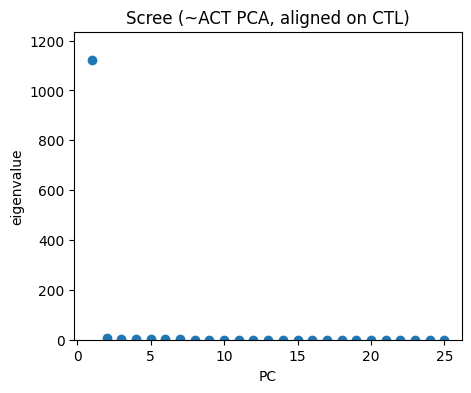

scores: (117, 4000, 10) pscores: (117, 1, 10)


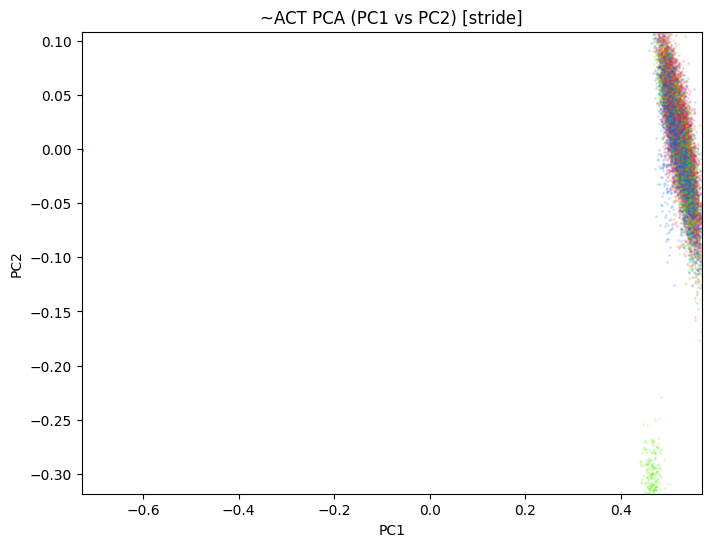

In [33]:
# ============================================================
# PCA on whole kinase (~ACT) after fitting to CTL (~ACT)
# - alignment on CTL & ~ACT (fit_mask)
# - PCA on BODY & BB & ~ACT (sele_mask)
# - includes a PCA plot that DOES NOT squish PC2
# ============================================================


eps = 1e-6
split = 1
ncomponents = 10

# --------- Preconditions ----------
need = ["Multiverse", "F", "selection", "colors", "tim", "nrep"]
for v in need:
    if v not in globals():
        raise NameError(f"{v} missing. Run BOOT + CLEANUP first.")

nmut, nframes, natoms, ndim = Multiverse.shape
print("Multiverse:", Multiverse.shape)

# --------- meta must match natoms ----------
meta = mda.Universe(f"{F[0]}/md-prot.pdb").select_atoms(selection)
if len(meta) != natoms:
    raise ValueError(f"meta atoms {len(meta)} != natoms {natoms}. Selection mismatch.")

# --------- masks (natoms-long) ----------
BB   = np.isin(meta.names, ["N", "CA", "C", "O"])
BODY = np.isin(meta.resids, np.arange(6, 278))

act_lo = 2045 - 1933
act_hi = 2070 - 1933
ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)

ctl_lo = 2031 - 1933
ctl_hi = 2225 - 1933
CTL_res = (meta.resids >= ctl_lo) & (meta.resids <= ctl_hi)

# exists_all: (natoms,) — atom must exist (non-zero) in all frames in all trajs
with tim("Computing exists_all"):
    valid_sys_atom = np.any(np.linalg.norm(Multiverse, axis=3) > eps, axis=1)  # (nmut,natoms)
    exists_all = np.all(valid_sys_atom, axis=0)                                # (natoms,)

BB      = BB & exists_all
BODY    = BODY & exists_all
ACT     = ACT & exists_all
CTL_res = CTL_res & exists_all

fit_mask  = (BB & BODY & CTL_res & (~ACT))          # FIT for alignment
sele_mask = (BB & BODY & (~ACT))                    # PCA selection

print("FIT atoms:", int(fit_mask.sum()))
print("SELE atoms:", int(sele_mask.sum()))

if fit_mask.sum() < 50:
    raise ValueError("FIT mask too small — check CTL/ACT ranges or selection.")
if sele_mask.sum() < 50:
    raise ValueError("SELE mask too small — check ACT range or selection.")

# --------- Alignment (robust) ----------
with tim("Alignment on FIT (robust)"):
    ref = Multiverse[0, 0].astype(np.float64)
    ref_fit = ref[fit_mask]
    ref_fit -= ref_fit.mean(axis=0, keepdims=True)

    means_fit = Multiverse[:, :, fit_mask].mean(axis=2, keepdims=True)   # (nmut,nframes,1,3)
    Xfit = (Multiverse[:, :, fit_mask] - means_fit).astype(np.float64)   # (nmut,nframes,nfit,3)

    M = np.einsum("ij,tfjk->tfik", (ref_fit.T / (3.0 * ref_fit.shape[0])), Xfit)  # (nmut,nframes,3,3)

    badM = ~np.isfinite(M).all(axis=(2,3))
    if badM.any():
        print("[WARN] Bad M frames:", int(badM.sum()), "-> identity rotation there")
        M[badM] = np.eye(3, dtype=np.float64)

    U, S, Vt = np.linalg.svd(M)
    R = (U @ Vt).astype(np.float32)

    Multiverse_ctl = (Multiverse - means_fit) @ np.transpose(R, (0,1,3,2))

print("Multiverse_ctl finite:", bool(np.isfinite(Multiverse_ctl).all()))

# --------- Vectorize deviations for PCA ----------
with tim("Vectorizing deviations for PCA"):
    Ssel = Multiverse_ctl[:, :, sele_mask, :].astype(np.float64)         # (nmut,nframes,nsel,3)
    mean = Ssel.mean(axis=(0, 1))                                        # (nsel,3)
    dev  = Ssel - mean                                                   # (nmut,nframes,nsel,3)

    P, X = np.split(dev, [split], axis=1)
    P = P.reshape((-1, mean.size))
    X = X.reshape((-1, mean.size))

print("X shape:", X.shape, "| X finite:", bool(np.isfinite(X).all()))

# --------- PCA diagonalization ----------
with tim("PCA diagonalization"):
    C = (X.T @ (X / len(X))).astype(np.float64)
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

plt.figure(figsize=(5,4))
plt.scatter(np.arange(1,26), evals[:25])
plt.ylim((0, float(1.1 * np.max(evals[:25]))))
plt.title("Scree (~ACT PCA, aligned on CTL)")
plt.xlabel("PC"); plt.ylabel("eigenvalue")
plt.show()

# --------- Scores ----------
scale = np.sqrt(mean.size)
scores  = (X @ loadings[:, :ncomponents]).reshape((nmut, -1, ncomponents)) / scale
pscores = (P @ loadings[:, :ncomponents]).reshape((nmut, -1, ncomponents)) / scale
print("scores:", scores.shape, "pscores:", pscores.shape)

# --------- PCA plot FIX (no equal aspect; percentile y-limits) ----------
traj_colors = np.repeat(np.array(colors), nrep, axis=0)
traj_colors = np.tile(traj_colors, int(np.ceil(nmut / len(traj_colors))))[:nmut]

stride_plot = 20

pc1 = scores[:, ::stride_plot, 0].reshape(-1)
pc2 = scores[:, ::stride_plot, 1].reshape(-1)

# robust limits (ignore extreme few points)
x0, x1 = np.percentile(pc1[np.isfinite(pc1)], [0.5, 99.5])
y0, y1 = np.percentile(pc2[np.isfinite(pc2)], [0.5, 99.5])

fig, ax = plt.subplots(figsize=(8, 6))  # not super wide (prevents “flat line” look)

for i in range(nmut):
    ax.scatter(scores[i, ::stride_plot, 0], scores[i, ::stride_plot, 1],
               s=3, c=[traj_colors[i]], alpha=0.25, linewidths=0)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("~ACT PCA (PC1 vs PC2) [stride]")

# KEY FIXES:
ax.set_aspect("auto")        
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
plt.show()

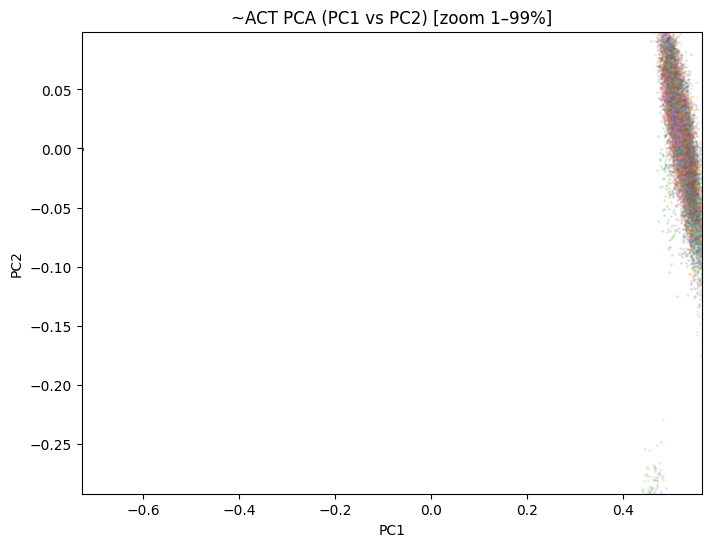

In [34]:
pc1s = scores[:, ::20, 0].reshape(-1)
pc2s = scores[:, ::20, 1].reshape(-1)

x0, x1 = np.percentile(pc1s[np.isfinite(pc1s)], [1, 99])
y0, y1 = np.percentile(pc2s[np.isfinite(pc2s)], [1, 99])

fig, ax = plt.subplots(figsize=(8,6))
for i in range(nmut):
    ax.scatter(scores[i, ::20, 0], scores[i, ::20, 1], s=3, alpha=0.25, linewidths=0)

ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_aspect("auto")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("~ACT PCA (PC1 vs PC2) [zoom 1–99%]")
plt.show()

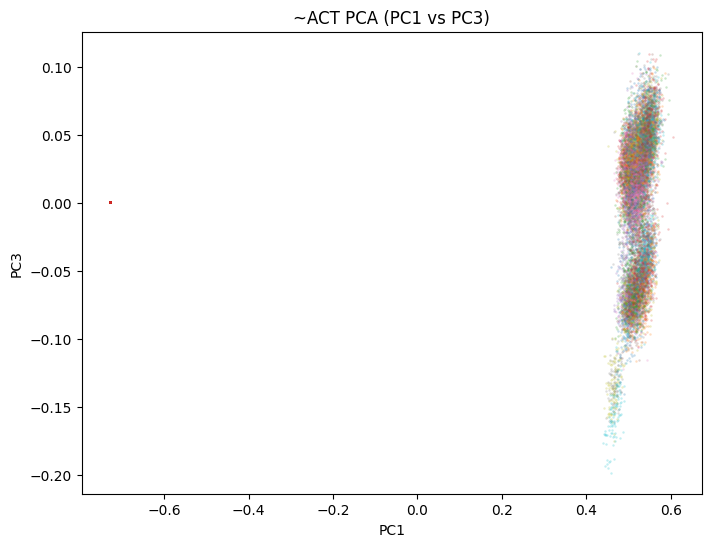

In [35]:
fig, ax = plt.subplots(figsize=(8,6))
for i in range(nmut):
    ax.scatter(scores[i, ::20, 0], scores[i, ::20, 2], s=3, alpha=0.25, linewidths=0)
ax.set_aspect("auto")
ax.set_xlabel("PC1"); ax.set_ylabel("PC3")
ax.set_title("~ACT PCA (PC1 vs PC3)")
plt.show()

### Save CTL-fit PCA Outputs

The PCA scores from the CTL-aligned whole-kinase analysis were saved explicitly for downstream clustering and comparison with the other structural representations.

In [36]:
scores_actout_ctlfit = scores.copy()
pscores_actout_ctlfit = pscores.copy()
print("Saved scores_actout_ctlfit:", scores_actout_ctlfit.shape)

Saved scores_actout_ctlfit: (117, 4000, 10)


ACT-OUT (fit to CTL) HDBSCAN clusters: 5
ACT-OUT (fit to CTL) HDBSCAN noise fraction: 0.00455982905982906
ACT-OUT (fit to CTL) DBSCAN clusters: 4
ACT-OUT (fit to CTL) DBSCAN noise fraction: 0.00019017094017094018
ACT-OUT (fit to CTL) occupancy (HDBSCAN primary):


state,-1,0,1,2,3,4
mutant,,,,,,
C2060G,0.000750,0.0,0.000083,0.999167,0.000000,0.000000
D1988N,0.000167,0.0,0.000083,0.999750,0.000000,0.000000
D2033N,0.001333,0.0,0.000083,0.998583,0.000000,0.000000
D2113G,0.000917,0.0,0.000083,0.000000,0.999000,0.000000
D2113N,0.005333,0.0,0.000083,0.000000,0.994583,0.000000
E1935G,0.002083,0.0,0.442083,0.000000,0.555833,0.000000
E1990G,0.004583,0.0,0.333333,0.000000,0.662083,0.000000
E2020K,0.000750,0.0,0.500000,0.499250,0.000000,0.000000
E2131Q,0.000250,0.0,0.500000,0.499750,0.000000,0.000000


ACT-OUT (fit to CTL) occupancy (DBSCAN baseline):


state,-1,0,1,2,3
mutant,,,,,
C2060G,0.000083,0.999833,0.000083,0.000000,0.000000
D1988N,0.000000,0.999917,0.000083,0.000000,0.000000
D2033N,0.000167,0.999750,0.000083,0.000000,0.000000
D2113G,0.000000,0.000000,0.000083,0.999917,0.000000
D2113N,0.000000,0.000000,0.000083,0.999917,0.000000
E1935G,0.000083,0.000000,0.442083,0.557833,0.000000
E1990G,0.000000,0.000000,0.333333,0.666667,0.000000
E2020K,0.000000,0.500000,0.500000,0.000000,0.000000
E2131Q,0.000000,0.500000,0.500000,0.000000,0.000000


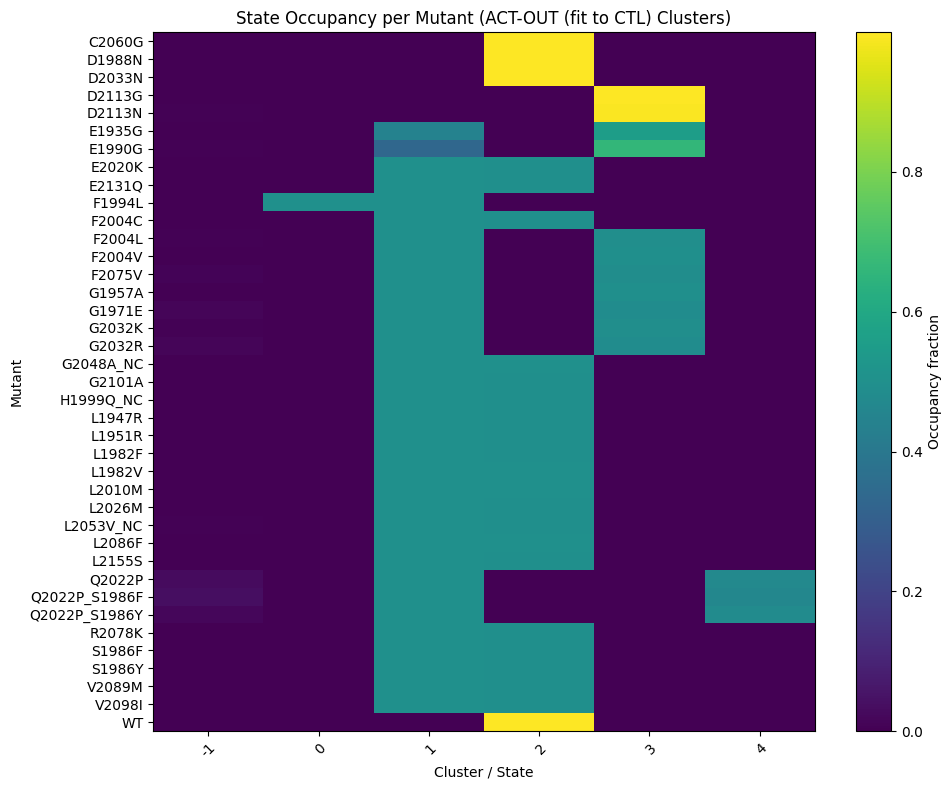

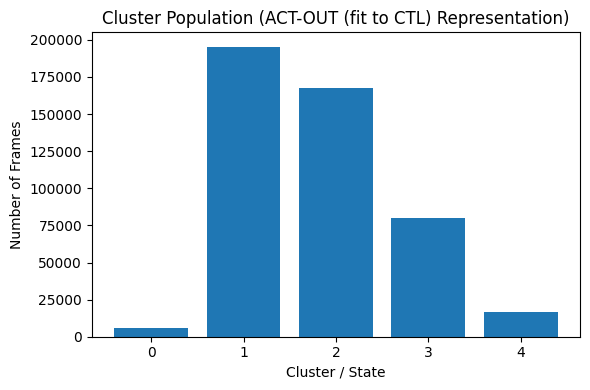

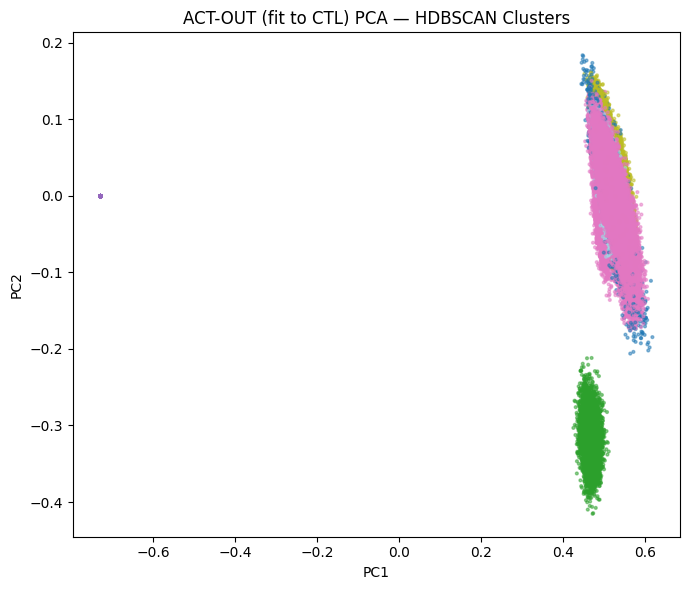

In [37]:
# ============================================================
# CTL-fit ACT-OUT clustering + occupancy + heatmap
# ============================================================

ACT_OUT_CTLFIT_CLUSTER = run_cluster_panel_equal(
    scores_3d=scores_actout_ctlfit,
    F=F,
    prefix="actout_ctlfit",
    title_prefix="ACT-OUT (fit to CTL)",
    n_pcs=5,
    min_cluster_size=150,
    eps=0.8,
    min_samples=60,
)

## Orientation PCA

Orientation PCA was performed on 12 engineered orientation features derived from the relative geometry between the N-terminal lobe (NTL) and C-terminal lobe (CTL) of the kinase domain.

These features describe inter-lobe orientation changes and capture domain rearrangements that may be relevant for kinase activation and inhibitor binding.

The scree plot shows that the first two principal components capture the majority of the variance, while higher components contribute only marginally.

Therefore clustering and visualization were performed using PC1 and PC2.

In [38]:
# ============================================================
# MASK FOR LENGTH MISMATCH (1626 vs 1627)
# ============================================================

eps = 1e-6
nmut, nframes, natoms, ndim = Multiverse.shape
print("natoms from Multiverse:", natoms)

# Rebuild meta from SAME selection string used to build Multiverse
meta = mda.Universe(f"{F[0]}/md-prot.pdb").select_atoms(selection)
print("meta atoms:", len(meta))

if len(meta) != natoms:
    raise ValueError(
        f"meta atoms ({len(meta)}) != Multiverse natoms ({natoms}).\n"
        "That means your Multiverse was built with a different selection than `selection`.\n"
        "Fix: rebuild Multiverse with this selection, OR set `selection` back to what Multiverse used."
    )

# Rebuild atom masks (length = natoms)
CA   = (meta.names == "CA")
BB   = np.isin(meta.names, ["N","CA","C","O"])
BODY = np.isin(meta.resids, np.arange(6, 278))

# exists_all (length = natoms)
valid_sys_atom = np.any(np.linalg.norm(Multiverse, axis=3) > eps, axis=1)  # (nmut, natoms)
exists_all = np.all(valid_sys_atom, axis=0)

# Define ACT/NTL/CTL FROM meta.resids space (then AND exists_all)
# Plotting uses +1933, but selection masks must use meta.resids (1..291)
act_lo = 2045 - 1933   # 112
act_hi = 2070 - 1933   # 137
ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)

ntl_lo = 1934 - 1933   # 1
ntl_hi = 2030 - 1933   # 97
NTL = (meta.resids >= ntl_lo) & (meta.resids <= ntl_hi)

ctl_lo = 2031 - 1933   # 98
ctl_hi = 2225 - 1933   # 292 (clips)
CTL = (meta.resids >= ctl_lo) & (meta.resids <= ctl_hi)

# Apply exists_all to ALL region masks so they match padded-safe atoms
ACT = ACT & exists_all
NTL = NTL & exists_all
CTL = CTL & exists_all

print("Mask lengths:", len(CA), len(BODY), len(CTL), len(NTL), len(ACT), len(exists_all))
print("Counts: CA", int(CA.sum()), "BODY", int(BODY.sum()),
      "CTL", int(CTL.sum()), "NTL", int(NTL.sum()), "ACT", int(ACT.sum()))

natoms from Multiverse: 1627
meta atoms: 1627
Mask lengths: 1627 1627 1627 1627 1627 1627
Counts: CA 292 BODY 1511 CTL 1090 NTL 537 ACT 141


CTL CA atoms: 154 | NTL CA atoms: 92 | nframes_sub: 696
[TIMER] FAST orientation features (NTL vs CTL): 10.242 s
[TIMER] PCA on 12D features: 0.002 s


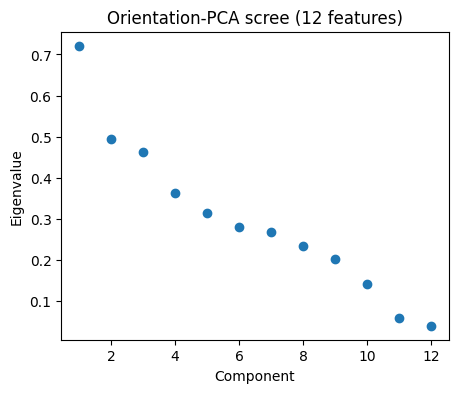

Orientation PCA variance ratios (top 6): [0.2013 0.1379 0.1294 0.1012 0.0875 0.0782]
Orientation PCA cumulative variance (top 6): [0.2013 0.3392 0.4686 0.5698 0.6574 0.7356]
[TIMER] Size scaling from CTL-NTL COM distance: 1.283 s


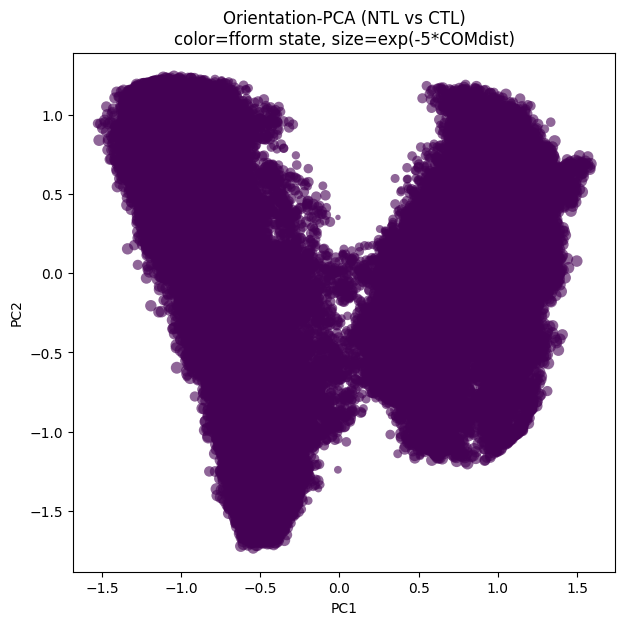

/tmp/ipykernel_3111353/4157940885.py:194: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(yscores[e, 0], yscores[e, 1], c=traj_colors[ti], s=100*d[e], alpha=0.85, linewidths=0, zorder=3)


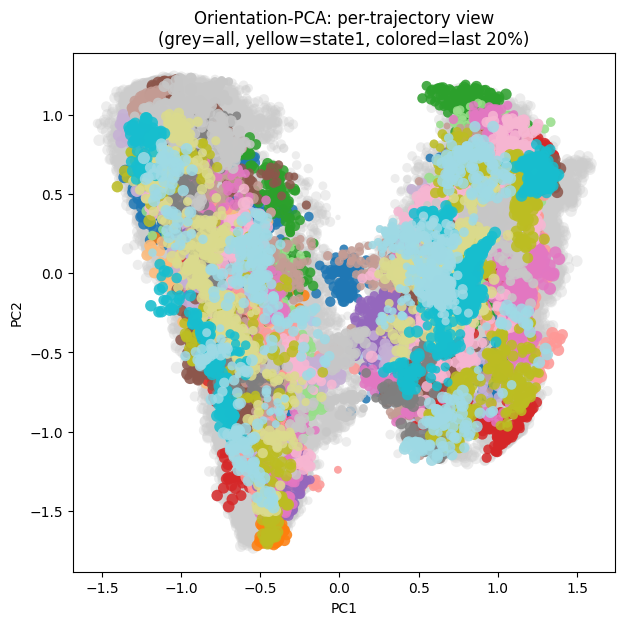

In [39]:
# ============================================================
# Distance/Orientation PCA: NTL vs CTL (COM + principal axis)
# ============================================================

eps = 1e-6

# -----------------------------
# 0) Inputs / fallbacks
# -----------------------------
nmut, nframes, natoms, ndim = Multiverse.shape

if "fform_full" not in globals():
    fform_full = np.zeros((nmut, nframes), dtype=int)

# robust per-trajectory RGB colors 
traj_colors = plt.cm.tab20(np.linspace(0, 1, nmut))[:, :3]          # (nmut, 3)
cb_full = np.repeat(traj_colors[:, None, :], nframes, axis=1)       # (nmut, nframes, 3)


# -----------------------------
# 2) Build SAFE masks
# -----------------------------
if "meta" not in globals() or len(meta) != natoms:
    meta = mda.Universe(f"{F[0]}/md-prot.pdb").select_atoms(selection)

CA = (meta.names == "CA")
BODY = np.isin(meta.resids, np.arange(6, 278))

act_lo = 2045 - 1933
act_hi = 2070 - 1933
ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)

ntl_lo, ntl_hi = 1934 - 1933, 2030 - 1933
ctl_lo, ctl_hi = 2031 - 1933, 2225 - 1933
NTL = (meta.resids >= ntl_lo) & (meta.resids <= ntl_hi)
CTL = (meta.resids >= ctl_lo) & (meta.resids <= ctl_hi)

if "exists_all" in globals() and len(exists_all) == natoms:
    CA_safe   = CA & exists_all
    BODY_safe = BODY & exists_all
else:
    CA_safe   = CA
    BODY_safe = BODY

mask_ctl = CTL & BODY_safe & CA_safe & (~ACT)
mask_ntl = NTL & BODY_safe & CA_safe

ctl_idx = np.where(mask_ctl)[0]
ntl_idx = np.where(mask_ntl)[0]

print("CTL CA atoms:", ctl_idx.size, "| NTL CA atoms:", ntl_idx.size, "| nframes_sub:", nframes_sub)
if ctl_idx.size < 5 or ntl_idx.size < 5:
    raise ValueError("CTL/NTL CA selections are too small. Check residue ranges or masks.")

# -----------------------------
# 3) Helpers
# -----------------------------
def principal_axis(coords):
    _, _, Vt = np.linalg.svd(coords, full_matrices=False)
    v = Vt[0]
    return v / (np.linalg.norm(v) + 1e-12)

def angle(u, v):
    c = np.clip(np.dot(u, v), -1.0, 1.0)
    return np.arccos(c)

# -----------------------------
# 4) Build features per observation (traj,frame)
# -----------------------------
with tim("FAST orientation features (NTL vs CTL)"):
    feats = np.zeros((nmut * nframes_sub, 12), dtype=np.float32)
    obs = 0

    for ti in range(nmut):
        fi = frame_idx_list[ti]                 # <<< EDIT 2: use fixed indices
        xyz = Multiverse[ti, fi]                # <<< EDIT 2: NO `frames` anywhere

        ctl = xyz[:, ctl_idx, :]
        ntl = xyz[:, ntl_idx, :]

        ctl_com = ctl.mean(axis=1)
        ntl_com = ntl.mean(axis=1)

        v = ntl_com - ctl_com
        vnorm = np.linalg.norm(v, axis=1, keepdims=True) + 1e-12
        vhat = v / vnorm

        for fj in range(nframes_sub):
            ctl_c = ctl[fj] - ctl_com[fj]
            ntl_c = ntl[fj] - ntl_com[fj]

            a_ctl = principal_axis(ctl_c)
            a_ntl = principal_axis(ntl_c)

            feats[obs, 0:3] = vhat[fj]
            feats[obs, 3:6] = a_ctl
            feats[obs, 6:9] = a_ntl
            feats[obs, 9]   = angle(vhat[fj], a_ctl)
            feats[obs, 10]  = angle(vhat[fj], a_ntl)
            feats[obs, 11]  = angle(a_ctl, a_ntl)

            obs += 1

# -----------------------------
# 5) PCA (feature covariance: 12x12)
# -----------------------------
m = feats.mean(axis=0, keepdims=True)
Dc = feats - m

with tim("PCA on 12D features"):
    C = (Dc.T @ Dc) / len(Dc)
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

yscores = Dc @ evecs[:, :3]
scores_orient_flat = yscores
scores_orient = yscores.reshape(nmut, nframes_sub, 3)

plt.figure(figsize=(5,4))
plt.scatter(1 + np.arange(len(evals)), evals)
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.title("Orientation-PCA scree (12 features)")
plt.show()

var_ratio = evals / evals.sum()
print("Orientation PCA variance ratios (top 6):", np.round(var_ratio[:6], 4))
print("Orientation PCA cumulative variance (top 6):", np.round(np.cumsum(var_ratio[:6]), 4))

# -----------------------------
# 6) Build label array for subsampled frames (NO `frames`)
# -----------------------------
# <<< EDIT 3: remove `frames` completely; index using frame_idx_list
fform_sub = np.zeros((nmut, nframes_sub), dtype=int)
for ti in range(nmut):
    fi = frame_idx_list[ti]
    fform_sub[ti] = fform_full[ti, fi]
fform_flat = fform_sub.reshape(-1)

# -----------------------------
# 7) Size scaling from CTL-NTL COM distance (NO `frames`)
# -----------------------------
# <<< EDIT 4: use the same fixed indices here too
with tim("Size scaling from CTL-NTL COM distance"):
    dlist = np.zeros((nmut, nframes_sub), dtype=np.float32)
    for ti in range(nmut):
        fi = frame_idx_list[ti]
        xyz = Multiverse[ti, fi]
        ctl_com = xyz[:, ctl_idx, :].mean(axis=1)
        ntl_com = xyz[:, ntl_idx, :].mean(axis=1)
        dist = np.linalg.norm(ntl_com - ctl_com, axis=1) / 10.0
        dlist[ti] = np.exp(-5 * dist)

d = dlist.reshape(-1)
d -= d.min() - 1e-6
d /= d.max()

# -----------------------------
# 8) Plot: global scatter
# -----------------------------
plt.figure(figsize=(7,7))
plt.scatter(
    yscores[:, 0], yscores[:, 1],
    c=fform_flat,
    s=100 * d,
    alpha=0.6,
    linewidths=0
)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Orientation-PCA (NTL vs CTL)\ncolor=fform state, size=exp(-5*COMdist)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -----------------------------
# 9) Per-trajectory view: grey=all, yellow=state1, colored=last 20%
# -----------------------------
nf = nframes_sub
last_frac = 0.20
e_start = int((1 - last_frac) * nf)

fig, ax = plt.subplots(figsize=(7,7))

start = 0
for ti in range(nmut):
    r = slice(start, start + nf)
    e = slice(start + e_start, start + nf)
    f = fform_flat[r].astype(bool)

    ax.scatter(yscores[r, 0], yscores[r, 1], c="#cccccc", s=100*d[r], alpha=0.35, linewidths=0)
    ax.scatter(yscores[r, 0][f], yscores[r, 1][f], c="#999900", s=100*d[r][f], alpha=0.7, linewidths=0)
    ax.scatter(yscores[e, 0], yscores[e, 1], c=traj_colors[ti], s=100*d[e], alpha=0.85, linewidths=0, zorder=3)

    start += nf

ax.set_aspect('equal', adjustable='box')
ax.set_title("Orientation-PCA: per-trajectory view\n(grey=all, yellow=state1, colored=last 20%)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

Orientation clustering uses PC1-PC2 only.
HDBSCAN min_cluster_size=150 | DBSCAN eps=0.3 min_samples=100
Orientation HDBSCAN clusters: 4
Orientation HDBSCAN noise fraction: 0.09689065723548482
Orientation DBSCAN clusters: 1
Orientation DBSCAN noise fraction: 0.0
Orientation occupancy (HDBSCAN primary):


state,-1,0,1,2,3
mutant,,,,,
C2060G,0.157088,0.511494,0.000000,0.000000,0.331418
D1988N,0.277778,0.414272,0.022989,0.003352,0.281609
D2033N,0.148467,0.474617,0.007663,0.001437,0.367816
D2113G,0.060345,0.494732,0.000000,0.000000,0.444923
D2113N,0.045977,0.391762,0.000000,0.000000,0.562261
E1935G,0.037356,0.392241,0.000000,0.007184,0.563218
E1990G,0.048851,0.609674,0.000000,0.000000,0.341475
E2020K,0.025383,0.539751,0.000000,0.000000,0.434866
E2131Q,0.136015,0.563218,0.019636,0.000000,0.281130


Orientation occupancy (DBSCAN baseline):


state,0
mutant,
C2060G,1.0
D1988N,1.0
D2033N,1.0
D2113G,1.0
D2113N,1.0
E1935G,1.0
E1990G,1.0
E2020K,1.0
E2131Q,1.0


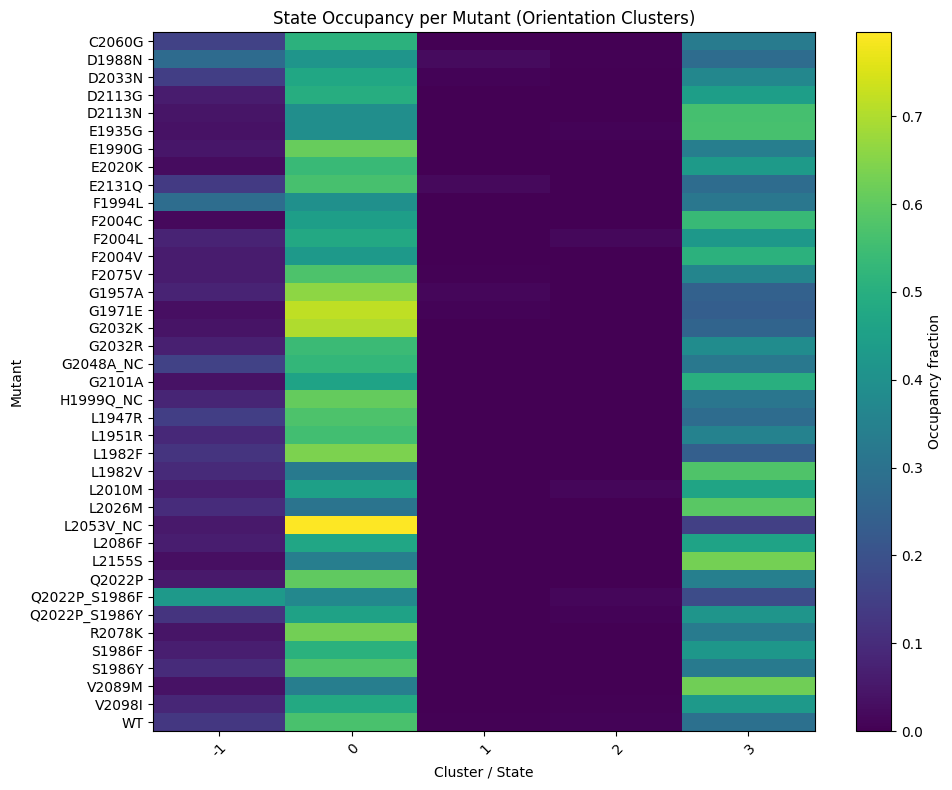

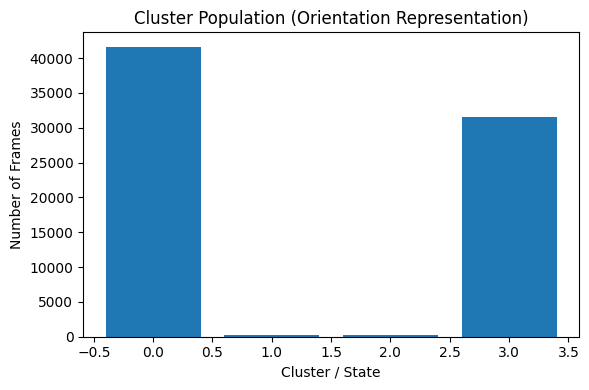

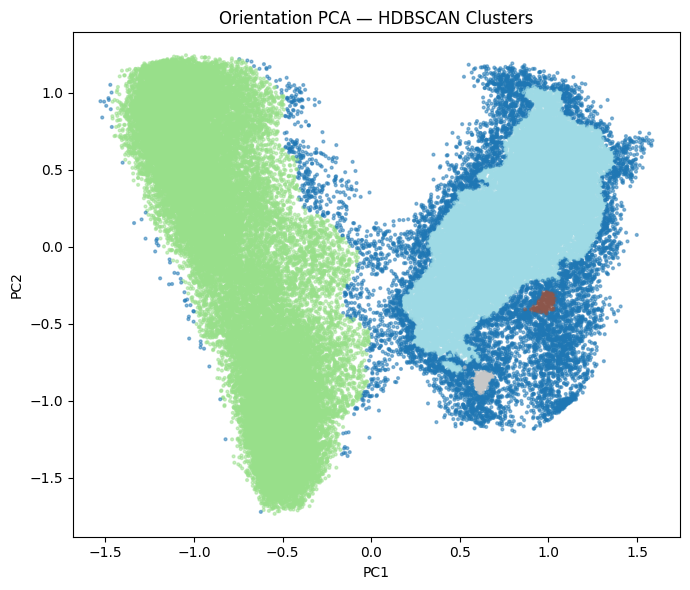

In [40]:
# ============================================================
# ORIENTATION clustering + occupancy + heatmap
# ============================================================
print("Orientation clustering uses PC1-PC2 only.")
print("HDBSCAN min_cluster_size=150 | DBSCAN eps=0.3 min_samples=100")

ORIENTATION_CLUSTER = run_cluster_panel_equal(
    scores_3d=scores_orient,
    F=F,
    prefix="orientation",
    title_prefix="Orientation",
    n_pcs=2,
    min_cluster_size=150,
    eps=0.3,
    min_samples=100,
)


## Distance PCA

In addition to coordinate-based PCA, a distance-based PCA was performed using inter-residue or inter-lobe distance features.

This complementary representation captures geometric relationships directly and can highlight conformational differences that are less obvious in Cartesian coordinate space.

In [41]:
# ============================================================
# fixing F to match the already-loaded Multiverse
# ============================================================

# Making sure F is a plain Python list
if not isinstance(F, list):
    F = list(F)

# Trimming F to match Multiverse
nmut_loaded = Multiverse.shape[0]
F = F[:nmut_loaded]

print("len(F):", len(F))
print("Multiverse trajectories:", Multiverse.shape[0])

len(F): 117
Multiverse trajectories: 117


CTL CA: 154 NTL CA: 92 nframes_sub: 696
D: (81432, 14168)
yscores_dist: (81432, 3)
labels: (81432,) sizes: (81432,) traj_id: (81432,)


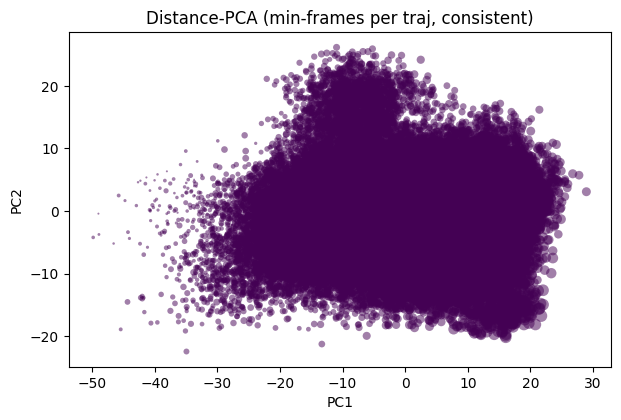

In [42]:
# ============================================================
# DISTANCE-PCA (NTL–CTL CA–CA distances) using frame_idx_list
# -> outputs: yscores_dist, d_dist, fform_flat_dist, traj_id_dist
# ============================================================

# ---- prerequisites ----
nmut = len(F)
assert len(frame_idx_list) == nmut, "frame_idx_list must have one array per trajectory"
nframes_sub = len(frame_idx_list[0])
assert all(len(x) == nframes_sub for x in frame_idx_list), "frame_idx_list lengths must all match"

# ---- build SAFE masks (must be natoms-long and match Multiverse selection) ----
# assumes you already have meta + selection consistent with Multiverse
CA = (meta.names == "CA")
BODY = np.isin(meta.resids, np.arange(6, 278))

act_lo, act_hi = 2045 - 1933, 2070 - 1933
ntl_lo, ntl_hi = 1934 - 1933, 2030 - 1933
ctl_lo, ctl_hi = 2031 - 1933, 2225 - 1933

ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)
NTL = (meta.resids >= ntl_lo) & (meta.resids <= ntl_hi)
CTL = (meta.resids >= ctl_lo) & (meta.resids <= ctl_hi)

if "exists_all" in globals() and len(exists_all) == Multiverse.shape[2]:
    CA = CA & exists_all
    BODY = BODY & exists_all

mask_ctl = CTL & BODY & CA & (~ACT)
mask_ntl = NTL & BODY & CA

ctl_idx = np.where(mask_ctl)[0]
ntl_idx = np.where(mask_ntl)[0]
print("CTL CA:", len(ctl_idx), "NTL CA:", len(ntl_idx), "nframes_sub:", nframes_sub)

# ---- compute distances per frame per traj, vectorize ----
# D_list will be list of (nframes_sub, n_pairs)
D_list = []

for ti in range(nmut):
    idx = frame_idx_list[ti]  # (nframes_sub,)
    MCTL = Multiverse[ti, idx][:, ctl_idx, :]  # (nframes_sub, n_ctl, 3)
    MNTL = Multiverse[ti, idx][:, ntl_idx, :]  # (nframes_sub, n_ntl, 3)

    # pairwise CA-CA distances: (nframes_sub, n_ctl, n_ntl)
    Dij = np.sqrt(((MCTL[:, :, None, :] - MNTL[:, None, :, :]) ** 2).sum(axis=-1))

    # flatten to features: (nframes_sub, n_pairs)
    D_list.append(Dij.reshape(nframes_sub, -1).astype(np.float32))

D = np.vstack(D_list)  # (nmut*nframes_sub, n_pairs)
print("D:", D.shape)

# ---- PCA in feature-space ----
m = D.mean(axis=0, keepdims=True)
Dc = D - m
C = (Dc.T @ Dc) / len(Dc)
evals, evecs = np.linalg.eigh(C)
order = np.argsort(evals)[::-1]
evals = evals[order]
evecs = evecs[:, order]

yscores_dist = Dc @ evecs[:, :3]  # (nobs, 3)
print("yscores_dist:", yscores_dist.shape)

# ---- size scaling (same as Tsjerk style) ----
d_dist = np.exp(-5 * D).sum(axis=1)
d_dist -= d_dist.min() - 1e-6
d_dist /= d_dist.max()

# ---- matching labels for plotting ----
traj_id_dist = np.repeat(np.arange(nmut), nframes_sub)

if "fform_full" in globals():
    # build a per-traj frame label using exact same frame indices
    fform_sub = np.vstack([fform_full[ti, frame_idx_list[ti]] for ti in range(nmut)])
    fform_flat_dist = fform_sub.reshape(-1)
else:
    fform_flat_dist = np.zeros(len(traj_id_dist), dtype=int)

print("labels:", fform_flat_dist.shape, "sizes:", d_dist.shape, "traj_id:", traj_id_dist.shape)

# ---- quick plot ----
plt.figure(figsize=(7,7))
plt.scatter(yscores_dist[:,0], yscores_dist[:,1],
            c=fform_flat_dist, s=80*d_dist, alpha=0.5, linewidths=0)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Distance-PCA (min-frames per traj, consistent)")
plt.show()

## Activation Loop PCA

The activation loop (A-loop) is a key regulatory element of kinase activity.

A dedicated PCA analysis was performed on the activation loop to characterize its conformational variability across mutants.

In [43]:

eps = 1e-6
nmut, nframes, natoms, _ = Multiverse.shape

if "meta" not in globals() or len(meta) != natoms:
    meta = mda.Universe(f"{F[0]}/md-prot.pdb").select_atoms(selection)

# exists_all (only if missing)
if "exists_all" not in globals() or len(exists_all) != natoms:
    with tim("[Aloop] computing exists_all"):
        exists_all = np.isfinite(Multiverse).all(axis=(0, 1, 3))  # (natoms,)
    print("[Aloop] exists_all:", int(exists_all.sum()), "/", natoms)

# A-loop residue window in meta.resids space (your ROS1 convention)
# 2045–2070 in +1933 plotting space => 112–137 in meta.resids
act_lo = 2045 - 1933
act_hi = 2070 - 1933
ACT = (meta.resids >= act_lo) & (meta.resids <= act_hi)

# Use BB atoms for PCA (stronger signal than CA-only)
BB = np.isin(meta.names, ["N", "CA", "C", "O"])

ACT_mask = ACT & BB & exists_all
sel_idx = np.where(ACT_mask)[0].astype(int)
n_sel = sel_idx.size

# ---- SAVE A-loop selection for later motion writing ----
sel_idx_act = sel_idx.copy()      # indices of atoms used in this A-loop PCA
sele_act = ACT_mask.copy()        # natoms-long boolean mask for same selection
print("[Aloop] saved sel_idx_act:", sel_idx_act.size)


print("[Aloop] ACT_mask atoms:", n_sel)
if n_sel < 20:
    raise ValueError("A-loop selection too small. Check residue window or selection.")



[Aloop] saved sel_idx_act: 104
[Aloop] ACT_mask atoms: 104


In [44]:
def kabsch_R(P, Q):
    """
    Rotation R such that (P @ R) ~= Q
    P,Q: (n,3) centered
    """
    C = P.T @ Q
    U, S, Vt = np.linalg.svd(C)
    R = U @ Vt
    if np.linalg.det(R) < 0:
        U[:, -1] *= -1
        R = U @ Vt
    return R

# ------------------------------------------------------------
# 0) Make sure we know natoms from meta and standardize traj shape
# ------------------------------------------------------------
nmut = Multiverse.shape[0]
natoms_meta = len(meta)  # meta must match Multiverse selection

def traj_frames_atoms(M, ti, natoms_expected):
    """
    Return trajectory coords as (nframes, natoms, 3) no matter what.
    Supports:
      (nframes, natoms, 3)
      (natoms, nframes, 3)
    """
    T = M[ti]
    if T.ndim != 3 or T.shape[-1] != 3:
        raise ValueError(f"Unexpected Multiverse[ti] shape: {T.shape}")

    if T.shape[1] == natoms_expected:          # (nframes, natoms, 3)
        return T
    if T.shape[0] == natoms_expected:          # (natoms, nframes, 3) -> transpose
        return np.transpose(T, (1, 0, 2))

    raise ValueError(
        f"Can't infer axis order for traj {ti}: shape {T.shape}, natoms_expected={natoms_expected}"
    )

# Determine nframes from actual standardized traj 0
T0 = traj_frames_atoms(Multiverse, 0, natoms_meta)
nframes = T0.shape[0]
print("[Aloop] standardized traj shape:", T0.shape, "=> nframes =", nframes)

# ------------------------------------------------------------
# 1) Build sel_idx in natoms space (you already had this)
# ------------------------------------------------------------
# sel_idx = np.where(ACT_mask)[0]
n_sel = sel_idx.size

# ------------------------------------------------------------
# 2) Pick a reference frame (finite) from standardized traj
# ------------------------------------------------------------
ref = T0[0, sel_idx, :].astype(np.float64)
if not np.isfinite(ref).all():
    raise ValueError("Reference (traj0 frame0) has non-finite ACT coords. Pick another ref frame.")
ref = ref - ref.mean(axis=0, keepdims=True)

thr_absurd = 1e5  # Å guard (huge-but-finite blowups)

# ------------------------------------------------------------
# 3) Align all frames on A-loop (Kabsch)
# ------------------------------------------------------------
with tim("[Aloop] Align all frames on A-loop (Kabsch)"):
    M_al = np.empty((nmut, nframes, n_sel, 3), dtype=np.float32)
    frame_ok = np.ones((nmut, nframes), dtype=bool)

    for ti in range(nmut):
        T = traj_frames_atoms(Multiverse, ti, natoms_meta)           # (nframes,natoms,3)
        X = T[:, sel_idx, :].astype(np.float64)                      # (nframes,n_sel,3)

        finite = np.isfinite(X).all(axis=(1, 2))                     # (nframes,)
        absurd = (np.abs(X).max(axis=(1, 2)) > thr_absurd)           # (nframes,)
        ok = finite & (~absurd)

        frame_ok[ti, :] = ok

        last_good = None
        for fi in range(nframes):
            if not ok[fi]:
                M_al[ti, fi] = last_good if last_good is not None else 0.0
                continue

            P = X[fi] - X[fi].mean(axis=0, keepdims=True)
            R = kabsch_R(P, ref)
            Pal = (P @ R).astype(np.float32)
            M_al[ti, fi] = Pal
            last_good = Pal

print("[Aloop] bad frames total:", int((~frame_ok).sum()))
print("[Aloop] M_al shape:", M_al.shape)

[Aloop] standardized traj shape: (4001, 1627, 3) => nframes = 4001
[TIMER] [Aloop] Align all frames on A-loop (Kabsch): 29.421 s
[Aloop] bad frames total: 0
[Aloop] M_al shape: (117, 4001, 104, 3)


[TIMER] [Aloop] Vectorize deviations + PCA: 1.874 s
[Aloop] saved loadings_act: (312, 312)
[Aloop] saved mean_act_vec: (312,) | expected: 312


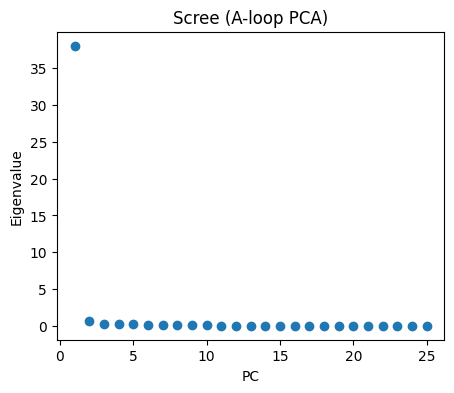

[Aloop] Top 10 variance ratios: [9.551e-01 1.490e-02 5.900e-03 4.700e-03 4.700e-03 2.200e-03 1.800e-03
 1.600e-03 1.300e-03 9.000e-04]
[Aloop] scores: (117, 4000, 5) pscores: (117, 1, 5)
[Aloop] saved scores_act/pscores_act


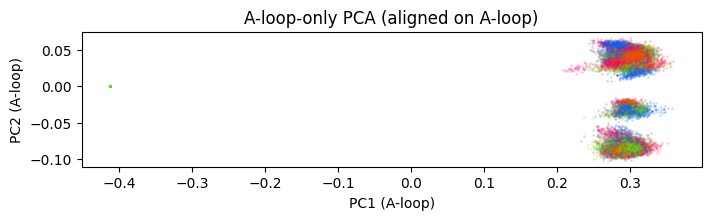

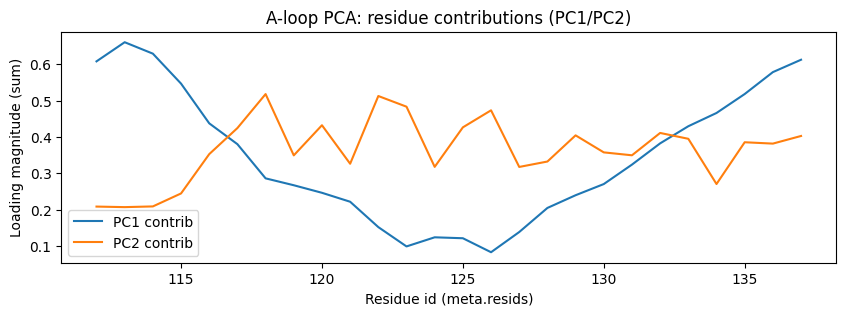

In [45]:
split = 1
ncomponents = 5

with tim("[Aloop] Vectorize deviations + PCA"):
    ok_flat = frame_ok.reshape(-1)                       # (nmut*nframes,)
    Xflat = M_al.reshape(-1, n_sel, 3)                   # (nmut*nframes,n_sel,3)

    # mean from only good frames
    mean_act = Xflat[ok_flat].mean(axis=0)               # (n_sel,3)

    dev = (Xflat - mean_act[None, :, :]).reshape(nmut, nframes, -1)  # (nmut,nframes,n_sel*3)

    P_dev, X_dev = np.split(dev, [split], axis=1)
    P = P_dev.reshape(-1, dev.shape[-1]).astype(np.float32)
    X = X_dev.reshape(-1, dev.shape[-1]).astype(np.float32)

    # PCA (feature covariance)
    Xc = X - X.mean(axis=0, keepdims=True)
    C = (Xc.T @ Xc) / len(Xc)
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

# ---- SAVE A-loop PCA outputs for later motion writing ----
loadings_act = loadings.copy()          # (3*n_sel, 3*n_sel)
mean_act_vec = mean_act.reshape(-1).copy()   # flatten to (3*n_sel,)

print("[Aloop] saved loadings_act:", loadings_act.shape)
print("[Aloop] saved mean_act_vec:", mean_act_vec.shape, "| expected:", 3*len(sel_idx_act))

# Scree
plt.figure(figsize=(5,4))
plt.scatter(np.arange(1, 26), evals[:25])
plt.xlabel("PC")
plt.ylabel("Eigenvalue")
plt.title("Scree (A-loop PCA)")
plt.show()

print("[Aloop] Top 10 variance ratios:", np.round(evals[:10] / evals.sum(), 4))

# Scores (RMSD-like scaling)
scale = np.sqrt(mean_act.size)
scores  = (X @ loadings[:, :ncomponents]).reshape((nmut, -1, ncomponents)) / scale
pscores = (P @ loadings[:, :ncomponents]).reshape((nmut, -1, ncomponents)) / scale
print("[Aloop] scores:", scores.shape, "pscores:", pscores.shape)

scores_act = scores.copy()
pscores_act = pscores.copy()
print("[Aloop] saved scores_act/pscores_act")


# Plot PC1 vs PC2
base_colors = np.array(colors) if "colors" in globals() else np.array(["#ee5500","#55ee00","#0066ff","#ff0066"])
traj_colors = np.tile(base_colors, int(np.ceil(nmut/len(base_colors))))[:nmut]

plt.figure(figsize=(8,8))
for i in range(nmut):
    plt.scatter(pscores[i, :, 0], pscores[i, :, 1], s=6, c="#bbb", alpha=0.25, linewidths=0)
    plt.scatter(scores[i, ::10, 0], scores[i, ::10, 1], s=3, c=[traj_colors[i]], alpha=0.25, linewidths=0)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("PC1 (A-loop)")
plt.ylabel("PC2 (A-loop)")
plt.title("A-loop-only PCA (aligned on A-loop)")
plt.show()

# --- residue contribution (PC1/PC2) ---
def pc_atom_contrib(loadings_pc, n_sel):
    L = loadings_pc.reshape((n_sel, 3))
    return np.sqrt((L**2).sum(axis=1))

pc1_atom = pc_atom_contrib(loadings[:, 0], n_sel)
pc2_atom = pc_atom_contrib(loadings[:, 1], n_sel)

sel_resids = meta.resids[sel_idx]
uniq = np.unique(sel_resids)

pc1_res = np.array([pc1_atom[sel_resids == r].sum() for r in uniq])
pc2_res = np.array([pc2_atom[sel_resids == r].sum() for r in uniq])

plt.figure(figsize=(10,3))
plt.plot(uniq, pc1_res, label="PC1 contrib")
plt.plot(uniq, pc2_res, label="PC2 contrib")
plt.xlabel("Residue id (meta.resids)")
plt.ylabel("Loading magnitude (sum)")
plt.title("A-loop PCA: residue contributions (PC1/PC2)")
plt.legend()
plt.show()

A-loop HDBSCAN clusters: 4
A-loop HDBSCAN noise fraction: 0.00010256410256410256
A-loop DBSCAN clusters: 2
A-loop DBSCAN noise fraction: 0.0
A-loop occupancy (HDBSCAN primary):


state,-1,0,1,2,3
mutant,,,,,
C2060G,0.000500,0.000083,0.999417,0.000000,0.000000
D1988N,0.000000,0.000083,0.999917,0.000000,0.000000
D2033N,0.000000,0.000083,0.999917,0.000000,0.000000
D2113G,0.000000,0.000083,0.000000,0.000583,0.999333
D2113N,0.000167,0.000083,0.000000,0.000083,0.999667
E1935G,0.000000,0.442083,0.000000,0.000000,0.557917
E1990G,0.000167,0.333333,0.000000,0.000000,0.666500
E2020K,0.000000,0.500000,0.500000,0.000000,0.000000
E2131Q,0.000000,0.500000,0.500000,0.000000,0.000000


A-loop occupancy (DBSCAN baseline):


state,0,1
mutant,,
C2060G,0.999917,0.000083
D1988N,0.999917,0.000083
D2033N,0.999917,0.000083
D2113G,0.999917,0.000083
D2113N,0.999917,0.000083
E1935G,0.557917,0.442083
E1990G,0.666667,0.333333
E2020K,0.500000,0.500000
E2131Q,0.500000,0.500000


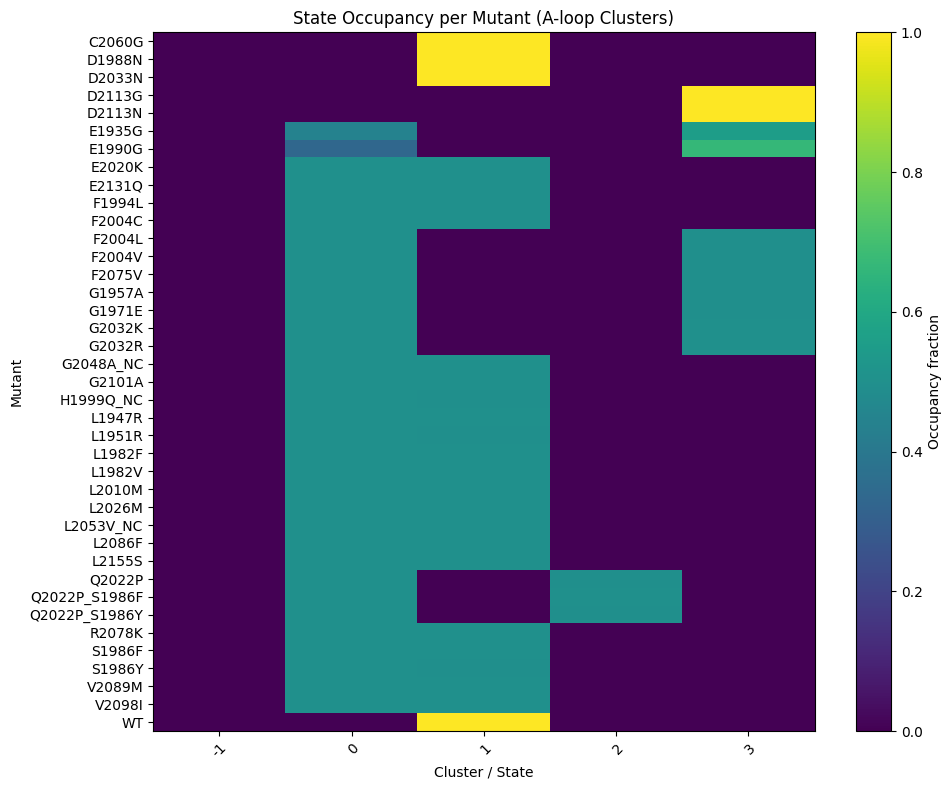

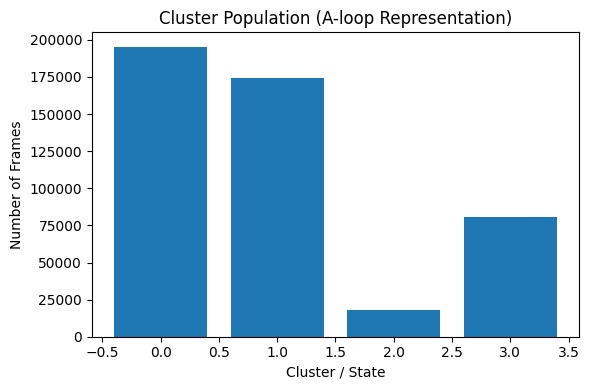

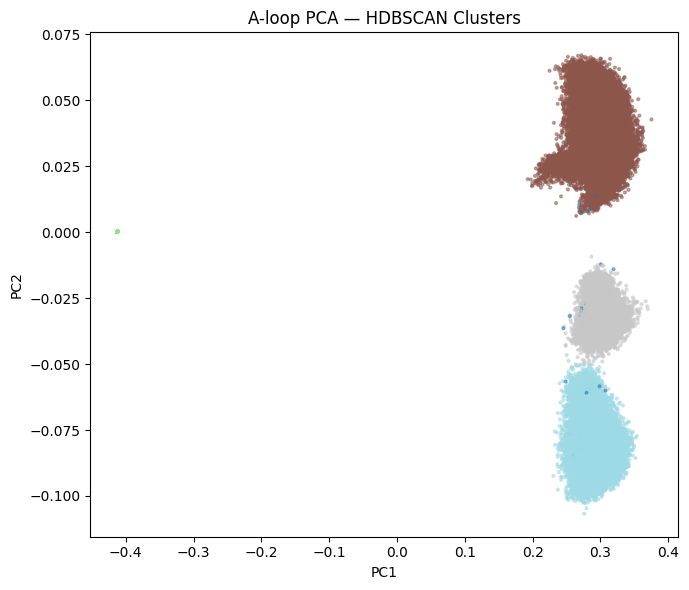

In [46]:
# ============================================================
# A-loop clustering + occupancy + heatmap
# ============================================================

ALOOP_CLUSTER = run_cluster_panel_equal(
    scores_3d=scores_act,
    F=F,
    prefix="aloop",
    title_prefix="A-loop",
    n_pcs=3,
    min_cluster_size=120,
    eps=0.6,
    min_samples=50,
)


## Tyrosine Loop PCA

The tyrosine loop (Tyr-loop) forms part of the catalytic site and contributes to substrate recognition.

PCA of this loop was performed to examine mutation-dependent structural variability in the catalytic region.

In [47]:
# --- sanity ---
assert "Multiverse" in globals(), "Multiverse missing"
assert "F" in globals() and isinstance(F, list) and isinstance(F[0], str), "F missing/corrupted"
assert "selection" in globals(), "selection missing"
assert "tim" in globals(), "tim missing"

nmut, nframes, natoms, _ = Multiverse.shape
print("Multiverse:", Multiverse.shape)

# meta must match natoms exactly
meta = mda.Universe(f"{F[0]}/md-prot.pdb").select_atoms(selection)
if len(meta) != natoms:
    raise ValueError(f"meta atoms {len(meta)} != natoms {natoms}. Selection mismatch.")

Multiverse: (117, 4001, 1627, 3)


In [48]:
# basic atom masks
CA = (meta.names == "CA")
BB = np.isin(meta.names, ["N", "CA", "C", "O"])

# BODY core (same as your pipeline)
BODY = np.isin(meta.resids, np.arange(6, 278))

# exists_all (only if missing)
eps = 1e-6
if "exists_all" not in globals() or len(exists_all) != natoms:
    with tim("[TYR] computing exists_all"):
        exists_all = np.isfinite(Multiverse).all(axis=(0, 1, 3))  # (natoms,)
    print("[TYR] exists_all:", int(exists_all.sum()), "/", natoms)

# Tyrosine-loop residue window (EDIT if you want)
LOOP_RES_RANGE = np.arange(170, 191)  # 170..190 inclusive

loop_atoms = np.isin(meta.resids, LOOP_RES_RANGE) & exists_all

loop_CA = loop_atoms & CA
loop_BB = loop_atoms & BB

# Fit mask for alignment: BODY backbone
fit_mask = (BB & BODY & exists_all)

print("loop_CA atoms:", int(loop_CA.sum()))
print("loop_BB atoms:", int(loop_BB.sum()))
print("fit_mask atoms:", int(fit_mask.sum()))

if loop_BB.sum() < 10:
    raise ValueError("loop_BB too small — check residue range or ACTUAL resids in meta.")
if fit_mask.sum() < 50:
    raise ValueError("fit_mask too small — check BODY/BB selection.")

loop_CA atoms: 21
loop_BB atoms: 84
fit_mask atoms: 1088


In [49]:
with tim("[TYR] Alignment on BODY backbone (robust)"):
    ref = Multiverse[0, 0].astype(np.float64)                  # (natoms,3)
    ref_fit = ref[fit_mask]
    ref_fit -= ref_fit.mean(axis=0, keepdims=True)

    means_fit = Multiverse[:, :, fit_mask].mean(axis=2, keepdims=True)   # (nmut,nframes,1,3)
    Xfit = (Multiverse[:, :, fit_mask] - means_fit).astype(np.float64)   # (nmut,nframes,nfit,3)

    # 3x3 matrices per frame
    M = np.einsum("ij,tfjk->tfik", (ref_fit.T / (3.0 * ref_fit.shape[0])), Xfit)

    badM = ~np.isfinite(M).all(axis=(2, 3))
    if badM.any():
        print("[WARN] badM frames:", int(badM.sum()), "-> forcing identity there")
        M[badM] = np.eye(3, dtype=np.float64)

    U, S, Vt = np.linalg.svd(M)
    R = (U @ Vt).astype(np.float32)

    Multiverse_al = (Multiverse - means_fit) @ np.transpose(R, (0, 1, 3, 2))

print("[TYR] aligned finite:", bool(np.isfinite(Multiverse_al).all()))

[TIMER] [TYR] Alignment on BODY backbone (robust): 88.646 s
[TYR] aligned finite: True


[TIMER] [TYR] Vectorizing loop deviations: 5.727 s
[TYR] X: (468000, 252) | finite: True
[TIMER] [TYR] PCA diagonalization (feature-space): 1.231 s


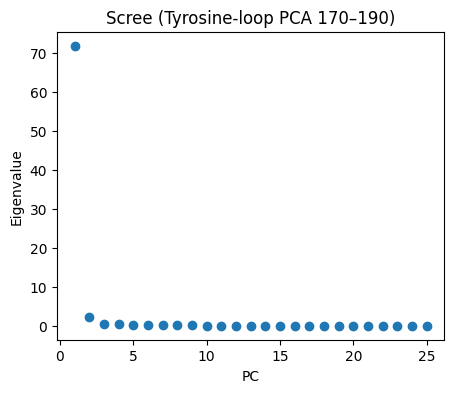

[TYR] Top 5 variance ratios: [0.9385 0.0291 0.0075 0.0067 0.0034]


In [50]:
split_loop = 1          # keeping it simple
ncomponents = 10

with tim("[TYR] Vectorizing loop deviations"):
    Sloop = Multiverse_al[:, :, loop_BB, :].astype(np.float64)      # (nmut,nframes,n_loop,3)

    # guard: huge coordinate blowups 
    thr = 1e5
    if np.abs(Sloop).max() > thr:
        raise ValueError("Loop coords contain absurd values (>1e5 Å). Run your huge-frame patch first.")

    mean_loop = Sloop.mean(axis=(0, 1))                             # (n_loop,3)
    dev = Sloop - mean_loop                                         # (nmut,nframes,n_loop,3)

    P, X = np.split(dev, [split_loop], axis=1)
    P = P.reshape((-1, mean_loop.size))
    X = X.reshape((-1, mean_loop.size))

print("[TYR] X:", X.shape, "| finite:", bool(np.isfinite(X).all()))

with tim("[TYR] PCA diagonalization (feature-space)"):
    Xc = X - X.mean(axis=0, keepdims=True)
    C = (Xc.T @ Xc) / len(Xc)
    evals, loadings = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    loadings = loadings[:, order]

# Scree
plt.figure(figsize=(5,4))
plt.scatter(np.arange(1, 26), evals[:25])
plt.xlabel("PC")
plt.ylabel("Eigenvalue")
plt.title("Scree (Tyrosine-loop PCA 170–190)")
plt.show()

print("[TYR] Top 5 variance ratios:", np.round(evals[:5] / evals.sum(), 4))

[TYR] scores: (117, 4000, 10) pscores: (117, 1, 10)


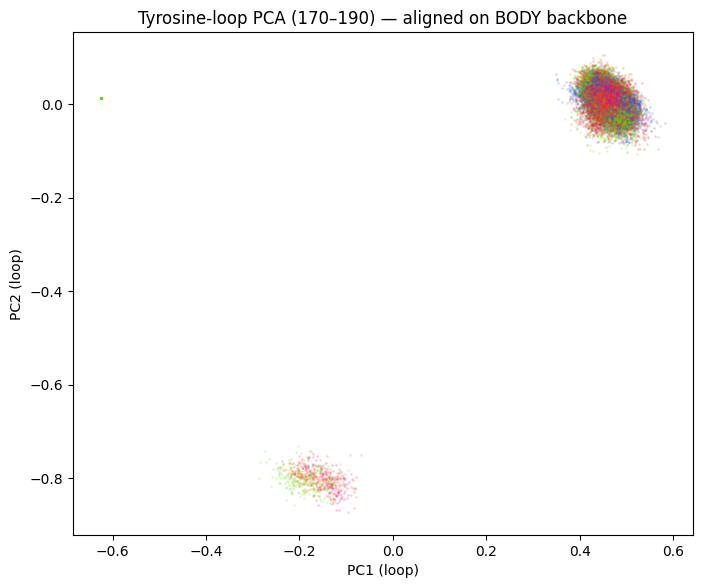

In [51]:
scale = np.sqrt(mean_loop.size)  # RMSD-like scaling

scores  = (X @ loadings[:, :ncomponents]).reshape((nmut, -1, ncomponents)) / scale
pscores = (P @ loadings[:, :ncomponents]).reshape((nmut, -1, ncomponents)) / scale

print("[TYR] scores:", scores.shape, "pscores:", pscores.shape)

# colors per trajectory
base_colors = np.array(colors) if "colors" in globals() else np.array(["#ee5500","#55ee00","#0066ff","#ff0066"])
traj_colors = np.tile(base_colors, int(np.ceil(nmut/len(base_colors))))[:nmut]

stride_plot = 10

plt.figure(figsize=(8,8))
for i in range(nmut):
    # early frames grey
    plt.scatter(pscores[i, :, 0], pscores[i, :, 1], s=6, c="#bbb", alpha=0.25, linewidths=0)
    # production frames colored
    plt.scatter(scores[i, ::stride_plot, 0], scores[i, ::stride_plot, 1], s=3, c=[traj_colors[i]], alpha=0.25, linewidths=0)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("PC1 (loop)")
plt.ylabel("PC2 (loop)")
plt.title("Tyrosine-loop PCA (170–190) — aligned on BODY backbone")
plt.show()

### Save Tyr-loop PCA Outputs

The Tyr-loop PCA scores were saved for downstream clustering, comparison across mutants, and possible structural visualization of dominant loop motions.

In [52]:
scores_tyr = scores.copy()
pscores_tyr = pscores.copy()
print("Saved scores_tyr:", scores_tyr.shape)


Saved scores_tyr: (117, 4000, 10)


Tyrosine loop HDBSCAN clusters: 3
Tyrosine loop HDBSCAN noise fraction: 0.0
Tyrosine loop DBSCAN clusters: 3
Tyrosine loop DBSCAN noise fraction: 0.0
Tyrosine loop occupancy (HDBSCAN primary):


state,0,1,2
mutant,,,
C2060G,0.0,0.999917,0.000083
D1988N,0.0,0.999917,0.000083
D2033N,0.0,0.999917,0.000083
D2113G,0.0,0.999917,0.000083
D2113N,0.0,0.999917,0.000083
E1935G,0.0,0.557917,0.442083
E1990G,0.0,0.666667,0.333333
E2020K,0.0,0.500000,0.500000
E2131Q,0.0,0.500000,0.500000


Tyrosine loop occupancy (DBSCAN baseline):


state,0,1,2
mutant,,,
C2060G,0.999917,0.000083,0.0
D1988N,0.999917,0.000083,0.0
D2033N,0.999917,0.000083,0.0
D2113G,0.999917,0.000083,0.0
D2113N,0.999917,0.000083,0.0
E1935G,0.557917,0.442083,0.0
E1990G,0.666667,0.333333,0.0
E2020K,0.500000,0.500000,0.0
E2131Q,0.500000,0.500000,0.0


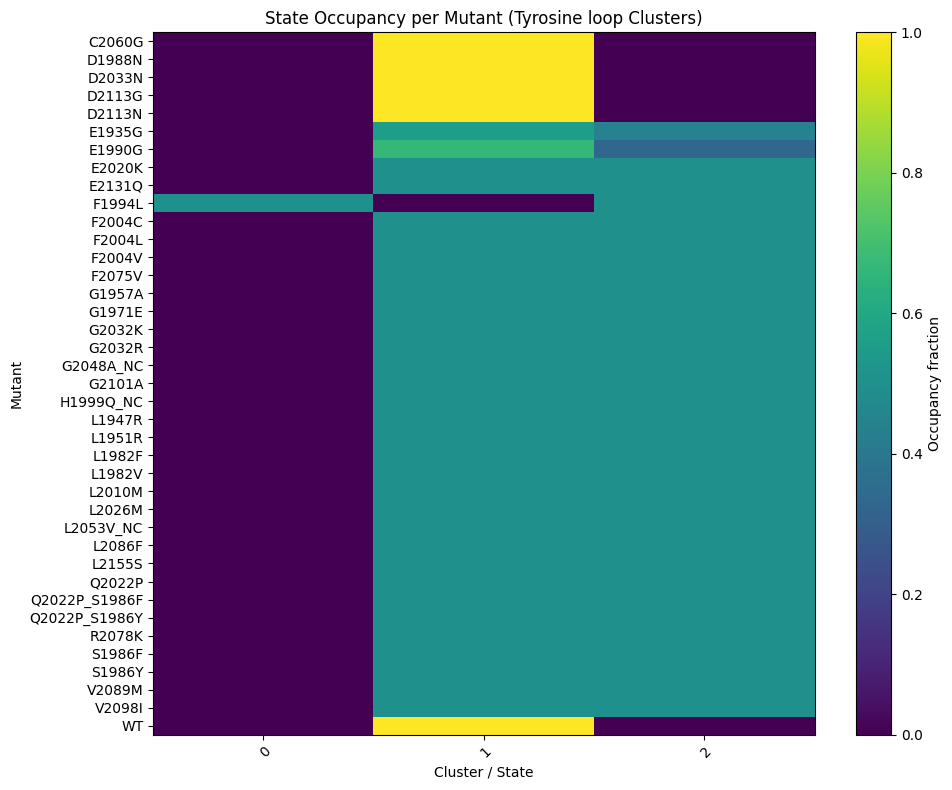

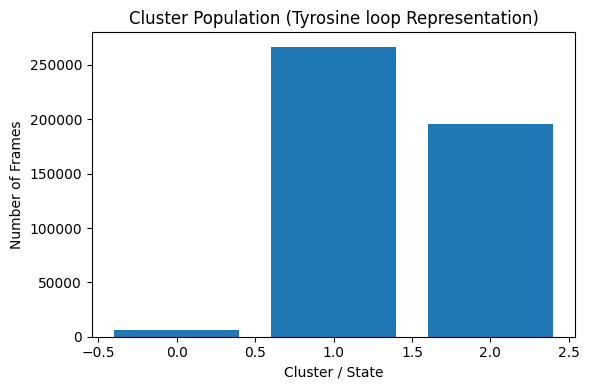

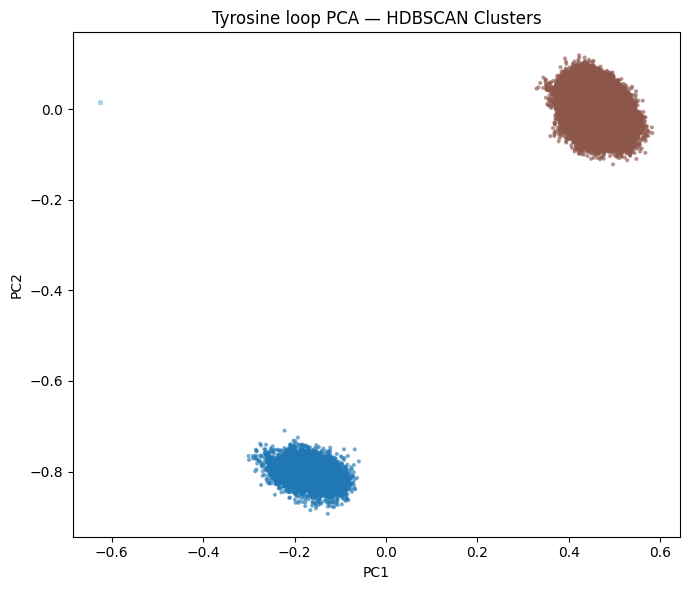

In [53]:
# ============================================================
# Tyr-loop clustering + occupancy + heatmap
# ============================================================

TYR_CLUSTER = run_cluster_panel_equal(
    scores_3d=scores_tyr,
    F=F,
    prefix="tyrloop",
    title_prefix="Tyrosine loop",
    n_pcs=3,
    min_cluster_size=120,
    eps=0.6,
    min_samples=50,
)


## Further Analysis

The following analyses provide additional interpretation of the PCA and clustering results.

These include sanity checks, basin decomposition, transition behavior, and simple interpretable structural metrics that help connect low-dimensional projections to physically meaningful conformational changes.

[FIX] ntraj: 117 | nframes_sub: 696 | natoms: 1627
[FIX] len(meta)= 1627 | len(resids_atom)= 1627 | resids_atom range: 1934 -> 2225

[ACT] BB atoms: 104 | ACT_RES: 2045 - 2070
[TIMER] [ACT] Compute A-loop RMSD + ACT_state (subsampled): 0.596 s
[ACT] thr_ACT (nm): 0.12
[ACT] overall fraction ACT_state=1: 0.6284998526377836


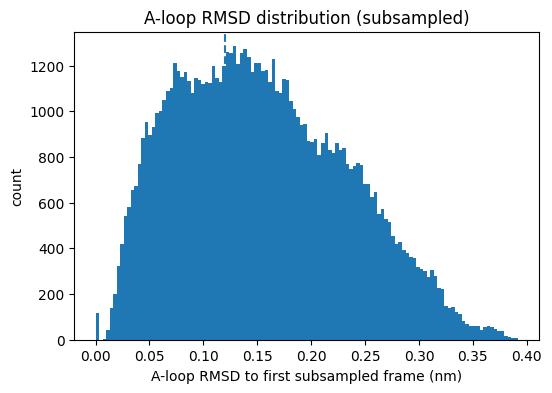

[TIMER] [DFG] Bridge dfg_state_list -> DFG_state (subsampled): 0.002 s
[DFG] DFG_state shape: (117, 696) | mean state=1: 0.5230007859318204

[FORMS] Counts:
Frames ACT_low: 30252 ACT_high: 51180
ACT_low & DFG_low: 14354 | ACT_low & DFG_high: 15898
ACT_high & DFG_low: 24489 | ACT_high & DFG_high: 26691

[ACT_state] mean fraction=1 per mutant (avg over replicas):
C2060G 0.456
D1988N 0.44
D2033N 0.688
D2113G 0.629
D2113N 0.615
E1935G 0.401
E1990G 0.852
E2020K 0.606
E2131Q 0.546
F1994L 0.64
F2004C 0.731
F2004L 0.655
F2004V 0.678
F2075V 0.806
G1957A 0.81
G1971E 0.744
G2032K 0.511
G2032R 0.49
G2048A_NC 0.502
G2101A 0.562
H1999Q_NC 0.745
L1947R 0.529
L1951R 0.747
L1982F 0.493
L1982V 0.705
L2010M 0.534
L2026M 0.677
L2053V_NC 0.445
L2086F 0.702
L2155S 0.566
Q2022P 0.615
Q2022P_S1986F 0.549
Q2022P_S1986Y 0.464
R2078K 0.662
S1986F 0.748
S1986Y 0.816
V2089M 0.746
V2098I 0.75
WT 0.654

[DFG_state] mean fraction=1 per mutant (avg over replicas):
C2060G 0.544
D1988N 0.367
D2033N 0.539
D2113G 0.625
D2

In [54]:
# ============================================================
# further analysis
# ============================================================

# -----------------------------
# (0) Timer fallback (optional)
# -----------------------------
try:
    tim
    _HAS_TIM = True
except NameError:
    _HAS_TIM = False
    class _DummyTimer:
        def __call__(self, msg): 
            from contextlib import contextmanager
            @contextmanager
            def _cm():
                yield
            return _cm()
    tim = _DummyTimer()

# ------------------------------------------------------------
# (A) Sanity + FIX: resids_atom MUST match meta length/order
# ------------------------------------------------------------
ntraj, _, natoms, _ = Multiverse.shape
assert len(F) == ntraj, "F must match Multiverse trajectories (fix F before running)."
assert len(frame_idx_list) == ntraj, "frame_idx_list must match ntraj."
assert len(meta) == natoms, "meta must match Multiverse natoms."

# Convert meta.resids to REAL numbering aligned to meta
if int(meta.resids.max()) <= 500:   # local numbering (e.g., 1..291)
    resids_atom = meta.resids.astype(int) + 1933
else:                               # already real numbering (e.g., 1934..2225)
    resids_atom = meta.resids.astype(int)

print("[FIX] ntraj:", ntraj, "| nframes_sub:", nframes_sub, "| natoms:", natoms)
print("[FIX] len(meta)=", len(meta), "| len(resids_atom)=", len(resids_atom),
      "| resids_atom range:", int(resids_atom.min()), "->", int(resids_atom.max()))

# ------------------------------------------------------------
# (B) Helper: PC1 two-state labeling from any PCA scores
# ------------------------------------------------------------
from scipy.ndimage import gaussian_filter1d

def pc1_two_state_summary(scores_flat, ntraj, nframes_sub, F, bins=200, smooth_sigma=3):
    """
    scores_flat: (ntraj*nframes_sub, nPC)
    Returns:
      labels2 : (ntraj, nframes_sub) 0/1
      frac   : (ntraj,) fraction in state=1
      thr    : float threshold on PC1
      summary: list (mutant, mean_frac, std_frac, nrep)
    """
    pc1 = scores_flat[:, 0].astype(float)

    hist, edges = np.histogram(pc1, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    hs = gaussian_filter1d(hist.astype(float), sigma=smooth_sigma)

    pk = np.argsort(hs)[-2:]
    pk = np.sort(pk)

    if pk[1] - pk[0] < 10:
        thr = float(np.median(pc1))
        method = "median fallback"
    else:
        valley = pk[0] + int(np.argmin(hs[pk[0]:pk[1]]))
        thr = float(centers[valley])
        method = "valley split"

    print("\n[PC1 TWO-STATE] threshold:", thr, f"({method})")

    plt.figure(figsize=(6,4))
    plt.plot(centers, hs)
    plt.axvline(thr, ls="--")
    plt.xlabel("PC1")
    plt.ylabel("smoothed count")
    plt.title("PC1 distribution + two-state threshold")
    plt.show()

    labels = (pc1 > thr).astype(np.int8)
    labels2 = labels.reshape(ntraj, nframes_sub)
    frac = labels2.mean(axis=1)

    mutant_of = np.array([p.split('/')[0] for p in F], dtype=object)
    summary = []
    for m in sorted(set(mutant_of)):
        idx = np.where(mutant_of == m)[0]
        summary.append((m, float(frac[idx].mean()), float(frac[idx].std()), int(len(idx))))
    summary.sort(key=lambda x: x[1], reverse=True)

    print("Top 10 mutants by mean frac(State=1):")
    for row in summary[:10]:
        print(row)

    return labels2, frac, thr, summary


# ------------------------------------------------------------
# (1) ACT (A-loop) in/out from A-loop RMSD (nm), SUBSAMPLED
# ------------------------------------------------------------
# EDIT IF NEEDED: your ACT loop residue range in REAL numbering
ACT_RES = np.arange(2045, 2071)   # change only if your ACT definition differs
thr_ACT = 0.12                    # nm (your valley threshold)

ACT_mask = np.isin(resids_atom, ACT_RES)
ACT_loop_BB = ACT_mask & np.isin(meta.names, ["N", "CA", "C", "O"])
ACT_idx = np.where(ACT_loop_BB)[0].astype(int)

print("\n[ACT] BB atoms:", ACT_idx.size, "| ACT_RES:", int(ACT_RES.min()), "-", int(ACT_RES.max()))
if ACT_idx.size == 0:
    raise ValueError("ACT_idx empty. Check ACT_RES vs resids_atom numbering.")

with tim("[ACT] Compute A-loop RMSD + ACT_state (subsampled)"):
    aloop_rmsd = np.zeros((ntraj, nframes_sub), dtype=np.float32)

    for ti in range(ntraj):
        fi = frame_idx_list[ti]                      # original frame indices
        X = Multiverse[ti, fi][:, ACT_idx, :]        # (Tsub, n_act, 3)
        ref = X[0]
        diff = X - ref[None, :, :]
        aloop_rmsd[ti] = np.sqrt((diff**2).sum(axis=(1,2)) / ACT_idx.size) / 10.0

ACT_state = (aloop_rmsd > thr_ACT).astype(np.int8)

print("[ACT] thr_ACT (nm):", thr_ACT)
print("[ACT] overall fraction ACT_state=1:", float(ACT_state.mean()))

plt.figure(figsize=(6,4))
plt.hist(aloop_rmsd.ravel(), bins=120)
plt.axvline(thr_ACT, ls="--")
plt.xlabel("A-loop RMSD to first subsampled frame (nm)")
plt.ylabel("count")
plt.title("A-loop RMSD distribution (subsampled)")
plt.show()


# ------------------------------------------------------------
# (2) BRIDGE: Use your EXISTING DFG labeling (dfg_state_list)
#     -> build DFG_state aligned to frame_idx_list / nframes_sub
# ------------------------------------------------------------
if "dfg_state_list" not in globals():
    raise NameError("dfg_state_list not found. Run your existing DFG χ1 labeling cell first.")

with tim("[DFG] Bridge dfg_state_list -> DFG_state (subsampled)"):
    DFG_state = np.zeros((ntraj, nframes_sub), dtype=np.int8)

    for ti in range(ntraj):
        fi = frame_idx_list[ti]  # original frame indices used everywhere else
        arr = np.asarray(dfg_state_list[ti]).astype(np.int8)

        if arr.ndim != 1:
            raise ValueError(f"dfg_state_list[{ti}] must be 1D, got shape {arr.shape}")

        # If your dfg_state_list is full length (common), this will work directly:
        if fi.max() >= arr.size:
            raise ValueError(
                f"DFG bridge failed for traj {ti} ({F[ti]}): "
                f"max(fi)={int(fi.max())} but dfg_state_list length={arr.size}. "
                "This means dfg_state_list was NOT computed on full frames. "
                "Tell me how you computed it and I’ll match the indexing."
            )

        DFG_state[ti] = arr[fi][:nframes_sub]

print("[DFG] DFG_state shape:", DFG_state.shape, "| mean state=1:", float(DFG_state.mean()))


# ------------------------------------------------------------
# (3) ACT x DFG per-form masks + counts
# ------------------------------------------------------------
ACT_low  = (ACT_state == 0)
ACT_high = (ACT_state == 1)

DFG_low  = (DFG_state == 0)
DFG_high = (DFG_state == 1)

ACTlow_DFGlow   = ACT_low  & DFG_low
ACTlow_DFGhigh  = ACT_low  & DFG_high
ACThigh_DFGlow  = ACT_high & DFG_low
ACThigh_DFGhigh = ACT_high & DFG_high

print("\n[FORMS] Counts:")
print("Frames ACT_low:", int(ACT_low.sum()), "ACT_high:", int(ACT_high.sum()))
print("ACT_low & DFG_low:", int(ACTlow_DFGlow.sum()), "| ACT_low & DFG_high:", int(ACTlow_DFGhigh.sum()))
print("ACT_high & DFG_low:", int(ACThigh_DFGlow.sum()), "| ACT_high & DFG_high:", int(ACThigh_DFGhigh.sum()))


# ------------------------------------------------------------
# (4) Per-mutant occupancy summaries (ACT + DFG + forms)
# ------------------------------------------------------------
mutant_of = np.array([p.split("/")[0] for p in F], dtype=object)
uniq_mut = np.unique(mutant_of)

def per_mutant_mean(x01, title):
    print(f"\n[{title}] mean fraction=1 per mutant (avg over replicas):")
    out = {}
    for mut in uniq_mut:
        idx = np.where(mutant_of == mut)[0]
        out[mut] = float(x01[idx].mean())
        print(mut, round(out[mut], 3))
    return out

occ_ACT = per_mutant_mean(ACT_state, "ACT_state")
occ_DFG = per_mutant_mean(DFG_state, "DFG_state")

# Forms: show mean fraction per form per mutant (sums to 1)
print("\n[FORMS] mean fraction per mutant (avg over replicas):")
for mut in uniq_mut:
    idx = np.where(mutant_of == mut)[0]
    a = float(ACTlow_DFGlow[idx].mean())
    b = float(ACTlow_DFGhigh[idx].mean())
    c = float(ACThigh_DFGlow[idx].mean())
    d = float(ACThigh_DFGhigh[idx].mean())
    # print compact
    print(f"{mut:16s}  AL_DL={a:.3f}  AL_DH={b:.3f}  AH_DL={c:.3f}  AH_DH={d:.3f}   sum={a+b+c+d:.3f}")

print("\nDONE. You now have:")
print("  aloop_rmsd, ACT_state")
print("  DFG_state  (from your existing dfg_state_list)")
print("  ACTlow_DFGlow, ACTlow_DFGhigh, ACThigh_DFGlow, ACThigh_DFGhigh")
print("  pc1_two_state_summary(scores_flat, ...) helper (optional)")

Multiverse: (117, 4001, 1627, 3)
len(F): 117
nframes_sub: 696
ACT_state: (117, 696) mean1: 0.6284998526377836
DFG_state: (117, 696) mean1: 0.5230007859318204

WT indices: [114, 115, 116] -> ['WT/Simulation_1', 'WT/Simulation_2', 'WT/Simulation_3']

WT ACT_state occupancies:
WT/Simulation_1 ACT_state=1 frac: 0.307
WT/Simulation_2 ACT_state=1 frac: 0.741
WT/Simulation_3 ACT_state=1 frac: 0.914

WT DFG_state occupancies:
WT/Simulation_1 DFG_state=1 frac: 0.611
WT/Simulation_2 DFG_state=1 frac: 0.578
WT/Simulation_3 DFG_state=1 frac: 0.527

Using basins from: ORIENTATION PCA | scores_flat shape: (81432, 3)
[PC1 BASIN] threshold (median): -0.27369631826877594
[PC1 BASIN] overall basin=1 fraction: 0.5


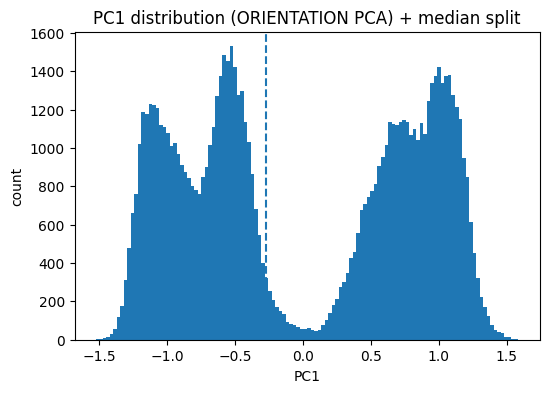


WT PC1 basin occupancies:
WT/Simulation_1 basin1 frac: 0.578
WT/Simulation_2 basin1 frac: 0.511
WT/Simulation_3 basin1 frac: 0.499

PC1 basin occupancy per mutant (avg over replicas):
C2060G 0.529
D1988N 0.603
D2033N 0.528
D2113G 0.503
D2113N 0.622
E1935G 0.607
E1990G 0.389
E2020K 0.46
E2131Q 0.458
F1994L 0.579
F2004C 0.611
F2004L 0.528
F2004V 0.571
F2075V 0.435
G1957A 0.352
G1971E 0.305
G2032K 0.307
G2032R 0.486
G2048A_NC 0.468
G2101A 0.536
H1999Q_NC 0.356
L1947R 0.438
L1951R 0.446
L1982F 0.364
L1982V 0.707
L2010M 0.55
L2026M 0.714
L2053V_NC 0.215
L2086F 0.53
L2155S 0.684
Q2022P 0.405
Q2022P_S1986F 0.643
Q2022P_S1986Y 0.542
R2078K 0.385
S1986F 0.495
S1986Y 0.428
V2089M 0.662
V2098I 0.53
WT 0.529

Transitions (PC1 basins):
WT switch counts: [146, 85, 144]
WT mean dwell (frames): [np.float64(4.7), np.float64(8.1), np.float64(4.8)]

Per-mutant transition summary (mean over replicas):
C2060G            switches=  99.7 ±   8.1   dwell(fr)=   7.0 ±   0.5
D1988N            switches= 130.0 ±

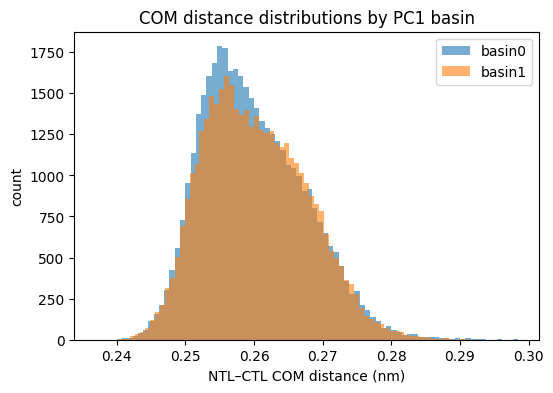

In [55]:
# ============================================================
# SANITY + two-state basins + transitions + interpretable metric
# ============================================================

# ----------------------------
# 0) Basic sanity checks
# ----------------------------
assert "Multiverse" in globals(), "Multiverse missing"
assert "F" in globals() and isinstance(F, list) and isinstance(F[0], str), "F is missing or corrupted (should be list of paths)"
assert "frame_idx_list" in globals(), "frame_idx_list missing (build it once early and reuse)"

ntraj_mv, _, natoms, _ = Multiverse.shape
print("Multiverse:", Multiverse.shape)
print("len(F):", len(F))

assert len(F) == ntraj_mv, "len(F) != Multiverse.shape[0]  (you overwrote F or rebuilt Multiverse with different sims)"
assert len(frame_idx_list) == len(F), "frame_idx_list must have one index array per trajectory"

nframes_sub = len(frame_idx_list[0])
assert all(len(x) == nframes_sub for x in frame_idx_list), "frame_idx_list arrays are not all same length"
print("nframes_sub:", nframes_sub)

# ACT/DFG shape checks (if they exist)
if "ACT_state" in globals():
    print("ACT_state:", ACT_state.shape, "mean1:", float(ACT_state.mean()))
    assert ACT_state.shape == (len(F), nframes_sub), "ACT_state must be (ntraj, nframes_sub)"
else:
    print("ACT_state not found (ok if you haven't built it yet)")

if "DFG_state" in globals():
    print("DFG_state:", DFG_state.shape, "mean1:", float(DFG_state.mean()))
    assert DFG_state.shape == (len(F), nframes_sub), "DFG_state must be (ntraj, nframes_sub)"
else:
    print("DFG_state not found (ok if you haven't bridged it yet)")

# ----------------------------
# 1) WT replica occupancies (ACT/DFG)
# ----------------------------
wt_idx = [i for i,p in enumerate(F) if p.startswith("WT/")]
print("\nWT indices:", wt_idx, "->", [F[i] for i in wt_idx])

def _occ(x01):
    return float(x01.mean())

if wt_idx and "ACT_state" in globals():
    print("\nWT ACT_state occupancies:")
    for i in wt_idx:
        print(F[i], "ACT_state=1 frac:", round(_occ(ACT_state[i]), 3))

if wt_idx and "DFG_state" in globals():
    print("\nWT DFG_state occupancies:")
    for i in wt_idx:
        print(F[i], "DFG_state=1 frac:", round(_occ(DFG_state[i]), 3))

# ----------------------------
# 2) Choose a PCA space for basins (orientation preferred)
# ----------------------------
scores_flat = None
scores_name = None

if "scores_orient_flat" in globals():
    scores_flat = scores_orient_flat
    scores_name = "ORIENTATION PCA"
elif "yscores_dist" in globals():
    scores_flat = yscores_dist
    scores_name = "DISTANCE PCA"
elif "yscores" in globals():
    scores_flat = yscores
    scores_name = "GENERIC yscores"
else:
    raise NameError("No PCA scores found. Expected scores_orient_flat or yscores_dist or yscores.")

assert scores_flat.shape[0] == len(F) * nframes_sub, (
    f"{scores_name}: scores_flat has {scores_flat.shape[0]} obs, expected {len(F)*nframes_sub}. "
    "This usually means you rebuilt frame_idx_list or reshaped in a different ordering."
)

print(f"\nUsing basins from: {scores_name} | scores_flat shape:", scores_flat.shape)

# ----------------------------
# 3) Two-state labeling from PC1 (median split, robust + reproducible)
# ----------------------------
pc1 = scores_flat[:, 0].astype(float)
thr = float(np.median(pc1))
basin_flat = (pc1 > thr).astype(np.int8)  # 1 = high-PC1 basin
basin = basin_flat.reshape(len(F), nframes_sub)

print("[PC1 BASIN] threshold (median):", thr)
print("[PC1 BASIN] overall basin=1 fraction:", float(basin.mean()))

# quick histogram
plt.figure(figsize=(6,4))
plt.hist(pc1, bins=120)
plt.axvline(thr, ls="--")
plt.xlabel("PC1")
plt.ylabel("count")
plt.title(f"PC1 distribution ({scores_name}) + median split")
plt.show()

# WT basin occupancy
if wt_idx:
    print("\nWT PC1 basin occupancies:")
    for i in wt_idx:
        print(F[i], "basin1 frac:", round(float(basin[i].mean()), 3))

# per mutant basin occupancy (mean over replicas)
mutant_of = np.array([p.split("/")[0] for p in F], dtype=object)
uniq_mut = np.unique(mutant_of)

print("\nPC1 basin occupancy per mutant (avg over replicas):")
for mut in uniq_mut:
    idx = np.where(mutant_of == mut)[0]
    print(mut, round(float(basin[idx].mean()), 3))

# ----------------------------
# 4) Transition behavior: switch counts + dwell times (in FRAMES)
# ----------------------------
def switch_count(x01):
    # number of times state flips along time
    return int(np.sum(x01[1:] != x01[:-1]))

def mean_dwell_frames(x01):
    # average run length (frames) of constant state
    x = x01.astype(int)
    # run boundaries
    cuts = np.where(x[1:] != x[:-1])[0] + 1
    run_lengths = np.diff(np.r_[0, cuts, len(x)])
    return float(run_lengths.mean())

sw = np.array([switch_count(basin[i]) for i in range(len(F))], dtype=float)
dw = np.array([mean_dwell_frames(basin[i]) for i in range(len(F))], dtype=float)

print("\nTransitions (PC1 basins):")
print("WT switch counts:", [int(sw[i]) for i in wt_idx] if wt_idx else "WT not found")
print("WT mean dwell (frames):", [round(dw[i],1) for i in wt_idx] if wt_idx else "WT not found")

print("\nPer-mutant transition summary (mean over replicas):")
for mut in uniq_mut:
    idx = np.where(mutant_of == mut)[0]
    print(f"{mut:16s}  switches={sw[idx].mean():6.1f} ± {sw[idx].std():5.1f}   dwell(fr)={dw[idx].mean():6.1f} ± {dw[idx].std():5.1f}")

# ----------------------------
# 5) Interpretable metric: NTL–CTL COM distance per basin (nm)
# Requires ctl_idx/ntl_idx from your orientation selection, else rebuild fast from meta if present
# ----------------------------
if "ctl_idx" in globals() and "ntl_idx" in globals():
    print("\nComputing NTL–CTL COM distance per basin using existing ctl_idx/ntl_idx...")
    comdist = np.zeros((len(F), nframes_sub), dtype=float)
    for ti in range(len(F)):
        fi = frame_idx_list[ti]
        xyz = Multiverse[ti, fi]
        ctl_com = xyz[:, ctl_idx, :].mean(axis=1)
        ntl_com = xyz[:, ntl_idx, :].mean(axis=1)
        comdist[ti] = np.linalg.norm(ntl_com - ctl_com, axis=1) / 10.0  # nm

    # compare means per basin
    dA = comdist[basin == 0]
    dB = comdist[basin == 1]
    print("COMdist nm: mean basin0 =", round(float(dA.mean()), 4), "| mean basin1 =", round(float(dB.mean()), 4))

    plt.figure(figsize=(6,4))
    plt.hist(dA, bins=80, alpha=0.6, label="basin0")
    plt.hist(dB, bins=80, alpha=0.6, label="basin1")
    plt.xlabel("NTL–CTL COM distance (nm)")
    plt.ylabel("count")
    plt.title("COM distance distributions by PC1 basin")
    plt.legend()
    plt.show()
else:
    print("\nSkipping COM-distance comparison (ctl_idx/ntl_idx not found in globals).")
    print("If you want it: run your orientation selection cell that defines ctl_idx and ntl_idx first.")



## Linear Discriminant Analysis (LDA)

To further distinguish closely related mutant conformational ensembles, linear discriminant analysis (LDA) was applied to PCA-derived features.

Unlike PCA, which captures the largest sources of variance, LDA identifies directions that best separate predefined mutant groups. This helps assess whether specific mutants occupy distinguishable conformational subspaces.

[LDA setup] ntraj = 117 | Tsub = 696

Matching PCA score tensors (shape ≈ (ntraj, Tsub, nPC)):
  scores_orient        shape= (117, 696, 3)

[LDA] Using pscores_name = scores_orient | shape = (117, 696, 3)
[LDA] PCA_GLOBAL keys: ['F', 'P_owner', 'X_owner', 'loadings', 'mean', 'pscores', 'pscores_flat', 'scores_flat', 'sel_idx', 'sele']

[Q2022P LDA] systems in subset: ['Q2022P', 'Q2022P_S1986F', 'Q2022P_S1986Y']
[Q2022P LDA] counts: {'Q2022P': 3, 'Q2022P_S1986F': 3, 'Q2022P_S1986Y': 3}
[Q2022P LDA] top eigenvalues: [16.185654  0.122531 -0.      ]


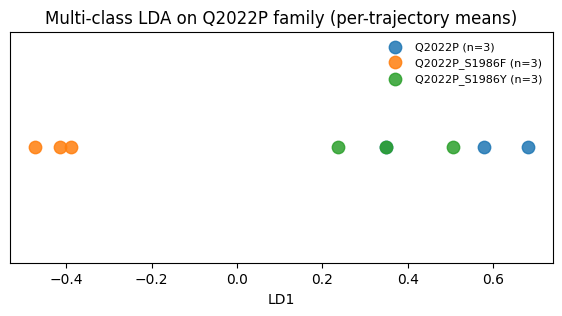


[Q2022P LDA] LD1 weights on PCs:
  PC01: -0.3194
  PC02: +0.5695
  PC03: -0.7574


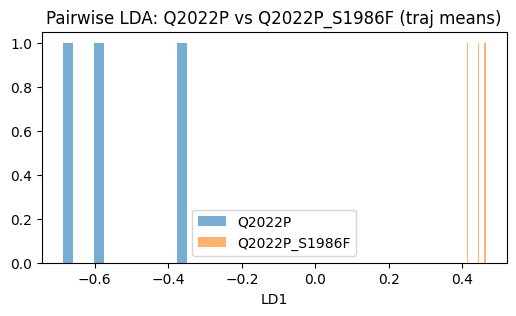


[PAIRWISE LDA] Q2022P vs Q2022P_S1986F
  mean(LD1) A: -0.5434968604510572 | B: 0.43916824679406075
  w (PC weights): [ 0.3708 -0.5559  0.7439]


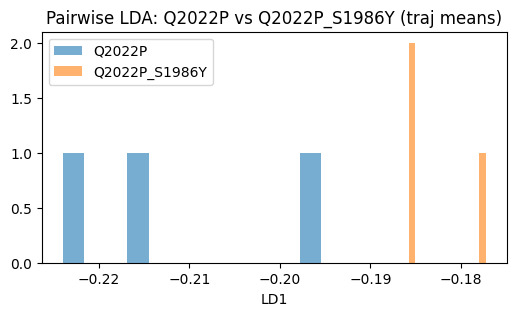


[PAIRWISE LDA] Q2022P vs Q2022P_S1986Y
  mean(LD1) A: -0.2114712050696944 | B: -0.18278475103477976
  w (PC weights): [-0.6341 -0.6709  0.3844]


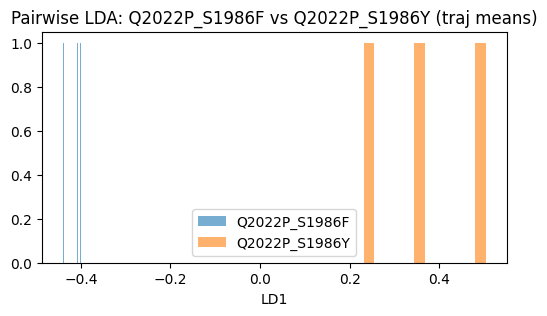


[PAIRWISE LDA] Q2022P_S1986F vs Q2022P_S1986Y
  mean(LD1) A: -0.41606340380524953 | B: 0.366331097186621
  w (PC weights): [-0.3524  0.5373 -0.7663]

[PDB WRITE] Using mean='mean' with loadings='loadings_actout' | atoms=984
[PDB WRITE] mean_xyz: (984, 3) | loadings_use: (2952, 2952) | sel_idx_use: 984


/homes/lkgyammerah/.venvs/ros1_analysis_env/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/homes/lkgyammerah/.venvs/ros1_analysis_env/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1336: UserWarning: Found missing chainIDs. Corresponding atoms will use value of 'X'
  warnings.warn(


[WROTE] LDA_mode_loadings_actout_Q2022P_vs_Q2022P_S1986F.pdb (21 models), alpha=2.0
[WROTE] LDA_mode_loadings_actout_Q2022P_vs_Q2022P_S1986Y.pdb (21 models), alpha=2.0
[WROTE] LDA_mode_loadings_actout_Q2022P_S1986F_vs_Q2022P_S1986Y.pdb (21 models), alpha=2.0


In [56]:
# ============================================================
# LDA using your GLOBAL / WHOLE-KINASE PCA results
# - fixes missing PCA_GLOBAL by building it from variables that exist in YOUR notebook
# - provides:
#   (1) multi-class LDA on Q2022P family (orthogonal discriminant axes)
#   (2) pairwise 2-class LDA for each Q2022P-family pair
#   (3) optional: write LD1 motion PDBs if you have loadings+mean+sele and a template pdb
#
# >>> PASTE THIS RIGHT AFTER YOUR "global/whole kinase PCA" CELL <<<
# ============================================================


# -----------------------------
# 0) Safe helper: find PCA score tensors in your namespace
# -----------------------------
def list_pca_score_tensors(expected_ntraj=None, expected_T=None, min_pc=2):
    cands = []
    for name, obj in list(globals().items()):  # list() avoids "dict changed size during iteration"
        if isinstance(obj, np.ndarray) and obj.ndim == 3:
            a, b, c = obj.shape
            if c >= min_pc:
                ok = True
                if expected_ntraj is not None and a != expected_ntraj:
                    ok = False
                if expected_T is not None and b != expected_T:
                    ok = False
                if ok:
                    cands.append((name, obj.shape))
    return sorted(cands, key=lambda x: x[0])

# -----------------------------
# 1) Figure out ntraj and Tsub from YOUR run (preferred: frame_idx_list)
# -----------------------------
assert "F" in globals(), "F missing. (If F got overwritten, restart kernel and re-run the early setup cells.)"
assert isinstance(F, list), f"F should be a list of paths, got {type(F)}"
assert len(F) > 0, "F is empty"

ntraj = len(F)

# If you are using frame_idx_list everywhere (you are), define Tsub from it:
if "frame_idx_list" in globals() and frame_idx_list is not None:
    Tsub = len(frame_idx_list[0])
else:
    # fallback: try from pscores_flat / scores_flat later
    Tsub = None

print("[LDA setup] ntraj =", ntraj, "| Tsub =", Tsub)

# Show what score tensors you already have (so you know what is selectable)
cands = list_pca_score_tensors(expected_ntraj=ntraj, expected_T=Tsub, min_pc=2)
print("\nMatching PCA score tensors (shape ≈ (ntraj, Tsub, nPC)):")
for name, shp in cands:
    print(" ", f"{name:20s}", "shape=", shp)

# -----------------------------
# 2) Pick the GLOBAL PCA score tensor automatically
# -----------------------------
# In YOUR notebook, the "global/whole kinase orientation" section left you with:
#   - pscores  (sometimes)
#   - scores_orient (sometimes)
# We choose in this priority order if present.
priority = ["pscores", "scores", "scores_global", "scores_kinase", "scores_orient"]

pscores_name = None
for nm in priority:
    if nm in globals() and isinstance(globals()[nm], np.ndarray) and globals()[nm].ndim == 3:
        if globals()[nm].shape[0] == ntraj and (Tsub is None or globals()[nm].shape[1] == Tsub):
            pscores_name = nm
            break

# If none of the priority names matched, fall back to "first candidate"
if pscores_name is None:
    if len(cands) == 0:
        raise RuntimeError(
            "No (ntraj, Tsub, nPC) PCA score tensor found.\n"
            "Make sure you already ran the GLOBAL/whole kinase PCA cell that builds a score tensor."
        )
    pscores_name = cands[0][0]

pscores = globals()[pscores_name]
print("\n[LDA] Using pscores_name =", pscores_name, "| shape =", pscores.shape)

# -----------------------------
# 3) Build PCA_GLOBAL dict from variables that EXIST in your notebook
# -----------------------------
# These names match what your global PCA cell produced in your file:
need_any = ["scores_flat", "pscores_flat", "loadings", "mean"]
missing = [v for v in need_any if v not in globals()]
if missing:
    print("\n[NOTE] These global-PCA variables are missing:", missing)
    print("If you want mode-writing later, you MUST have at least: mean, loadings, sele (or sel_idx).")

PCA_GLOBAL = {
    "pscores": pscores,  # (ntraj, Tsub, nPC)
    "F": F,
}

# add optional pieces if they exist
for k in ["scores_flat", "pscores_flat", "loadings", "mean", "X_owner", "P_owner", "sele", "sel_idx"]:
    if k in globals():
        PCA_GLOBAL[k] = globals()[k]

print("[LDA] PCA_GLOBAL keys:", sorted(PCA_GLOBAL.keys()))

# -----------------------------
# 4) MULTI-CLASS LDA on Q2022P family (orthogonal axes)
# -----------------------------
def lda_multiclass(X, y, eps=1e-8):
    """
    Manual LDA: returns W (k x (C-1)) with orthogonal discriminant axes in LDA space.
    """
    classes = np.unique(y)
    k = X.shape[1]
    means = {c: X[y == c].mean(axis=0, keepdims=True) for c in classes}
    overall_mean = X.mean(axis=0, keepdims=True)

    Sw = np.zeros((k, k), dtype=np.float64)
    for c in classes:
        Xc = X[y == c] - means[c]
        Sw += Xc.T @ Xc

    Sb = np.zeros((k, k), dtype=np.float64)
    for c in classes:
        n_c = (y == c).sum()
        diff = (means[c] - overall_mean)  # (1,k)
        Sb += n_c * (diff.T @ diff)

    Sw_reg = Sw + eps * np.eye(k)
    M = np.linalg.solve(Sw_reg, Sb)
    eigvals, eigvecs = np.linalg.eig(M)
    order = np.argsort(eigvals.real)[::-1]
    eigvals = eigvals.real[order]
    W = eigvecs.real[:, order]
    return W, eigvals

# Build per-trajectory features from PCA scores (avoid frame leakage)
k_use = min(6, pscores.shape[2])   # you can change to 5 if you want
traj_feat = pscores[:, :, :k_use].mean(axis=1)   # (ntraj, k_use)
traj_mut  = np.array([p.split("/")[0] for p in F], dtype=object)

q_family = ["Q2022P", "Q2022P_S1986F", "Q2022P_S1986Y"]
mask_q = np.isin(traj_mut, q_family)

Xq = traj_feat[mask_q]
namesq = traj_mut[mask_q]
uniq_sys = np.unique(namesq)

print("\n[Q2022P LDA] systems in subset:", uniq_sys.tolist())
print("[Q2022P LDA] counts:", {u: int((namesq == u).sum()) for u in uniq_sys})

if uniq_sys.size < 2:
    raise RuntimeError("Q2022P subset has <2 systems in your data. Check naming / F folders.")

label_map = {m: i for i, m in enumerate(uniq_sys)}
yq = np.array([label_map[m] for m in namesq], dtype=int)

W, evals = lda_multiclass(Xq, yq, eps=1e-8)
ndim = min(len(uniq_sys) - 1, k_use)
Z = Xq @ W[:, :ndim]

print("[Q2022P LDA] top eigenvalues:", np.round(evals[:min(5, len(evals))], 6))

# Plot LD1 (points along x-axis)
plt.figure(figsize=(7, 3))
for m in uniq_sys:
    c = label_map[m]
    zz = Z[yq == c, 0]
    plt.scatter(zz, np.zeros_like(zz), s=80, alpha=0.85, label=f"{m} (n={zz.size})")
plt.xlabel("LD1")
plt.yticks([])
plt.title("Multi-class LDA on Q2022P family (per-trajectory means)")
plt.legend(fontsize=8, frameon=False)
plt.show()

print("\n[Q2022P LDA] LD1 weights on PCs:")
for i, val in enumerate(W[:k_use, 0]):
    print(f"  PC{i+1:02d}: {val:+.4f}")

# -----------------------------
# 5) Pairwise 2-class LDA for Q2022P family (pairwise best separators)
# -----------------------------
def lda_2class_direction(X, y01, eps=1e-10):
    X0 = X[y01 == 0]
    X1 = X[y01 == 1]
    m0 = X0.mean(axis=0)
    m1 = X1.mean(axis=0)
    Sw = (X0 - m0).T @ (X0 - m0) + (X1 - m1).T @ (X1 - m1)
    Sw = Sw + eps * np.eye(X.shape[1])
    w = np.linalg.solve(Sw, (m1 - m0))
    w = w / (np.linalg.norm(w) + 1e-12)
    return w

pairs = [
    ("Q2022P", "Q2022P_S1986F"),
    ("Q2022P", "Q2022P_S1986Y"),
    ("Q2022P_S1986F", "Q2022P_S1986Y"),
]

pairwise_results = {}

for A, B in pairs:
    pair_mask = np.isin(namesq, [A, B])
    Xpair = Xq[pair_mask]
    npair = namesq[pair_mask]
    y01 = (npair == B).astype(int)  # 0=A, 1=B

    if (y01 == 0).sum() < 2 or (y01 == 1).sum() < 2:
        print(f"\n[PAIRWISE LDA] Skipping {A} vs {B} (need >=2 samples per class)")
        continue

    w = lda_2class_direction(Xpair, y01)
    ld1 = Xpair @ w

    pairwise_results[(A, B)] = {"w": w, "ld1": ld1, "y01": y01}

    plt.figure(figsize=(6, 3))
    plt.hist(ld1[y01 == 0], bins=12, alpha=0.6, label=A)
    plt.hist(ld1[y01 == 1], bins=12, alpha=0.6, label=B)
    plt.title(f"Pairwise LDA: {A} vs {B} (traj means)")
    plt.xlabel("LD1")
    plt.legend()
    plt.show()

    print(f"\n[PAIRWISE LDA] {A} vs {B}")
    print("  mean(LD1) A:", float(ld1[y01==0].mean()), "| B:", float(ld1[y01==1].mean()))
    print("  w (PC weights):", np.round(w, 4))



# -----------------------------
# 6) OPTIONAL: write discriminant axis motion as a multi-model PDB
#     Uses matched (mean, loadings) pairs from your scan
# -----------------------------
def write_mode_movie_pdb(template_pdb, sel_idx, mean_xyz, mode_xyz, out_pdb, alpha=2.0, nsteps=21):
    import numpy as np
    import MDAnalysis as mda

    u = mda.Universe(template_pdb)
    ag = u.atoms[sel_idx]

    mean_xyz = np.asarray(mean_xyz).reshape(-1, 3)
    mode_xyz = np.asarray(mode_xyz).reshape(-1, 3)

    # normalize mode (avoid crazy scaling)
    mode_xyz = mode_xyz / (np.linalg.norm(mode_xyz) + 1e-12)

    tvals = np.linspace(-1, 1, nsteps)
    with mda.Writer(out_pdb, ag.n_atoms, multiframe=True) as W:
        for t in tvals:
            ag.positions = mean_xyz + (t * alpha) * mode_xyz
            W.write(ag)

    print(f"[WROTE] {out_pdb} ({nsteps} models), alpha={alpha}")


# ------------------------------------------------------------
# FIX: choose a matched (mean, loadings) pair automatically
# based on SAME atom count (from your scan results)
# ------------------------------------------------------------
def _atoms_from_mean(obj):
    obj = np.asarray(obj)
    if obj.ndim == 2 and obj.shape[1] == 3:
        return obj.shape[0]
    if obj.ndim == 1 and obj.size % 3 == 0:
        return obj.size // 3
    return None

def _atoms_from_loadings(obj):
    obj = np.asarray(obj)
    if obj.ndim == 2 and obj.shape[0] % 3 == 0:
        return obj.shape[0] // 3
    return None


# ---- Candidate variables that exist in YOUR notebook ----
mean_candidates = []
for nm in ["mean", "mean_xyz", "mean_vec", "mean_actout", "mean_ctl", "mean_loop"]:
    if nm in globals():
        nA = _atoms_from_mean(globals()[nm])
        if nA is not None:
            mean_candidates.append((nm, nA))

load_candidates = []
for nm in ["loadings_actout", "loadings_ctl", "loadings"]:
    if nm in globals():
        nA = _atoms_from_loadings(globals()[nm])
        if nA is not None:
            load_candidates.append((nm, nA))

# ---- Prefer WHOLE-KINASE size (984 atoms) if available ----
# (From your scan: mean <-> loadings_actout is the right global pair)
preferred_atoms = [984, 862, 84]  # try global first, then ctl, then loop

picked = None
for target in preferred_atoms:
    m_ok = [m for m in mean_candidates if m[1] == target]
    l_ok = [l for l in load_candidates if l[1] == target]
    if m_ok and l_ok:
        # pick the nicest names if present
        # mean: prefer "mean" then "mean_xyz" then anything
        m_ok.sort(key=lambda x: (x[0] != "mean", x[0] != "mean_xyz", x[0]))
        # loadings: prefer loadings_actout then loadings_ctl then loadings
        l_ok.sort(key=lambda x: (x[0] != "loadings_actout", x[0] != "loadings_ctl", x[0] != "loadings", x[0]))
        picked = (m_ok[0][0], l_ok[0][0], target)
        break

if picked is None:
    print("\n[NOTE] Skipping PDB mode writing: no matched mean+loadings pair found.")
    print("Mean candidates:", mean_candidates)
    print("Loadings candidates:", load_candidates)
else:
    mean_name, load_name, n_atoms_used = picked
    mean_obj = np.asarray(globals()[mean_name])
    loadings_use = np.asarray(globals()[load_name])

    # reshape mean to (n_atoms,3)
    if mean_obj.ndim == 1:
        mean_xyz = mean_obj.reshape(n_atoms_used, 3)
    else:
        mean_xyz = mean_obj.reshape(n_atoms_used, 3)

    # ---- selection indices for writing must match n_atoms_used ----
    # If you have sel_idx that matches, use it; otherwise fallback to first n_atoms_used atoms.
    if "sel_idx" in globals() and np.asarray(sel_idx).size == n_atoms_used:
        sel_idx_use = np.asarray(sel_idx, dtype=int)
    elif "sele" in globals() and np.where(sele)[0].size == n_atoms_used:
        sel_idx_use = np.where(sele)[0].astype(int)
    else:
        sel_idx_use = np.arange(n_atoms_used, dtype=int)

    print(f"\n[PDB WRITE] Using mean='{mean_name}' with loadings='{load_name}' | atoms={n_atoms_used}")
    print("[PDB WRITE] mean_xyz:", mean_xyz.shape, "| loadings_use:", loadings_use.shape, "| sel_idx_use:", sel_idx_use.size)

    template_pdb = f"{F[0]}/md-prot.pdb"

    # ---- write modes for each pairwise LDA ----
    for (A, B), R in pairwise_results.items():
        w_pair = R["w"]  # (k_use,)

        # PC-space direction -> atomic motion in PCA selection space
        mode_atomic = (loadings_use[:, :k_use] @ w_pair).reshape(n_atoms_used, 3)

        out = f"LDA_mode_{load_name}_{A}_vs_{B}.pdb"
        write_mode_movie_pdb(template_pdb, sel_idx_use, mean_xyz, mode_atomic,
                             out_pdb=out, alpha=2.0, nsteps=21)




In [57]:
# Projecting all frames onto LDA direction(s) learned from trajectory means
# & Show distribution overlap of conformations (frame-level)
assert "pscores" in globals() and isinstance(pscores, np.ndarray) and pscores.ndim == 3
assert "F" in globals() and isinstance(F, list)
assert "k_use" in globals()

ntraj, Tsub, nPC = pscores.shape
traj_mut = np.array([p.split("/")[0] for p in F], dtype=object)

q_family = ["Q2022P", "Q2022P_S1986F", "Q2022P_S1986Y"]
mask_q = np.isin(traj_mut, q_family)

if mask_q.sum() == 0:
    raise RuntimeError("No Q2022P-family trajectories found. Check traj_mut names.")

# Frame-level PCA features (same PCs used in LDA)
X_frames_q = pscores[mask_q, :, :k_use]          # (nq_traj, Tsub, k_use)
names_q    = traj_mut[mask_q]                    # (nq_traj,)
uniq_sys   = np.unique(names_q)

print("[Frames] Q-family trajectories:", X_frames_q.shape[0], "frames per traj:", Tsub, "k_use:", k_use)
print("[Frames] Systems:", uniq_sys.tolist())


[Frames] Q-family trajectories: 9 frames per traj: 696 k_use: 3
[Frames] Systems: ['Q2022P', 'Q2022P_S1986F', 'Q2022P_S1986Y']


In [58]:
# -----------------------------
# Helper metrics: separation vs variability
# -----------------------------
def cohens_d(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    sa = a.std(ddof=1) + 1e-12
    sb = b.std(ddof=1) + 1e-12
    sp = np.sqrt(((len(a)-1)*sa*sa + (len(b)-1)*sb*sb) / (len(a)+len(b)-2) + 1e-12)
    return (a.mean() - b.mean()) / sp

def summarize_pair(A, B, ld1_frames, names_pair):
    # ld1_frames: (ntraj_pair, Tsub)
    # names_pair: (ntraj_pair,) with entries A or B
    a = ld1_frames[names_pair == A].ravel()
    b = ld1_frames[names_pair == B].ravel()

    # "means separable" vs "distributions overlap"
    d = cohens_d(a, b)

    # within-trajectory variability (average std across trajectories)
    stdA = ld1_frames[names_pair == A].std(axis=1).mean()
    stdB = ld1_frames[names_pair == B].std(axis=1).mean()

    # between-system separation (difference of frame-means)
    sep = abs(a.mean() - b.mean())
    within = 0.5 * (stdA + stdB) + 1e-12
    ratio = sep / within

    return {
        "cohens_d": float(d),
        "sep_over_within": float(ratio),
        "meanA": float(a.mean()),
        "meanB": float(b.mean()),
        "stdA_within_traj": float(stdA),
        "stdB_within_traj": float(stdB),
        "nframesA": int(a.size),
        "nframesB": int(b.size),
    }

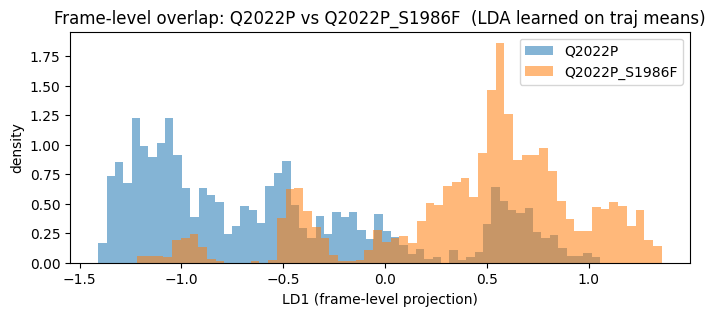


[VAR vs SEP] Q2022P vs Q2022P_S1986F
  frame mean(A), mean(B): -0.5435 0.4392
  within-traj std(A), std(B): 0.6053 0.5075
  separation / within: 1.766   (bigger = cleaner separation)
  Cohen's d: -1.621


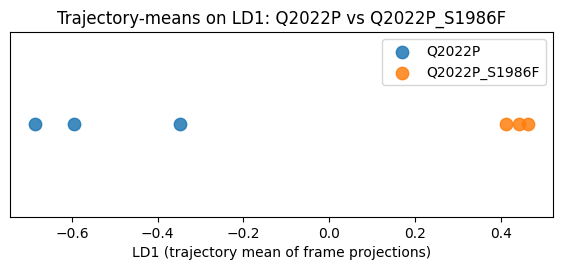

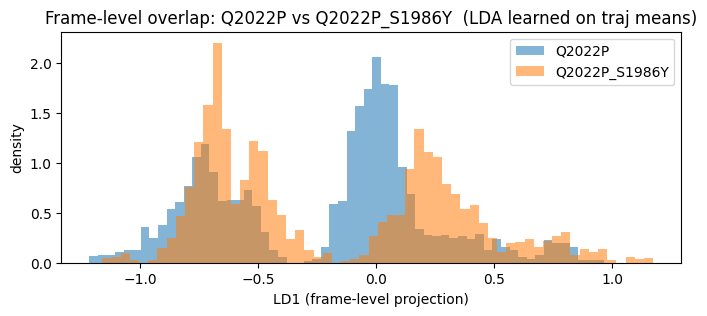


[VAR vs SEP] Q2022P vs Q2022P_S1986Y
  frame mean(A), mean(B): -0.2115 -0.1828
  within-traj std(A), std(B): 0.4475 0.5185
  separation / within: 0.059   (bigger = cleaner separation)
  Cohen's d: -0.059


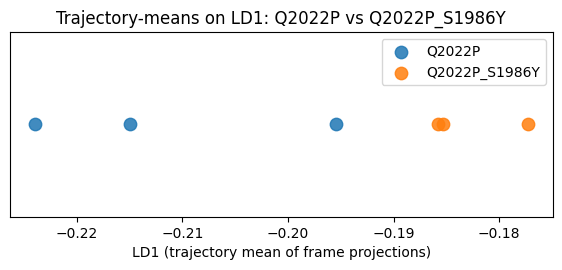

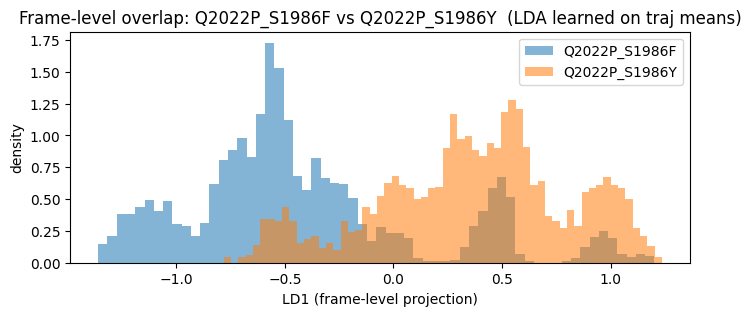


[VAR vs SEP] Q2022P_S1986F vs Q2022P_S1986Y
  frame mean(A), mean(B): -0.4161 0.3663
  within-traj std(A), std(B): 0.5076 0.4064
  separation / within: 1.712   (bigger = cleaner separation)
  Cohen's d: -1.581


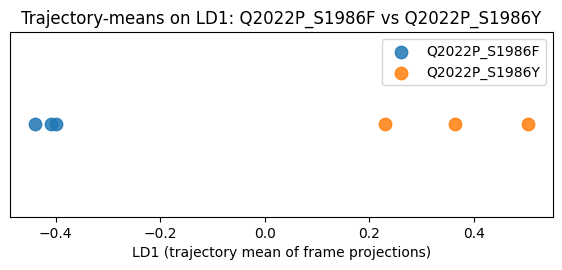

In [59]:
# ============================================================
# (A) Pairwise LDA — project ALL frames onto the pairwise direction
# ============================================================
assert "pairwise_results" in globals(), "pairwise_results missing. Run your pairwise LDA first."

for (A, B), R in pairwise_results.items():
    w = np.asarray(R["w"], float)  # (k_use,)
    if w.shape[0] != k_use:
        print(f"[WARN] {A} vs {B}: w has len={w.shape[0]} but k_use={k_use}. Skipping.")
        continue

    pair_mask = np.isin(names_q, [A, B])
    Xp = X_frames_q[pair_mask]     # (ntraj_pair, Tsub, k_use)
    npair = names_q[pair_mask]

    # ---- Step 2: frame projections ----
    # ld1_frames shape: (ntraj_pair, Tsub)
    ld1_frames = np.tensordot(Xp, w, axes=([2],[0]))

    # ---- Step 3: overlap distribution of conformations ----
    plt.figure(figsize=(8, 3))
    plt.hist(ld1_frames[npair == A].ravel(), bins=60, alpha=0.55, label=A, density=True)
    plt.hist(ld1_frames[npair == B].ravel(), bins=60, alpha=0.55, label=B, density=True)
    plt.xlabel("LD1 (frame-level projection)")
    plt.ylabel("density")
    plt.title(f"Frame-level overlap: {A} vs {B}  (LDA learned on traj means)")
    plt.legend()
    plt.show()

    # ---- Variability vs separation check (Tsjerk point) ----
    stats = summarize_pair(A, B, ld1_frames, npair)
    print(f"\n[VAR vs SEP] {A} vs {B}")
    print("  frame mean(A), mean(B):", round(stats["meanA"], 4), round(stats["meanB"], 4))
    print("  within-traj std(A), std(B):", round(stats["stdA_within_traj"], 4), round(stats["stdB_within_traj"], 4))
    print("  separation / within:", round(stats["sep_over_within"], 3), "  (bigger = cleaner separation)")
    print("  Cohen's d:", round(stats["cohens_d"], 3))

    # Optional: show traj means on the same axis (why “means separable”)
    traj_means = ld1_frames.mean(axis=1)
    plt.figure(figsize=(7, 2.4))
    plt.scatter(traj_means[npair == A], np.zeros_like(traj_means[npair == A]), s=80, alpha=0.85, label=A)
    plt.scatter(traj_means[npair == B], np.zeros_like(traj_means[npair == B]), s=80, alpha=0.85, label=B)
    plt.xlabel("LD1 (trajectory mean of frame projections)")
    plt.yticks([])
    plt.title(f"Trajectory-means on LD1: {A} vs {B}")
    plt.legend()
    plt.show()


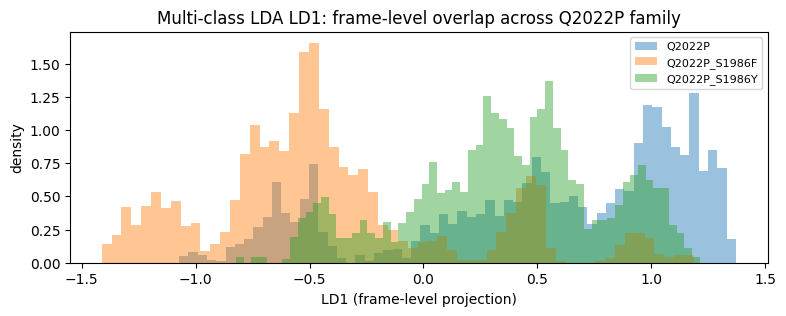

In [60]:
# ============================================================
# (B) Multi-class LDA — OPTIONAL frame-level projection onto LD1
#     This uses orthogonal discriminant axes.
# ============================================================
if "W" in globals():
    W_use = np.asarray(W, float)
    if W_use.shape[0] >= k_use:
        # Use LD1 from multi-class solution
        w_mc = W_use[:k_use, 0]
        w_mc = w_mc / (np.linalg.norm(w_mc) + 1e-12)

        ld1_mc_frames = np.tensordot(X_frames_q, w_mc, axes=([2],[0]))  # (nq_traj, Tsub)

        plt.figure(figsize=(9, 3))
        for sys in uniq_sys:
            plt.hist(ld1_mc_frames[names_q == sys].ravel(), bins=60, alpha=0.45, density=True, label=sys)
        plt.xlabel("LD1 (frame-level projection)")
        plt.ylabel("density")
        plt.title("Multi-class LDA LD1: frame-level overlap across Q2022P family")
        plt.legend(fontsize=8)
        plt.show()
    else:
        print("[NOTE] W exists but shape doesn't match k_use; skipping multi-class frame projection.")
else:
    print("[NOTE] Multi-class W not found in globals; skipping multi-class frame projection.")

[ALIAS] A-loop present but sizes mismatch: mean_atoms=104, load_atoms=84, sel_idx=104
[OK] Using pscores shape=(117, 696, 3), k_use=3


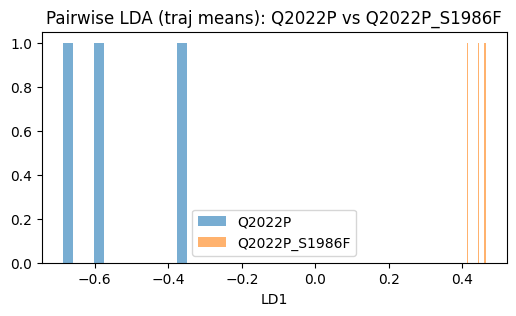

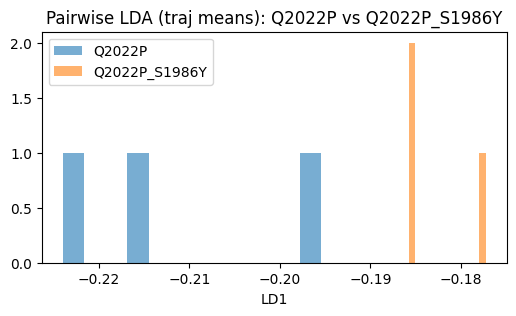

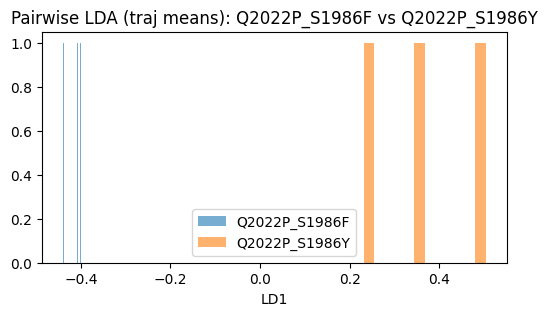


[PAIRWISE READY] keys: [('Q2022P', 'Q2022P_S1986F'), ('Q2022P', 'Q2022P_S1986Y'), ('Q2022P_S1986F', 'Q2022P_S1986Y')]
[Step 2] built frame projections for: [('Q2022P', 'Q2022P_S1986F'), ('Q2022P', 'Q2022P_S1986Y'), ('Q2022P_S1986F', 'Q2022P_S1986Y')]


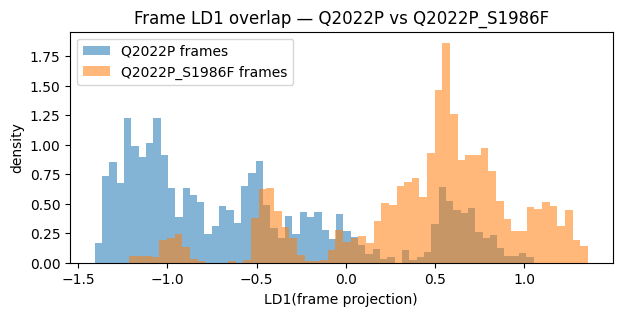

[Q2022P vs Q2022P_S1986F] |meanA-meanB|=0.983 ; avg within-std=0.603 ; Cohen's d=-1.62


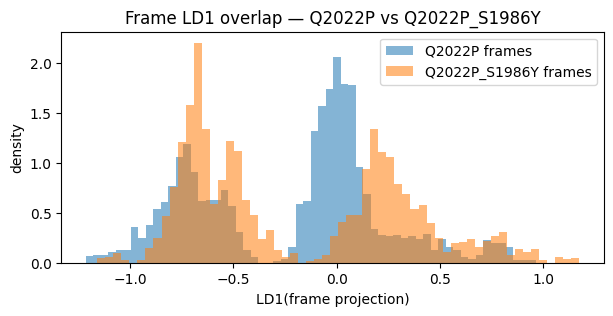

[Q2022P vs Q2022P_S1986Y] |meanA-meanB|=0.0287 ; avg within-std=0.486 ; Cohen's d=-0.0588


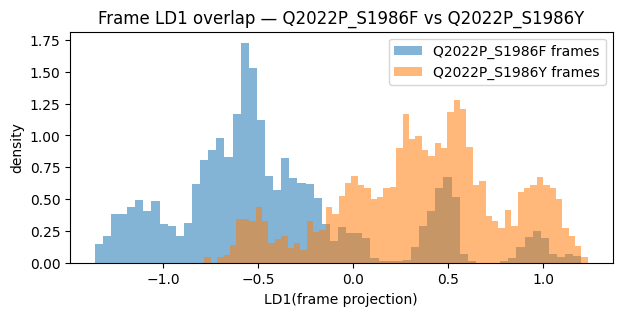

[Q2022P_S1986F vs Q2022P_S1986Y] |meanA-meanB|=0.782 ; avg within-std=0.492 ; Cohen's d=-1.58
[WROTE] GLOBAL_KINASE_PC01.pdb  (n_atoms=984)
[WROTE] GLOBAL_KINASE_PC02.pdb  (n_atoms=984)
[WROTE] GLOBAL_KINASE_PC03.pdb  (n_atoms=984)
[WROTE] GLOBAL_KINASE_PC04.pdb  (n_atoms=984)
[WROTE] GLOBAL_KINASE_PC05.pdb  (n_atoms=984)
[BRIDGE] sel_idx_loop created from loop_BB size= 84
[WROTE] TYR_LOOP_PC01.pdb  (n_atoms=84)
[WROTE] TYR_LOOP_PC02.pdb  (n_atoms=84)
[WROTE] TYR_LOOP_PC03.pdb  (n_atoms=84)
[WROTE] TYR_LOOP_PC04.pdb  (n_atoms=84)
[WROTE] TYR_LOOP_PC05.pdb  (n_atoms=84)
[WROTE] ACT_LOOP_PC01.pdb  (n_atoms=104)
[WROTE] ACT_LOOP_PC02.pdb  (n_atoms=104)
[WROTE] ACT_LOOP_PC03.pdb  (n_atoms=104)
[WROTE] ACT_LOOP_PC04.pdb  (n_atoms=104)
[WROTE] ACT_LOOP_PC05.pdb  (n_atoms=104)
[WROTE] GLOBAL_KINASE_LDA_Q2022P_vs_Q2022P_S1986F.pdb  (n_atoms=984)
[WROTE] GLOBAL_KINASE_LDA_Q2022P_vs_Q2022P_S1986Y.pdb  (n_atoms=984)
[WROTE] GLOBAL_KINASE_LDA_Q2022P_S1986F_vs_Q2022P_S1986Y.pdb  (n_atoms=984)

DONE

In [61]:
# ============================================================
# ONE-BLOCK: LDA Step 1/2/3 + Write ALL PCA/LD motions to PDB
# - Rebuilds pairwise LDA if missing
# - Projects ALL FRAMES onto LD1 (Step 2)
# - Overlap + separation-vs-variability stats (Step 3)
# - Writes PCA PC motions + LDA LD1 motions where possible
# ============================================================

# -------------------------
# (0) Helpers: robust lookup
# -------------------------
def _as_mean_xyz(mean_obj, n_atoms):
    """Return mean as (n_atoms,3). mean_obj can be (n_atoms,3) or (3*n_atoms,)."""
    M = np.asarray(mean_obj)
    if M.ndim == 2 and M.shape == (n_atoms, 3):
        return M.astype(float)
    if M.ndim == 1 and M.size == 3 * n_atoms:
        return M.reshape(n_atoms, 3).astype(float)
    raise ValueError(f"Mean has shape {M.shape}, not compatible with n_atoms={n_atoms}")

def _infer_n_atoms_from_loadings(L):
    """Loadings for coordinate PCA must be (3*n_atoms, nPC or 3*n_atoms)."""
    L = np.asarray(L)
    if L.ndim != 2 or (L.shape[0] % 3 != 0):
        raise ValueError(f"Loadings shape {L.shape} not xyz-style (rows not divisible by 3)")
    return L.shape[0] // 3

def _mean_atom_count(obj):
    obj = np.asarray(obj)
    if obj.ndim == 2 and obj.shape[1] == 3:
        return obj.shape[0]
    if obj.ndim == 1 and obj.size % 3 == 0:
        return obj.size // 3
    return None

def _find_matching_mean_loadings_pair(target_atoms):
    """
    Search globals for mean_* and loadings_* that match target_atoms.
    Returns (mean_name, loadings_name) or (None,None).
    """
    mean_cands = []
    load_cands = []

    for name, obj in list(globals().items()):
        if isinstance(obj, np.ndarray):
            if name.startswith("mean"):
                atoms = _mean_atom_count(obj)
                if atoms is not None:
                    mean_cands.append((name, atoms))

            if name.startswith("loadings"):
                try:
                    atoms = _infer_n_atoms_from_loadings(obj)
                    load_cands.append((name, atoms))
                except Exception:
                    pass

    means = [m for m in mean_cands if m[1] == target_atoms]
    loads = [l for l in load_cands if l[1] == target_atoms]
    if len(means) == 0 or len(loads) == 0:
        return None, None

    mean_priority = ["mean_actout", "mean", "mean_loop", "mean_act", "mean_obj", "mean_xyz", "mean_act_vec"]
    load_priority = ["loadings_actout", "loadings_use", "loadings_act", "loadings"]

    def _pick(pref, items):
        names = [x[0] for x in items]
        for p in pref:
            if p in names:
                return p
        return items[0][0]

    return _pick(mean_priority, means), _pick(load_priority, loads)

def _get_sel_idx_from_mask(mask):
    mask = np.asarray(mask).astype(bool)
    return np.where(mask)[0].astype(int)

def _resolve_sel_idx(n_atoms, sel_idx_name=None, sele_name=None):
    """
    Resolve an atom index list of length n_atoms.
    Priority:
      1) explicit sel_idx_name
      2) explicit sele_name (boolean mask)
      3) common globals
    """
    if sel_idx_name is not None and sel_idx_name in globals():
        idx = np.asarray(globals()[sel_idx_name]).astype(int)
        if idx.size == n_atoms:
            return idx
        raise ValueError(f"{sel_idx_name} has size {idx.size}, expected {n_atoms}")

    if sele_name is not None and sele_name in globals():
        idx = _get_sel_idx_from_mask(globals()[sele_name])
        if idx.size == n_atoms:
            return idx
        raise ValueError(f"{sele_name} -> sel_idx has size {idx.size}, expected {n_atoms}")

    for nm in ["sel_idx_loop", "sel_idx_actout", "sel_idx_act", "sel_idx_global", "sel_idx"]:
        if nm in globals():
            idx = np.asarray(globals()[nm]).astype(int)
            if idx.size == n_atoms:
                return idx

    for nm in ["sele_actout", "sele_act", "sele", "sele_loop"]:
        if nm in globals():
            idx = _get_sel_idx_from_mask(globals()[nm])
            if idx.size == n_atoms:
                return idx

    return None

# -------------------------
# (1) Write motion PDB (multi-model) from mean + mode
# -------------------------
def write_mode_movie_pdb(template_pdb, sel_idx, mean_xyz, mode_xyz, out_pdb, alpha=2.0, nsteps=21):
    import MDAnalysis as mda
    mean_xyz = np.asarray(mean_xyz, float).reshape(-1, 3)
    mode_xyz = np.asarray(mode_xyz, float).reshape(-1, 3)

    u = mda.Universe(template_pdb)
    ag = u.atoms[sel_idx]

    mode_xyz = mode_xyz / (np.linalg.norm(mode_xyz) + 1e-12)

    tvals = np.linspace(-1, 1, nsteps)
    with mda.Writer(out_pdb, ag.n_atoms, multiframe=True) as W:
        for t in tvals:
            ag.positions = mean_xyz + (t * alpha) * mode_xyz
            W.write(ag)

    print(f"[WROTE] {out_pdb}  (n_atoms={ag.n_atoms})")

def write_pc_motions(tag, mean_name, loadings_name, pcs=(1,2,3,4,5), alpha=2.0, nsteps=21,
                     template_pdb=None, sel_idx_name=None, sele_name=None):
    if template_pdb is None:
        template_pdb = f"{F[0]}/md-prot.pdb"

    L = np.asarray(globals()[loadings_name])
    n_atoms = _infer_n_atoms_from_loadings(L)

    mean_xyz = _as_mean_xyz(globals()[mean_name], n_atoms)

    sel_idx = _resolve_sel_idx(n_atoms, sel_idx_name=sel_idx_name, sele_name=sele_name)
    if sel_idx is None:
        raise RuntimeError(f"No sel_idx/sele found with size {n_atoms} for tag={tag}")

    for pc in pcs:
        pc0 = pc - 1
        if pc0 < 0 or pc0 >= L.shape[1]:
            print(f"[SKIP] {tag}: PC{pc} out of range for loadings {loadings_name} shape={L.shape}")
            continue
        mode = L[:, pc0].reshape(n_atoms, 3)
        out = f"{tag}_PC{pc:02d}.pdb"
        write_mode_movie_pdb(template_pdb, sel_idx, mean_xyz, mode, out_pdb=out, alpha=alpha, nsteps=nsteps)

# -------------------------
# (2)  2-class LDA direction
# -------------------------
def lda_2class_w(X, y01, eps=1e-10):
    X0 = X[y01 == 0]; X1 = X[y01 == 1]
    m0 = X0.mean(axis=0); m1 = X1.mean(axis=0)
    Sw = (X0 - m0).T @ (X0 - m0) + (X1 - m1).T @ (X1 - m1)
    Sw = Sw + eps * np.eye(X.shape[1])
    w = np.linalg.solve(Sw, (m1 - m0))
    return w / (np.linalg.norm(w) + 1e-12)

def cohens_d(a, b):
    a = np.asarray(a); b = np.asarray(b)
    ma, mb = a.mean(), b.mean()
    va, vb = a.var(ddof=1), b.var(ddof=1)
    sp = np.sqrt(0.5 * (va + vb) + 1e-12)
    return (ma - mb) / sp

# ============================================================
# FIX INSERTED HERE:
# If you just ran your A-loop PCA cell, it likely created:
#   mean_act   (n_atoms,3)
#   loadings   (3*n_atoms, ...)
#   sel_idx    (n_atoms,)
# We alias them so ACT_LOOP can be written without extra cells.
# ============================================================
if ("mean_act" in globals()) and ("loadings" in globals()) and ("sel_idx" in globals()):
    try:
        n_mean = _mean_atom_count(globals()["mean_act"])
        n_load = _infer_n_atoms_from_loadings(globals()["loadings"])
        n_sel  = np.asarray(globals()["sel_idx"]).size

        if (n_mean is not None) and (n_mean == n_load) and (n_sel == n_mean):
            globals()["mean_act_vec"] = np.asarray(globals()["mean_act"])
            globals()["loadings_act"] = np.asarray(globals()["loadings"])
            globals()["sel_idx_act"]  = np.asarray(globals()["sel_idx"]).astype(int)
            print(f"[ALIAS] A-loop PCA captured ✅ atoms={n_mean} -> mean_act_vec/loadings_act/sel_idx_act")
        else:
            print(f"[ALIAS] A-loop present but sizes mismatch: mean_atoms={n_mean}, load_atoms={n_load}, sel_idx={n_sel}")
    except Exception as e:
        print("[ALIAS] A-loop aliasing skipped:", repr(e))

# -------------------------
# (3) Pick GLOBAL score tensor for LDA projections
# -------------------------
assert "F" in globals() and isinstance(F, list) and isinstance(F[0], str), "F is corrupted (must be list of strings)"
if "pscores" in globals() and isinstance(pscores, np.ndarray) and pscores.ndim == 3:
    PS = pscores; ps_name = "pscores"
elif "scores_orient" in globals() and isinstance(scores_orient, np.ndarray) and scores_orient.ndim == 3:
    PS = scores_orient; ps_name = "scores_orient"
else:
    raise NameError("Need a GLOBAL PCA score tensor: `pscores` or `scores_orient` shaped (ntraj,Tsub,nPC).")

ntraj, Tsub, nPC = PS.shape
traj_mut = np.array([p.split("/")[0] for p in F], dtype=object)

k_use = min(6, nPC)
X_traj = PS[:, :, :k_use].mean(axis=1)

print(f"[OK] Using {ps_name} shape={PS.shape}, k_use={k_use}")

# -------------------------
# (4) Build pairwise LDA on Q2022P family
# -------------------------
q_family = ["Q2022P", "Q2022P_S1986F", "Q2022P_S1986Y"]
mask_q = np.isin(traj_mut, q_family)

Xq = X_traj[mask_q]
namesq = traj_mut[mask_q]

pairs = [
    ("Q2022P", "Q2022P_S1986F"),
    ("Q2022P", "Q2022P_S1986Y"),
    ("Q2022P_S1986F", "Q2022P_S1986Y"),
]

pairwise = {}
for A, B in pairs:
    pm = np.isin(namesq, [A, B])
    Xp = Xq[pm]
    npair = namesq[pm]
    y01 = (npair == B).astype(int)
    if (y01 == 0).sum() < 2 or (y01 == 1).sum() < 2:
        print(f"[SKIP] {A} vs {B}: need >=2 traj per class")
        continue
    w = lda_2class_w(Xp, y01)
    ld1_traj = Xp @ w
    pairwise[(A, B)] = dict(w=w, ld1_traj=ld1_traj, y01=y01, names=npair)

    plt.figure(figsize=(6, 3))
    plt.hist(ld1_traj[y01 == 0], bins=12, alpha=0.6, label=A)
    plt.hist(ld1_traj[y01 == 1], bins=12, alpha=0.6, label=B)
    plt.title(f"Pairwise LDA (traj means): {A} vs {B}")
    plt.xlabel("LD1"); plt.legend()
    plt.show()

print("\n[PAIRWISE READY] keys:", list(pairwise.keys()))

# -------------------------
# (5) Step 2: project ALL FRAMES onto each pairwise LD1
# -------------------------
PS_q = PS[mask_q, :, :k_use]
names_q_all = traj_mut[mask_q]

frame_proj = {}
for (A, B), R in pairwise.items():
    w = R["w"]
    keep = np.isin(names_q_all, [A, B])
    PS_pair = PS_q[keep]
    nm_pair = names_q_all[keep]
    ld1_frames = np.tensordot(PS_pair, w, axes=([2], [0]))
    frame_proj[(A, B)] = dict(ld1_frames=ld1_frames, names=nm_pair)

print("[Step 2] built frame projections for:", list(frame_proj.keys()))

# -------------------------
# (6) Step 3: overlap + separation-vs-variability metrics
# -------------------------
for (A, B), R in frame_proj.items():
    ld = R["ld1_frames"]
    nm = R["names"]

    a_vals = ld[nm == A].ravel()
    b_vals = ld[nm == B].ravel()

    plt.figure(figsize=(7, 3))
    plt.hist(a_vals, bins=60, alpha=0.55, density=True, label=f"{A} frames")
    plt.hist(b_vals, bins=60, alpha=0.55, density=True, label=f"{B} frames")
    plt.title(f"Frame LD1 overlap — {A} vs {B}")
    plt.xlabel("LD1(frame projection)")
    plt.ylabel("density")
    plt.legend()
    plt.show()

    d = cohens_d(a_vals, b_vals)
    sep = abs(a_vals.mean() - b_vals.mean())
    within = 0.5 * (a_vals.std() + b_vals.std())
    print(f"[{A} vs {B}] |meanA-meanB|={sep:.3g} ; avg within-std={within:.3g} ; Cohen's d={d:.3g}")

# -------------------------
# (7) WRITE PCA motions
# -------------------------
template_pdb = f"{F[0]}/md-prot.pdb"

# GLOBAL_KINASE
if "mean" in globals() and "loadings_actout" in globals() and "sele_actout" in globals():
    try:
        write_pc_motions(
            tag="GLOBAL_KINASE",
            mean_name="mean",
            loadings_name="loadings_actout",
            pcs=(1,2,3,4,5),
            alpha=2.0,
            nsteps=21,
            template_pdb=template_pdb,
            sele_name="sele_actout",
        )
    except Exception as e:
        print("[GLOBAL_KINASE] write failed:", repr(e))
else:
    print("[GLOBAL_KINASE] missing one of: mean, loadings_actout, sele_actout")

# TYR_LOOP
if "mean_loop" in globals() and "loadings" in globals():
    n_atoms_loop = _infer_n_atoms_from_loadings(globals()["loadings"])

    # ============================
    # FIX ADDED HERE (ONLY THIS)
    # Bridge sel_idx_loop from loop_BB if missing
    # ============================
    if "sel_idx_loop" not in globals():
        if "loop_BB" in globals():
            try:
                idx = np.where(np.asarray(loop_BB).astype(bool))[0].astype(int)
                if idx.size == n_atoms_loop:
                    globals()["sel_idx_loop"] = idx
                    print("[BRIDGE] sel_idx_loop created from loop_BB size=", idx.size)
            except Exception as e:
                print("[BRIDGE] sel_idx_loop bridge failed:", repr(e))

    if "sel_idx_loop" in globals():
        try:
            write_pc_motions(
                tag="TYR_LOOP",
                mean_name="mean_loop",
                loadings_name="loadings",
                pcs=(1,2,3,4,5),
                alpha=2.0,
                nsteps=21,
                template_pdb=template_pdb,
                sel_idx_name="sel_idx_loop",
            )
        except Exception as e:
            print("[TYR_LOOP] write failed:", repr(e))
    else:
        print("[TYR_LOOP] missing sel_idx_loop (must have size 84).")
else:
    print("[TYR_LOOP] missing mean_loop or loadings")


# ACT_LOOP (NOW uses the aliases we created)
if ("mean_act_vec" in globals()) and ("loadings_act" in globals()) and ("sel_idx_act" in globals()):
    try:
        write_pc_motions(
            tag="ACT_LOOP",
            mean_name="mean_act_vec",
            loadings_name="loadings_act",
            pcs=(1,2,3,4,5),
            alpha=2.0,
            nsteps=21,
            template_pdb=template_pdb,
            sel_idx_name="sel_idx_act",
        )
    except Exception as e:
        print("[ACT_LOOP] write failed:", repr(e))
else:
    print("[ACT_LOOP] missing one of: mean_act_vec, loadings_act, sel_idx_act (did you run A-loop PCA cell first?)")

# -------------------------
# (8) WRITE LDA motions (GLOBAL)
# -------------------------
if "mean" in globals() and "loadings_actout" in globals() and "sele_actout" in globals():
    try:
        Lg = np.asarray(loadings_actout)
        n_atoms_g = _infer_n_atoms_from_loadings(Lg)
        mean_xyz_g = _as_mean_xyz(mean, n_atoms_g)
        sel_idx_g = _get_sel_idx_from_mask(sele_actout)

        if sel_idx_g.size != n_atoms_g:
            raise ValueError(f"sele_actout -> sel_idx size {sel_idx_g.size} != expected {n_atoms_g}")

        for (A, B), R in pairwise.items():
            w = R["w"]
            mode = (Lg[:, :k_use] @ w).reshape(n_atoms_g, 3)
            out = f"GLOBAL_KINASE_LDA_{A}_vs_{B}.pdb"
            write_mode_movie_pdb(template_pdb, sel_idx_g, mean_xyz_g, mode, out_pdb=out, alpha=2.0, nsteps=21)

    except Exception as e:
        print("[LDA WRITE] failed:", repr(e))
else:
    print("[LDA WRITE] Need mean + loadings_actout + sele_actout")

print("\nDONE. You should now have clearly named files like:")
print("  GLOBAL_KINASE_PC01.pdb ... PC05")
print("  TYR_LOOP_PC01.pdb ... PC05")
print("  ACT_LOOP_PC01.pdb ... PC05")
print("  GLOBAL_KINASE_LDA_Q2022P_vs_Q2022P_S1986F.pdb (etc)")